<a href="https://colab.research.google.com/github/shanta-2000/Enhanced-Neural-Multi-Perspective-Learning-for-Heart-Disease-Prediction./blob/main/AutoPersp_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1: Libraries, random seed, and device setup
# ============================================================

import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn


# ------------------------------------------------------------
# Same random seed for every model
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Select GPU or CPU
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# Show environment information
# ------------------------------------------------------------

print("=" * 60)
print("AUTOPERSP-NN PROJECT")
print("=" * 60)

print("PyTorch version:", torch.__version__)
print("Random seed:", SEED)
print("Selected device:", DEVICE)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not enabled.")

AUTOPERSP-NN PROJECT
PyTorch version: 2.11.0+cpu
Random seed: 42
Selected device: cpu
GPU is not enabled.


In [2]:
# ============================================================
# CELL 2: Connect Google Drive and check dataset files
# ============================================================

from google.colab import drive
from pathlib import Path


# Connect Google Drive
drive.mount("/content/drive")


# Dataset locations
HEART_PATH = Path(
    "/content/drive/MyDrive/Neural Network/heart.csv"
)

CARDIO_PATH = Path(
    "/content/drive/MyDrive/Neural Network/cardio_train.csv"
)


# Check whether the files exist
print("\nDataset check:")
print("Heart dataset found:", HEART_PATH.exists())
print("Cardio dataset found:", CARDIO_PATH.exists())

print("\nHeart path:")
print(HEART_PATH)

print("\nCardio path:")
print(CARDIO_PATH)

Mounted at /content/drive

Dataset check:
Heart dataset found: True
Cardio dataset found: True

Heart path:
/content/drive/MyDrive/Neural Network/heart.csv

Cardio path:
/content/drive/MyDrive/Neural Network/cardio_train.csv


In [3]:
# ============================================================
# CELL 3: Load the heart and cardiovascular datasets
# ============================================================

# Heart dataset uses comma as separator
heart_df = pd.read_csv(HEART_PATH)

# Cardiovascular dataset uses semicolon as separator
cardio_df = pd.read_csv(CARDIO_PATH, sep=";")


# Show basic information
print("=" * 60)
print("HEART DATASET")
print("=" * 60)

print("Shape:", heart_df.shape)
print("Columns:")
print(heart_df.columns.tolist())

display(heart_df.head(3))


print("\n" + "=" * 60)
print("CARDIOVASCULAR DATASET")
print("=" * 60)

print("Shape:", cardio_df.shape)
print("Columns:")
print(cardio_df.columns.tolist())

display(cardio_df.head(3))

HEART DATASET
Shape: (918, 12)
Columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0



CARDIOVASCULAR DATASET
Shape: (70000, 13)
Columns:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1


In [4]:
# ============================================================
# CELL 4: Check missing values and duplicate rows
# ============================================================

print("=" * 60)
print("HEART DATASET CHECK")
print("=" * 60)

print("Total missing values:", heart_df.isnull().sum().sum())
print("Duplicate rows:", heart_df.duplicated().sum())


print("\n" + "=" * 60)
print("CARDIO DATASET CHECK")
print("=" * 60)

print("Total missing values:", cardio_df.isnull().sum().sum())
print("Duplicate rows:", cardio_df.duplicated().sum())

HEART DATASET CHECK
Total missing values: 0
Duplicate rows: 0

CARDIO DATASET CHECK
Total missing values: 0
Duplicate rows: 0


In [5]:
# ============================================================
# CELL 5: Check target class distribution
# ============================================================

print("=" * 60)
print("HEART DATASET TARGET DISTRIBUTION")
print("=" * 60)

heart_counts = heart_df["HeartDisease"].value_counts().sort_index()
heart_percent = (
    heart_df["HeartDisease"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Counts:")
print(heart_counts)

print("\nPercentages:")
print(heart_percent.round(2))


print("\n" + "=" * 60)
print("CARDIO DATASET TARGET DISTRIBUTION")
print("=" * 60)

cardio_counts = cardio_df["cardio"].value_counts().sort_index()
cardio_percent = (
    cardio_df["cardio"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Counts:")
print(cardio_counts)

print("\nPercentages:")
print(cardio_percent.round(2))

HEART DATASET TARGET DISTRIBUTION
Counts:
HeartDisease
0    410
1    508
Name: count, dtype: int64

Percentages:
HeartDisease
0    44.66
1    55.34
Name: proportion, dtype: float64

CARDIO DATASET TARGET DISTRIBUTION
Counts:
cardio
0    35021
1    34979
Name: count, dtype: int64

Percentages:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


In [6]:
# ============================================================
# CELL 6: Inspect column data types and unique values
# ============================================================

print("=" * 60)
print("HEART DATASET COLUMN INFORMATION")
print("=" * 60)

heart_info = pd.DataFrame({
    "Data Type": heart_df.dtypes,
    "Unique Values": heart_df.nunique()
})

display(heart_info)


print("\n" + "=" * 60)
print("CARDIO DATASET COLUMN INFORMATION")
print("=" * 60)

cardio_info = pd.DataFrame({
    "Data Type": cardio_df.dtypes,
    "Unique Values": cardio_df.nunique()
})

display(cardio_info)

HEART DATASET COLUMN INFORMATION


,Data Type,Unique Values
Age,int64,50
Sex,object,2
ChestPainType,object,4
RestingBP,int64,67
Cholesterol,int64,222
FastingBS,int64,2
RestingECG,object,3
MaxHR,int64,119
ExerciseAngina,object,2
Oldpeak,float64,53



CARDIO DATASET COLUMN INFORMATION


,Data Type,Unique Values
id,int64,70000
age,int64,8076
gender,int64,2
height,int64,109
weight,float64,287
ap_hi,int64,153
ap_lo,int64,157
cholesterol,int64,3
gluc,int64,3
smoke,int64,2


In [7]:
# ============================================================
# CELL 7: Inspect categorical values
# ============================================================

heart_categorical_columns = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

cardio_categorical_columns = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]


print("=" * 60)
print("HEART DATASET CATEGORICAL VALUES")
print("=" * 60)

for column in heart_categorical_columns:
    values = heart_df[column].unique()
    print(f"{column}: {values}")


print("\n" + "=" * 60)
print("CARDIO DATASET CATEGORICAL VALUES")
print("=" * 60)

for column in cardio_categorical_columns:
    values = sorted(cardio_df[column].unique())
    print(f"{column}: {values}")

HEART DATASET CATEGORICAL VALUES
Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
FastingBS: [0 1]
RestingECG: ['Normal' 'ST' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Up' 'Flat' 'Down']

CARDIO DATASET CATEGORICAL VALUES
gender: [np.int64(1), np.int64(2)]
cholesterol: [np.int64(1), np.int64(2), np.int64(3)]
gluc: [np.int64(1), np.int64(2), np.int64(3)]
smoke: [np.int64(0), np.int64(1)]
alco: [np.int64(0), np.int64(1)]
active: [np.int64(0), np.int64(1)]


In [8]:
# ============================================================
# CELL 8: Inspect numerical feature ranges
# ============================================================

heart_numerical_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

cardio_numerical_columns = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]


print("=" * 60)
print("HEART NUMERICAL FEATURE SUMMARY")
print("=" * 60)

display(
    heart_df[heart_numerical_columns]
    .describe()
    .round(2)
)


print("\n" + "=" * 60)
print("CARDIO NUMERICAL FEATURE SUMMARY")
print("=" * 60)

display(
    cardio_df[cardio_numerical_columns]
    .describe()
    .round(2)
)

HEART NUMERICAL FEATURE SUMMARY


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,136.81,0.89
std,9.43,18.51,109.38,25.46,1.07
min,28.00,0.00,0.00,60.00,-2.60
25%,47.00,120.00,173.25,120.00,0.00
50%,54.00,130.00,223.00,138.00,0.60
75%,60.00,140.00,267.00,156.00,1.50
max,77.00,200.00,603.00,202.00,6.20



CARDIO NUMERICAL FEATURE SUMMARY


,age,height,weight,ap_hi,ap_lo
count,70000.00,70000.00,70000.00,70000.00,70000.00
mean,19468.87,164.36,74.21,128.82,96.63
std,2467.25,8.21,14.40,154.01,188.47
min,10798.00,55.00,10.00,-150.00,-70.00
25%,17664.00,159.00,65.00,120.00,80.00
50%,19703.00,165.00,72.00,120.00,80.00
75%,21327.00,170.00,82.00,140.00,90.00
max,23713.00,250.00,200.00,16020.00,11000.00


In [9]:
# ============================================================
# CELL 9: Count suspicious and implausible values
# ============================================================

print("=" * 60)
print("HEART DATASET SUSPICIOUS VALUES")
print("=" * 60)

heart_zero_bp = (heart_df["RestingBP"] <= 0).sum()
heart_zero_cholesterol = (heart_df["Cholesterol"] <= 0).sum()

print("RestingBP equal to or below 0:", heart_zero_bp)
print("Cholesterol equal to or below 0:", heart_zero_cholesterol)


print("\n" + "=" * 60)
print("CARDIO DATASET SUSPICIOUS VALUES")
print("=" * 60)

cardio_age_years = cardio_df["age"] / 365.25

bad_age = (
    (cardio_age_years < 18) |
    (cardio_age_years > 100)
)

bad_height = (
    (cardio_df["height"] < 120) |
    (cardio_df["height"] > 220)
)

bad_weight = (
    (cardio_df["weight"] < 30) |
    (cardio_df["weight"] > 200)
)

bad_systolic = (
    (cardio_df["ap_hi"] < 70) |
    (cardio_df["ap_hi"] > 250)
)

bad_diastolic = (
    (cardio_df["ap_lo"] < 40) |
    (cardio_df["ap_lo"] > 150)
)

reversed_pressure = (
    cardio_df["ap_hi"] <= cardio_df["ap_lo"]
)


print("Invalid age:", bad_age.sum())
print("Invalid height:", bad_height.sum())
print("Invalid weight:", bad_weight.sum())
print("Invalid systolic pressure:", bad_systolic.sum())
print("Invalid diastolic pressure:", bad_diastolic.sum())
print("Systolic <= diastolic:", reversed_pressure.sum())


all_bad_cardio = (
    bad_age |
    bad_height |
    bad_weight |
    bad_systolic |
    bad_diastolic |
    reversed_pressure
)

print("\nTotal cardio rows with at least one problem:",
      all_bad_cardio.sum())

print("Percentage of cardio rows affected:",
      round(all_bad_cardio.mean() * 100, 2), "%")

HEART DATASET SUSPICIOUS VALUES
RestingBP equal to or below 0: 1
Cholesterol equal to or below 0: 172

CARDIO DATASET SUSPICIOUS VALUES
Invalid age: 0
Invalid height: 53
Invalid weight: 7
Invalid systolic pressure: 229
Invalid diastolic pressure: 1034
Systolic <= diastolic: 1236

Total cardio rows with at least one problem: 1390
Percentage of cardio rows affected: 1.99 %


In [10]:
# ============================================================
# CELL 10: Create cleaned copies of both datasets
# ============================================================

# ------------------------------------------------------------
# Clean the heart dataset
# ------------------------------------------------------------

heart_clean = heart_df.copy()

# Zero blood pressure and cholesterol are treated as missing
heart_clean.loc[
    heart_clean["RestingBP"] <= 0,
    "RestingBP"
] = np.nan

heart_clean.loc[
    heart_clean["Cholesterol"] <= 0,
    "Cholesterol"
] = np.nan


# ------------------------------------------------------------
# Clean the cardio dataset
# ------------------------------------------------------------

# Remove rows containing at least one suspicious value
cardio_clean = cardio_df.loc[
    ~all_bad_cardio
].copy()

# Reset row numbers after removing rows
cardio_clean = cardio_clean.reset_index(drop=True)

# Convert age from days to years
cardio_clean["age"] = (
    cardio_clean["age"] / 365.25
)

# ID is only an identifier, not a medical feature
cardio_clean = cardio_clean.drop(columns=["id"])


# ------------------------------------------------------------
# Show cleaning results
# ------------------------------------------------------------

print("=" * 60)
print("HEART DATASET AFTER BASIC CLEANING")
print("=" * 60)

print("Original shape:", heart_df.shape)
print("Cleaned shape:", heart_clean.shape)

print(
    "Missing RestingBP values:",
    heart_clean["RestingBP"].isna().sum()
)

print(
    "Missing Cholesterol values:",
    heart_clean["Cholesterol"].isna().sum()
)


print("\n" + "=" * 60)
print("CARDIO DATASET AFTER BASIC CLEANING")
print("=" * 60)

print("Original shape:", cardio_df.shape)
print("Cleaned shape:", cardio_clean.shape)
print("Rows removed:", len(cardio_df) - len(cardio_clean))

print(
    "Age range in years:",
    round(cardio_clean["age"].min(), 2),
    "to",
    round(cardio_clean["age"].max(), 2)
)

print("\nCardio target percentages:")

print(
    (
        cardio_clean["cardio"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

HEART DATASET AFTER BASIC CLEANING
Original shape: (918, 12)
Cleaned shape: (918, 12)
Missing RestingBP values: 1
Missing Cholesterol values: 172

CARDIO DATASET AFTER BASIC CLEANING
Original shape: (70000, 13)
Cleaned shape: (68610, 12)
Rows removed: 1390
Age range in years: 29.56 to 64.92

Cardio target percentages:
cardio
0    50.53
1    49.47
Name: proportion, dtype: float64


In [11]:
# ============================================================
# CELL 11: Separate input features and target labels
# ============================================================

# ------------------------------------------------------------
# Heart dataset
# ------------------------------------------------------------

X_heart = heart_clean.drop(columns=["HeartDisease"])
y_heart = heart_clean["HeartDisease"]


# ------------------------------------------------------------
# Cardio dataset
# ------------------------------------------------------------

X_cardio = cardio_clean.drop(columns=["cardio"])
y_cardio = cardio_clean["cardio"]


# ------------------------------------------------------------
# Check the results
# ------------------------------------------------------------

print("=" * 60)
print("HEART DATASET")
print("=" * 60)

print("Feature shape:", X_heart.shape)
print("Target shape:", y_heart.shape)
print("Feature columns:")
print(X_heart.columns.tolist())


print("\n" + "=" * 60)
print("CARDIO DATASET")
print("=" * 60)

print("Feature shape:", X_cardio.shape)
print("Target shape:", y_cardio.shape)
print("Feature columns:")
print(X_cardio.columns.tolist())

HEART DATASET
Feature shape: (918, 11)
Target shape: (918,)
Feature columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

CARDIO DATASET
Feature shape: (68610, 11)
Target shape: (68610,)
Feature columns:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [12]:
# ============================================================
# CELL 12: Split both datasets into train, validation, and test
# ============================================================

from sklearn.model_selection import train_test_split


def make_train_val_test_split(X, y, seed=42):
    """
    Split data into:
    70% training
    15% validation
    15% testing
    """

    # First split: 70% train, 30% temporary
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=seed,
        stratify=y
    )

    # Second split: divide temporary data equally
    # 15% validation and 15% testing
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=seed,
        stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# ------------------------------------------------------------
# Heart dataset split
# ------------------------------------------------------------

(
    X_heart_train,
    X_heart_val,
    X_heart_test,
    y_heart_train,
    y_heart_val,
    y_heart_test
) = make_train_val_test_split(
    X_heart,
    y_heart,
    seed=SEED
)


# ------------------------------------------------------------
# Cardio dataset split
# ------------------------------------------------------------

(
    X_cardio_train,
    X_cardio_val,
    X_cardio_test,
    y_cardio_train,
    y_cardio_val,
    y_cardio_test
) = make_train_val_test_split(
    X_cardio,
    y_cardio,
    seed=SEED
)


# ------------------------------------------------------------
# Show split sizes
# ------------------------------------------------------------

print("=" * 60)
print("HEART DATASET SPLIT")
print("=" * 60)

print("Training:", X_heart_train.shape)
print("Validation:", X_heart_val.shape)
print("Testing:", X_heart_test.shape)


print("\n" + "=" * 60)
print("CARDIO DATASET SPLIT")
print("=" * 60)

print("Training:", X_cardio_train.shape)
print("Validation:", X_cardio_val.shape)
print("Testing:", X_cardio_test.shape)

HEART DATASET SPLIT
Training: (642, 11)
Validation: (138, 11)
Testing: (138, 11)

CARDIO DATASET SPLIT
Training: (48027, 11)
Validation: (10291, 11)
Testing: (10292, 11)


In [13]:
# ============================================================
# CELL 13: Define numerical and categorical feature lists
# ============================================================

# ------------------------------------------------------------
# Heart dataset features
# ------------------------------------------------------------

HEART_NUMERICAL = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

HEART_CATEGORICAL = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]


# ------------------------------------------------------------
# Cardio dataset features
# ------------------------------------------------------------

CARDIO_NUMERICAL = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

CARDIO_CATEGORICAL = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]


# ------------------------------------------------------------
# Check that every input feature is included exactly once
# ------------------------------------------------------------

heart_selected_features = HEART_NUMERICAL + HEART_CATEGORICAL
cardio_selected_features = CARDIO_NUMERICAL + CARDIO_CATEGORICAL

print("=" * 60)
print("HEART FEATURE GROUPS")
print("=" * 60)

print("Numerical features:", HEART_NUMERICAL)
print("Categorical features:", HEART_CATEGORICAL)
print("Total selected features:", len(heart_selected_features))
print(
    "All heart features included:",
    set(heart_selected_features) == set(X_heart.columns)
)


print("\n" + "=" * 60)
print("CARDIO FEATURE GROUPS")
print("=" * 60)

print("Numerical features:", CARDIO_NUMERICAL)
print("Categorical features:", CARDIO_CATEGORICAL)
print("Total selected features:", len(cardio_selected_features))
print(
    "All cardio features included:",
    set(cardio_selected_features) == set(X_cardio.columns)
)

HEART FEATURE GROUPS
Numerical features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Categorical features: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Total selected features: 11
All heart features included: True

CARDIO FEATURE GROUPS
Numerical features: ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
Categorical features: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
Total selected features: 11
All cardio features included: True


In [14]:
# ============================================================
# CELL 14: Prepare numerical features
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


def prepare_numerical_data(
    X_train,
    X_val,
    X_test,
    numerical_columns
):



    imputer = SimpleImputer(strategy="median")

    train_imputed = imputer.fit_transform(
        X_train[numerical_columns]
    )


    val_imputed = imputer.transform(
        X_val[numerical_columns]
    )

    test_imputed = imputer.transform(
        X_test[numerical_columns]
    )



    scaler = StandardScaler()

    train_scaled = scaler.fit_transform(train_imputed)

    val_scaled = scaler.transform(val_imputed)
    test_scaled = scaler.transform(test_imputed)


    # NumPy arrays to DataFrame- convert
    train_scaled = pd.DataFrame(
        train_scaled,
        columns=numerical_columns,
        index=X_train.index
    )

    val_scaled = pd.DataFrame(
        val_scaled,
        columns=numerical_columns,
        index=X_val.index
    )

    test_scaled = pd.DataFrame(
        test_scaled,
        columns=numerical_columns,
        index=X_test.index
    )

    return (
        train_scaled,
        val_scaled,
        test_scaled,
        imputer,
        scaler
    )


# ------------------------------------------------------------
# Heart numerical features
# ------------------------------------------------------------

(
    heart_num_train,
    heart_num_val,
    heart_num_test,
    heart_num_imputer,
    heart_num_scaler
) = prepare_numerical_data(
    X_heart_train,
    X_heart_val,
    X_heart_test,
    HEART_NUMERICAL
)


# ------------------------------------------------------------
# Cardio numerical features
# ------------------------------------------------------------

(
    cardio_num_train,
    cardio_num_val,
    cardio_num_test,
    cardio_num_imputer,
    cardio_num_scaler
) = prepare_numerical_data(
    X_cardio_train,
    X_cardio_val,
    X_cardio_test,
    CARDIO_NUMERICAL
)


# ------------------------------------------------------------
# Check results
# ------------------------------------------------------------

print("=" * 60)
print("HEART NUMERICAL DATA")
print("=" * 60)

print(
    "Missing values after processing:",
    heart_num_train.isna().sum().sum()
)

print("\nTraining means:")
print(
    heart_num_train.mean().round(3)
)

print("\nTraining standard deviations:")
print(
    heart_num_train.std(ddof=0).round(3)
)


print("\n" + "=" * 60)
print("CARDIO NUMERICAL DATA")
print("=" * 60)

print(
    "Missing values after processing:",
    cardio_num_train.isna().sum().sum()
)

print("\nTraining means:")
print(
    cardio_num_train.mean().round(3)
)

print("\nTraining standard deviations:")
print(
    cardio_num_train.std(ddof=0).round(3)
)

HEART NUMERICAL DATA
Missing values after processing: 0

Training means:
Age           -0.0
RestingBP     -0.0
Cholesterol    0.0
MaxHR          0.0
Oldpeak        0.0
dtype: float64

Training standard deviations:
Age            1.0
RestingBP      1.0
Cholesterol    1.0
MaxHR          1.0
Oldpeak        1.0
dtype: float64

CARDIO NUMERICAL DATA
Missing values after processing: 0

Training means:
age       0.0
height    0.0
weight    0.0
ap_hi     0.0
ap_lo     0.0
dtype: float64

Training standard deviations:
age       1.0
height    1.0
weight    1.0
ap_hi     1.0
ap_lo     1.0
dtype: float64


In [15]:
# ============================================================
# CELL 15: Encode categorical features as integer IDs
# ============================================================

def prepare_categorical_data(
    X_train,
    X_val,
    X_test,
    categorical_columns
):


    train_encoded = pd.DataFrame(index=X_train.index)
    val_encoded = pd.DataFrame(index=X_val.index)
    test_encoded = pd.DataFrame(index=X_test.index)

    category_mappings = {}
    category_sizes = {}

    for column in categorical_columns:


        categories = sorted(
            X_train[column].dropna().unique().tolist(),
            key=lambda value: str(value)
        )

        # Example: F -> 1, M -> 2
        mapping = {
            category: category_id
            for category_id, category in enumerate(
                categories,
                start=1
            )
        }

        category_mappings[column] = mapping

        # +1 because ID 0 is reserved for unknown category
        category_sizes[column] = len(categories) + 1

        # Convert categories to integer IDs
        train_encoded[column] = (
            X_train[column]
            .map(mapping)
            .fillna(0)
            .astype("int64")
        )

        val_encoded[column] = (
            X_val[column]
            .map(mapping)
            .fillna(0)
            .astype("int64")
        )

        test_encoded[column] = (
            X_test[column]
            .map(mapping)
            .fillna(0)
            .astype("int64")
        )

    return (
        train_encoded,
        val_encoded,
        test_encoded,
        category_mappings,
        category_sizes
    )


# ------------------------------------------------------------
# Heart categorical features
# ------------------------------------------------------------

(
    heart_cat_train,
    heart_cat_val,
    heart_cat_test,
    heart_category_mappings,
    heart_category_sizes
) = prepare_categorical_data(
    X_heart_train,
    X_heart_val,
    X_heart_test,
    HEART_CATEGORICAL
)


# ------------------------------------------------------------
# Cardio categorical features
# ------------------------------------------------------------

(
    cardio_cat_train,
    cardio_cat_val,
    cardio_cat_test,
    cardio_category_mappings,
    cardio_category_sizes
) = prepare_categorical_data(
    X_cardio_train,
    X_cardio_val,
    X_cardio_test,
    CARDIO_CATEGORICAL
)


# ------------------------------------------------------------
# Display category mappings
# ------------------------------------------------------------

print("=" * 60)
print("HEART CATEGORY MAPPINGS")
print("=" * 60)

for column, mapping in heart_category_mappings.items():
    print(f"{column}: {mapping}")

print("\nEmbedding sizes:")
print(heart_category_sizes)


print("\n" + "=" * 60)
print("CARDIO CATEGORY MAPPINGS")
print("=" * 60)

for column, mapping in cardio_category_mappings.items():
    print(f"{column}: {mapping}")

print("\nEmbedding sizes:")
print(cardio_category_sizes)


# ------------------------------------------------------------
# Check unknown categories
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("UNKNOWN CATEGORY CHECK")
print("=" * 60)

print(
    "Heart validation unknown values:",
    (heart_cat_val == 0).sum().sum()
)

print(
    "Heart test unknown values:",
    (heart_cat_test == 0).sum().sum()
)

print(
    "Cardio validation unknown values:",
    (cardio_cat_val == 0).sum().sum()
)

print(
    "Cardio test unknown values:",
    (cardio_cat_test == 0).sum().sum()
)

HEART CATEGORY MAPPINGS
Sex: {'F': 1, 'M': 2}
ChestPainType: {'ASY': 1, 'ATA': 2, 'NAP': 3, 'TA': 4}
FastingBS: {0: 1, 1: 2}
RestingECG: {'LVH': 1, 'Normal': 2, 'ST': 3}
ExerciseAngina: {'N': 1, 'Y': 2}
ST_Slope: {'Down': 1, 'Flat': 2, 'Up': 3}

Embedding sizes:
{'Sex': 3, 'ChestPainType': 5, 'FastingBS': 3, 'RestingECG': 4, 'ExerciseAngina': 3, 'ST_Slope': 4}

CARDIO CATEGORY MAPPINGS
gender: {1: 1, 2: 2}
cholesterol: {1: 1, 2: 2, 3: 3}
gluc: {1: 1, 2: 2, 3: 3}
smoke: {0: 1, 1: 2}
alco: {0: 1, 1: 2}
active: {0: 1, 1: 2}

Embedding sizes:
{'gender': 3, 'cholesterol': 4, 'gluc': 4, 'smoke': 3, 'alco': 3, 'active': 3}

UNKNOWN CATEGORY CHECK
Heart validation unknown values: 0
Heart test unknown values: 0
Cardio validation unknown values: 0
Cardio test unknown values: 0


In [16]:
# ============================================================
# CELL 16: Create PyTorch Dataset objects
# ============================================================

from torch.utils.data import Dataset


class HealthDataset(Dataset):
    """
    Stores:
    1. Numerical features
    2. Categorical features
    3. Target labels
    """

    def __init__(
        self,
        numerical_data,
        categorical_data,
        labels
    ):
        # Numerical values need decimal-number format
        self.numerical_data = torch.tensor(
            numerical_data.to_numpy(),
            dtype=torch.float32
        )

        # Category IDs need integer format
        self.categorical_data = torch.tensor(
            categorical_data.to_numpy(),
            dtype=torch.long
        )

        # Binary target needs decimal-number format
        self.labels = torch.tensor(
            labels.to_numpy(),
            dtype=torch.float32
        )

    def __len__(self):
        # Total number of patients
        return len(self.labels)

    def __getitem__(self, index):
        # Return one patient's data
        return (
            self.numerical_data[index],
            self.categorical_data[index],
            self.labels[index]
        )


# ------------------------------------------------------------
# Heart PyTorch datasets
# ------------------------------------------------------------

heart_train_dataset = HealthDataset(
    heart_num_train,
    heart_cat_train,
    y_heart_train
)

heart_val_dataset = HealthDataset(
    heart_num_val,
    heart_cat_val,
    y_heart_val
)

heart_test_dataset = HealthDataset(
    heart_num_test,
    heart_cat_test,
    y_heart_test
)


# ------------------------------------------------------------
# Cardio PyTorch datasets
# ------------------------------------------------------------

cardio_train_dataset = HealthDataset(
    cardio_num_train,
    cardio_cat_train,
    y_cardio_train
)

cardio_val_dataset = HealthDataset(
    cardio_num_val,
    cardio_cat_val,
    y_cardio_val
)

cardio_test_dataset = HealthDataset(
    cardio_num_test,
    cardio_cat_test,
    y_cardio_test
)


# ------------------------------------------------------------
# Check dataset sizes
# ------------------------------------------------------------

print("=" * 60)
print("PYTORCH DATASET SIZES")
print("=" * 60)

print("Heart training patients:", len(heart_train_dataset))
print("Heart validation patients:", len(heart_val_dataset))
print("Heart testing patients:", len(heart_test_dataset))

print()

print("Cardio training patients:", len(cardio_train_dataset))
print("Cardio validation patients:", len(cardio_val_dataset))
print("Cardio testing patients:", len(cardio_test_dataset))


# ------------------------------------------------------------
# Inspect one heart patient
# ------------------------------------------------------------

sample_numerical, sample_categorical, sample_label = (
    heart_train_dataset[0]
)

print("\n" + "=" * 60)
print("ONE HEART PATIENT EXAMPLE")
print("=" * 60)

print("Numerical tensor:", sample_numerical)
print("Numerical shape:", sample_numerical.shape)

print("\nCategorical tensor:", sample_categorical)
print("Categorical shape:", sample_categorical.shape)

print("\nCorrect label:", sample_label)

PYTORCH DATASET SIZES
Heart training patients: 642
Heart validation patients: 138
Heart testing patients: 138

Cardio training patients: 48027
Cardio validation patients: 10291
Cardio testing patients: 10292

ONE HEART PATIENT EXAMPLE
Numerical tensor: tensor([ 0.8561, -0.6726, -0.1177, -0.0824, -1.5633])
Numerical shape: torch.Size([5])

Categorical tensor: tensor([2, 4, 2, 1, 1, 2])
Categorical shape: torch.Size([6])

Correct label: tensor(1.)


In [17]:
# ============================================================
# CELL 17: Create DataLoaders
# ============================================================

from torch.utils.data import DataLoader


# ------------------------------------------------------------
# Batch sizes
# ------------------------------------------------------------

HEART_BATCH_SIZE = 32
CARDIO_BATCH_SIZE = 256


# Fixed generator for reproducible shuffling
data_generator = torch.Generator()
data_generator.manual_seed(SEED)


# ------------------------------------------------------------
# Heart DataLoaders
# ------------------------------------------------------------

heart_train_loader = DataLoader(
    heart_train_dataset,
    batch_size=HEART_BATCH_SIZE,
    shuffle=True,
    generator=data_generator
)

heart_val_loader = DataLoader(
    heart_val_dataset,
    batch_size=HEART_BATCH_SIZE,
    shuffle=False
)

heart_test_loader = DataLoader(
    heart_test_dataset,
    batch_size=HEART_BATCH_SIZE,
    shuffle=False
)


# ------------------------------------------------------------
# Cardio DataLoaders
# ------------------------------------------------------------

cardio_train_loader = DataLoader(
    cardio_train_dataset,
    batch_size=CARDIO_BATCH_SIZE,
    shuffle=True,
    generator=data_generator
)

cardio_val_loader = DataLoader(
    cardio_val_dataset,
    batch_size=CARDIO_BATCH_SIZE,
    shuffle=False
)

cardio_test_loader = DataLoader(
    cardio_test_dataset,
    batch_size=CARDIO_BATCH_SIZE,
    shuffle=False
)


# ------------------------------------------------------------
# Inspect one heart training batch
# ------------------------------------------------------------

batch_numerical, batch_categorical, batch_labels = next(
    iter(heart_train_loader)
)

print("=" * 60)
print("ONE HEART TRAINING BATCH")
print("=" * 60)

print("Numerical batch shape:", batch_numerical.shape)
print("Categorical batch shape:", batch_categorical.shape)
print("Label batch shape:", batch_labels.shape)

print("\nNumber of heart training batches:",
      len(heart_train_loader))

print("Number of cardio training batches:",
      len(cardio_train_loader))

ONE HEART TRAINING BATCH
Numerical batch shape: torch.Size([32, 5])
Categorical batch shape: torch.Size([32, 6])
Label batch shape: torch.Size([32])

Number of heart training batches: 21
Number of cardio training batches: 188


In [19]:
# ============================================================
# CELL 18: Neural feature encoder
# ============================================================

class FeatureEncoder(nn.Module):
    """
    Converts every numerical and categorical feature
    into a small neural vector called a feature token.
    """

    def __init__(
        self,
        number_of_numerical_features,
        categorical_sizes,
        token_dimension=4
    ):
        super().__init__()

        self.token_dimension = token_dimension

        # One small neural layer for each numerical feature
        self.numerical_encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, token_dimension),
                nn.ReLU()
            )
            for _ in range(number_of_numerical_features)
        ])

        # One embedding layer for each categorical feature
        self.categorical_embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=category_size,
                embedding_dim=token_dimension
            )
            for category_size in categorical_sizes
        ])


    def forward(
        self,
        numerical_data,
        categorical_data
    ):
        feature_tokens = []

        # Encode numerical features one by one
        for feature_index, encoder in enumerate(
            self.numerical_encoders
        ):
            one_feature = numerical_data[
                :,
                feature_index:feature_index + 1
            ]

            encoded_feature = encoder(one_feature)

            feature_tokens.append(encoded_feature)


        # Encode categorical features one by one
        for feature_index, embedding in enumerate(
            self.categorical_embeddings
        ):
            category_ids = categorical_data[
                :,
                feature_index
            ]

            encoded_feature = embedding(category_ids)

            feature_tokens.append(encoded_feature)


        # Shape:
        # [batch size, number of features, token dimension]
        feature_tokens = torch.stack(
            feature_tokens,
            dim=1
        )

        return feature_tokens
# ------------------------------------------------------------
# Test the encoder using one heart-data batch
# ------------------------------------------------------------

TOKEN_DIMENSION = 4

heart_categorical_sizes_list = [
    heart_category_sizes[column]
    for column in HEART_CATEGORICAL
]

test_feature_encoder = FeatureEncoder(
    number_of_numerical_features=len(HEART_NUMERICAL),
    categorical_sizes=heart_categorical_sizes_list,
    token_dimension=TOKEN_DIMENSION
).to(DEVICE)


batch_numerical = batch_numerical.to(DEVICE)
batch_categorical = batch_categorical.to(DEVICE)


with torch.no_grad():
    encoded_batch = test_feature_encoder(
        batch_numerical,
        batch_categorical
    )


print("=" * 60)
print("FEATURE ENCODER TEST")
print("=" * 60)

print("Input numerical shape:",
      batch_numerical.shape)

print("Input categorical shape:",
      batch_categorical.shape)

print("Encoded batch shape:",
      encoded_batch.shape)

print(
    "\nFirst patient's first feature token:",
    encoded_batch[0, 0]
)

FEATURE ENCODER TEST
Input numerical shape: torch.Size([32, 5])
Input categorical shape: torch.Size([32, 6])
Encoded batch shape: torch.Size([32, 11, 4])

First patient's first feature token: tensor([0.3552, 0.8252, 0.0000, 1.2773])


In [20]:
# ============================================================
# CELL 19: Define Model 1 — Plain MLP
# ============================================================

class PlainMLP(nn.Module):
    """
    Model 1:
    All features are encoded and sent to one neural network.
    """

    def __init__(
        self,
        number_of_numerical_features,
        categorical_sizes,
        token_dimension=4
    ):
        super().__init__()

        # Number of total input features
        self.total_features = (
            number_of_numerical_features
            + len(categorical_sizes)
        )

        self.token_dimension = token_dimension


        # ----------------------------------------------------
        # Convert each feature into a neural token
        # ----------------------------------------------------

        self.feature_encoder = FeatureEncoder(
            number_of_numerical_features=
                number_of_numerical_features,

            categorical_sizes=
                categorical_sizes,

            token_dimension=
                token_dimension
        )


        # ----------------------------------------------------
        # One ordinary neural network
        # ----------------------------------------------------

        flattened_size = (
            self.total_features * token_dimension
        )

        self.classifier = nn.Sequential(

            nn.Linear(flattened_size, 32),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(16, 1)
        )


    def forward(
        self,
        numerical_data,
        categorical_data
    ):

        # Shape:
        # [batch, features, token dimension]
        feature_tokens = self.feature_encoder(
            numerical_data,
            categorical_data
        )

        # Flatten all feature tokens into one long row
        flattened_tokens = feature_tokens.flatten(
            start_dim=1
        )

        # Produce one raw prediction score
        output_logit = self.classifier(
            flattened_tokens
        )

        # Remove unnecessary final dimension
        output_logit = output_logit.squeeze(1)

        return output_logit

In [21]:
# ------------------------------------------------------------
# Create and test the heart Plain MLP
# ------------------------------------------------------------

torch.manual_seed(SEED)

heart_plain_mlp = PlainMLP(

    number_of_numerical_features=
        len(HEART_NUMERICAL),

    categorical_sizes=
        heart_categorical_sizes_list,

    token_dimension=
        TOKEN_DIMENSION

).to(DEVICE)


with torch.no_grad():

    sample_logits = heart_plain_mlp(

        batch_numerical,
        batch_categorical
    )

    sample_probabilities = torch.sigmoid(
        sample_logits
    )


print("=" * 60)
print("PLAIN MLP TEST")
print("=" * 60)

print("Input batch size:",
      batch_numerical.shape[0])

print("Output logits shape:",
      sample_logits.shape)

print("Output probabilities shape:",
      sample_probabilities.shape)

print("\nFirst 5 raw logits:")
print(sample_logits[:5])

print("\nFirst 5 disease probabilities:")
print(sample_probabilities[:5])

print(
    "\nTotal trainable parameters:",
    sum(
        parameter.numel()
        for parameter in heart_plain_mlp.parameters()
        if parameter.requires_grad
    )
)

PLAIN MLP TEST
Input batch size: 32
Output logits shape: torch.Size([32])
Output probabilities shape: torch.Size([32])

First 5 raw logits:
tensor([0.3741, 0.1386, 0.3903, 0.0011, 0.0552])

First 5 disease probabilities:
tensor([0.5924, 0.5346, 0.5964, 0.5003, 0.5138])

Total trainable parameters: 2113


In [22]:
# ============================================================
# CELL 20: Define loss function and optimizer
# ============================================================

# Measures prediction error for binary classification
loss_function = nn.BCEWithLogitsLoss()


# Changes model parameters to reduce the loss
heart_plain_optimizer = torch.optim.AdamW(
    heart_plain_mlp.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# ------------------------------------------------------------
# Test the loss using one batch
# ------------------------------------------------------------

# Keep the model in training mode
heart_plain_mlp.train()

# Send labels to the selected device
batch_labels = batch_labels.to(DEVICE)

# Make predictions
batch_logits = heart_plain_mlp(
    batch_numerical,
    batch_categorical
)

# Calculate prediction error
batch_loss = loss_function(
    batch_logits,
    batch_labels
)


print("=" * 60)
print("LOSS AND OPTIMIZER TEST")
print("=" * 60)

print("Batch logits shape:", batch_logits.shape)
print("Batch labels shape:", batch_labels.shape)
print("Initial batch loss:", round(batch_loss.item(), 4))

print(
    "Optimizer:",
    heart_plain_optimizer.__class__.__name__
)

print(
    "Learning rate:",
    heart_plain_optimizer.param_groups[0]["lr"]
)

LOSS AND OPTIMIZER TEST
Batch logits shape: torch.Size([32])
Batch labels shape: torch.Size([32])
Initial batch loss: 0.6592
Optimizer: AdamW
Learning rate: 0.001


In [23]:
# ============================================================
# CELL 21: Functions for one training epoch and validation
# ============================================================

def train_one_epoch(
    model,
    data_loader,
    optimizer,
    loss_function,
    device
):
    """
    Train the model on every batch once.
    """

    # Turn on training behavior such as Dropout
    model.train()

    total_loss = 0.0
    total_patients = 0

    for numerical_data, categorical_data, labels in data_loader:

        # Move the current batch to GPU or CPU
        numerical_data = numerical_data.to(device)
        categorical_data = categorical_data.to(device)
        labels = labels.to(device)


        # Remove gradients left from the previous batch
        optimizer.zero_grad()


        # Make predictions
        logits = model(
            numerical_data,
            categorical_data
        )


        # Measure prediction error
        loss = loss_function(
            logits,
            labels
        )


        # Calculate how each parameter contributed to the error
        loss.backward()


        # Update the model parameters
        optimizer.step()


        # Add this batch's loss
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_patients += batch_size


    # Average loss per patient
    average_loss = total_loss / total_patients

    return average_loss

In [24]:
def evaluate_loss(
    model,
    data_loader,
    loss_function,
    device
):
    """
    Calculate loss without changing model parameters.
    """

    # Turn off training behavior such as Dropout
    model.eval()

    total_loss = 0.0
    total_patients = 0


    # Do not calculate gradients during validation
    with torch.no_grad():

        for numerical_data, categorical_data, labels in data_loader:

            numerical_data = numerical_data.to(device)
            categorical_data = categorical_data.to(device)
            labels = labels.to(device)


            logits = model(
                numerical_data,
                categorical_data
            )


            loss = loss_function(
                logits,
                labels
            )


            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_patients += batch_size


    average_loss = total_loss / total_patients

    return average_loss

In [25]:
# ------------------------------------------------------------
# Test one complete training epoch
# ------------------------------------------------------------

validation_loss_before = evaluate_loss(
    heart_plain_mlp,
    heart_val_loader,
    loss_function,
    DEVICE
)


training_loss = train_one_epoch(
    heart_plain_mlp,
    heart_train_loader,
    heart_plain_optimizer,
    loss_function,
    DEVICE
)


validation_loss_after = evaluate_loss(
    heart_plain_mlp,
    heart_val_loader,
    loss_function,
    DEVICE
)


print("=" * 60)
print("ONE-EPOCH TRAINING TEST")
print("=" * 60)

print(
    "Validation loss before training:",
    round(validation_loss_before, 4)
)

print(
    "Training loss during epoch:",
    round(training_loss, 4)
)

print(
    "Validation loss after one epoch:",
    round(validation_loss_after, 4)
)

ONE-EPOCH TRAINING TEST
Validation loss before training: 0.6867
Training loss during epoch: 0.6603
Validation loss after one epoch: 0.6221


In [26]:
# ============================================================
# CELL 22: Complete training function with early stopping
# ============================================================

import copy


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_function,
    device,
    maximum_epochs=100,
    patience=15
):
    """
    Train a neural network and keep the model version
    that gives the lowest validation loss.
    """

    training_history = {
        "train_loss": [],
        "val_loss": []
    }

    best_validation_loss = float("inf")
    best_model_state = None

    epochs_without_improvement = 0
    best_epoch = 0


    for epoch in range(1, maximum_epochs + 1):

        # Train once on the complete training dataset
        train_loss = train_one_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            loss_function=loss_function,
            device=device
        )


        # Check performance on validation patients
        val_loss = evaluate_loss(
            model=model,
            data_loader=val_loader,
            loss_function=loss_function,
            device=device
        )


        # Save losses for later graphs
        training_history["train_loss"].append(
            train_loss
        )

        training_history["val_loss"].append(
            val_loss
        )


        # Check whether validation performance improved
        if val_loss < best_validation_loss:

            best_validation_loss = val_loss
            best_epoch = epoch

            # Save an independent copy of the best weights
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1


        # Print progress
        if (
            epoch == 1
            or epoch % 10 == 0
            or epochs_without_improvement == patience
        ):
            print(
                f"Epoch {epoch:3d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Validation Loss: {val_loss:.4f}"
            )


        # Stop if validation loss has not improved
        if epochs_without_improvement >= patience:

            print(
                "\nEarly stopping activated."
            )

            break


    # Restore the best model, not simply the last model
    model.load_state_dict(
        best_model_state
    )


    print("\nTraining completed.")

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Best validation loss:",
        round(best_validation_loss, 4)
    )


    return (
        model,
        training_history,
        best_epoch,
        best_validation_loss
    )


print("Complete training function created successfully.")

Complete training function created successfully.


In [27]:
# ============================================================
# CELL 23: Train Model 1 — Plain MLP on the heart dataset
# ============================================================

# ------------------------------------------------------------
# Reset random settings
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create a fresh training DataLoader
# ------------------------------------------------------------

plain_mlp_generator = torch.Generator()
plain_mlp_generator.manual_seed(SEED)

heart_plain_train_loader = DataLoader(
    heart_train_dataset,
    batch_size=HEART_BATCH_SIZE,
    shuffle=True,
    generator=plain_mlp_generator
)


# ------------------------------------------------------------
# Create a completely new Plain MLP
# ------------------------------------------------------------

heart_plain_mlp = PlainMLP(
    number_of_numerical_features=len(HEART_NUMERICAL),
    categorical_sizes=heart_categorical_sizes_list,
    token_dimension=TOKEN_DIMENSION
).to(DEVICE)


# ------------------------------------------------------------
# Create a new optimizer
# ------------------------------------------------------------

heart_plain_optimizer = torch.optim.AdamW(
    heart_plain_mlp.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

(
    heart_plain_mlp,
    heart_plain_history,
    heart_plain_best_epoch,
    heart_plain_best_val_loss
) = train_model(
    model=heart_plain_mlp,
    train_loader=heart_plain_train_loader,
    val_loader=heart_val_loader,
    optimizer=heart_plain_optimizer,
    loss_function=loss_function,
    device=DEVICE,
    maximum_epochs=100,
    patience=15
)

Epoch   1 | Train Loss: 0.6616 | Validation Loss: 0.6246
Epoch  10 | Train Loss: 0.3655 | Validation Loss: 0.3120
Epoch  20 | Train Loss: 0.3333 | Validation Loss: 0.3119
Epoch  30 | Train Loss: 0.3204 | Validation Loss: 0.3161
Epoch  37 | Train Loss: 0.3007 | Validation Loss: 0.3329

Early stopping activated.

Training completed.
Best epoch: 22
Best validation loss: 0.3055


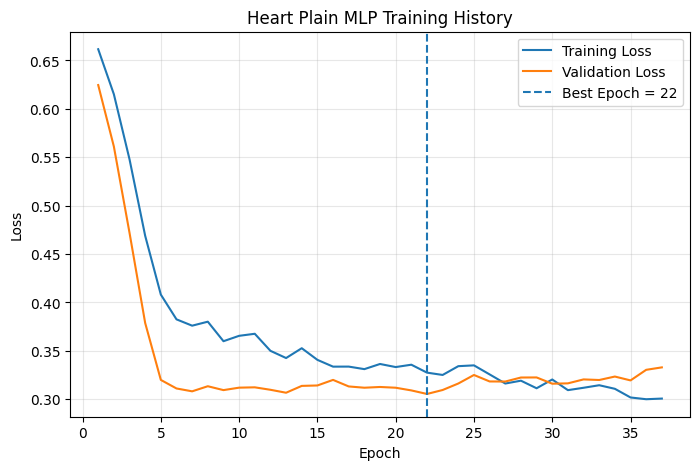

In [28]:
# ============================================================
# CELL 24: Plot Plain MLP training history
# ============================================================

import matplotlib.pyplot as plt


epochs = range(
    1,
    len(heart_plain_history["train_loss"]) + 1
)


plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    heart_plain_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    heart_plain_history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    x=heart_plain_best_epoch,
    linestyle="--",
    label=f"Best Epoch = {heart_plain_best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Heart Plain MLP Training History")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [29]:
# ============================================================
# CELL 25: Evaluate Plain MLP on the heart validation set
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss
)


def collect_predictions(
    model,
    data_loader,
    device
):
    """
    Collect correct labels and predicted probabilities
    without changing the model.
    """

    model.eval()

    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for numerical_data, categorical_data, labels in data_loader:

            numerical_data = numerical_data.to(device)
            categorical_data = categorical_data.to(device)

            logits = model(
                numerical_data,
                categorical_data
            )

            probabilities = torch.sigmoid(logits)

            all_labels.append(
                labels.cpu()
            )

            all_probabilities.append(
                probabilities.cpu()
            )

    all_labels = torch.cat(
        all_labels
    ).numpy().astype(int)

    all_probabilities = torch.cat(
        all_probabilities
    ).numpy()

    return all_labels, all_probabilities


# ------------------------------------------------------------
# Collect validation predictions
# ------------------------------------------------------------

heart_plain_val_labels, heart_plain_val_probabilities = (
    collect_predictions(
        model=heart_plain_mlp,
        data_loader=heart_val_loader,
        device=DEVICE
    )
)


# Probability >= 0.50 means disease prediction
heart_plain_val_predictions = (
    heart_plain_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

heart_plain_val_results = {
    "Accuracy": accuracy_score(
        heart_plain_val_labels,
        heart_plain_val_predictions
    ),

    "Precision": precision_score(
        heart_plain_val_labels,
        heart_plain_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        heart_plain_val_labels,
        heart_plain_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        heart_plain_val_labels,
        heart_plain_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        heart_plain_val_labels,
        heart_plain_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        heart_plain_val_labels,
        heart_plain_val_probabilities
    )
}


heart_plain_val_table = pd.DataFrame(
    heart_plain_val_results.items(),
    columns=["Metric", "Value"]
)

heart_plain_val_table["Value"] = (
    heart_plain_val_table["Value"].round(4)
)


print("=" * 60)
print("HEART PLAIN MLP — VALIDATION RESULTS")
print("=" * 60)

display(heart_plain_val_table)

HEART PLAIN MLP — VALIDATION RESULTS


,Metric,Value
0,Accuracy,0.8841
1,Precision,0.8506
2,Recall,0.9610
3,F1 Score,0.9024
4,AUROC,0.9374
5,Brier Score,0.0891


HEART PLAIN MLP — VALIDATION CONFUSION MATRIX
True Negative : 48
False Positive: 13
False Negative: 3
True Positive : 74


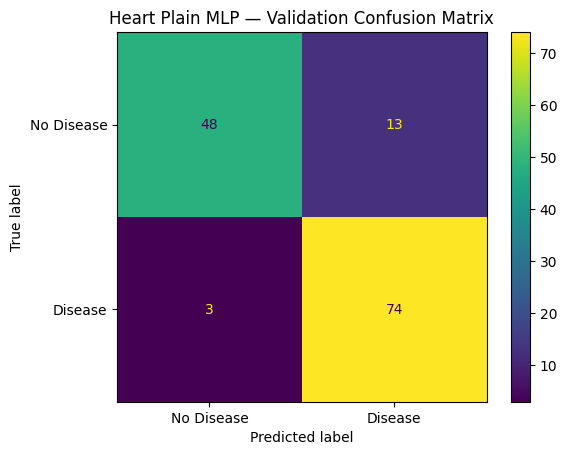

In [30]:
# ============================================================
# CELL 26: Plain MLP validation confusion matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Calculate confusion matrix
heart_plain_confusion_matrix = confusion_matrix(
    heart_plain_val_labels,
    heart_plain_val_predictions
)


# Separate the four values
true_negative, false_positive, false_negative, true_positive = (
    heart_plain_confusion_matrix.ravel()
)


print("=" * 60)
print("HEART PLAIN MLP — VALIDATION CONFUSION MATRIX")
print("=" * 60)

print("True Negative :", true_negative)
print("False Positive:", false_positive)
print("False Negative:", false_negative)
print("True Positive :", true_positive)


# Display the confusion matrix as a plot
display_object = ConfusionMatrixDisplay(
    confusion_matrix=heart_plain_confusion_matrix,
    display_labels=["No Disease", "Disease"]
)

display_object.plot()

plt.title(
    "Heart Plain MLP — Validation Confusion Matrix"
)

plt.show()

# Model 2: Random-Perspective Neural Network

In [31]:
# ============================================================
# CELL 27: Create random feature perspectives
# ============================================================

# Feature order must match the FeatureEncoder output order
HEART_FEATURE_NAMES = (
    HEART_NUMERICAL
    + HEART_CATEGORICAL
)


def create_random_perspectives(
    feature_names,
    number_of_perspectives=4,
    seed=42
):
    """
    Randomly divide features into approximately equal groups.
    """

    random_generator = np.random.default_rng(seed)

    # Feature positions: 0, 1, 2, ..., 10
    feature_indices = np.arange(
        len(feature_names)
    )

    # Randomly rearrange feature positions
    shuffled_indices = random_generator.permutation(
        feature_indices
    )

    # Divide the shuffled positions into balanced groups
    split_groups = np.array_split(
        shuffled_indices,
        number_of_perspectives
    )

    random_perspectives = []

    for group in split_groups:

        group_indices = group.tolist()

        group_names = [
            feature_names[index]
            for index in group_indices
        ]

        random_perspectives.append({
            "indices": group_indices,
            "names": group_names
        })

    return random_perspectives


# Create four fixed random perspectives
heart_random_perspectives = create_random_perspectives(
    feature_names=HEART_FEATURE_NAMES,
    number_of_perspectives=4,
    seed=SEED
)


print("=" * 60)
print("HEART RANDOM PERSPECTIVES")
print("=" * 60)

for perspective_number, perspective in enumerate(
    heart_random_perspectives,
    start=1
):
    print(
        f"Perspective {perspective_number}: "
        f"{perspective['names']}"
    )

    print(
        f"Feature indices: "
        f"{perspective['indices']}"
    )

    print()

HEART RANDOM PERSPECTIVES
Perspective 1: ['ChestPainType', 'FastingBS', 'Age']
Feature indices: [6, 7, 0]

Perspective 2: ['ST_Slope', 'MaxHR', 'Sex']
Feature indices: [10, 3, 5]

Perspective 3: ['Cholesterol', 'Oldpeak', 'ExerciseAngina']
Feature indices: [2, 4, 9]

Perspective 4: ['RestingBP', 'RestingECG']
Feature indices: [1, 8]



In [32]:
# ============================================================
# CELL 28: Define Model 2 — Random-Perspective Neural Network
# ============================================================

class PerspectiveExpert(nn.Module):
    """
    A small neural network for one perspective.
    """

    def __init__(
        self,
        number_of_features,
        token_dimension=4
    ):
        super().__init__()

        # Each feature has 'token_dimension' numbers
        input_size = (
            number_of_features * token_dimension
        )

        self.network = nn.Sequential(

            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )


    def forward(self, perspective_tokens):

        # Example:
        # [32 patients, 3 features, 4 numbers]
        #
        # becomes:
        # [32 patients, 12 numbers]

        flattened_tokens = perspective_tokens.flatten(
            start_dim=1
        )

        expert_logit = self.network(
            flattened_tokens
        )

        return expert_logit.squeeze(1)

In [33]:
class RandomPerspectiveNN(nn.Module):
    """
    Model 2:

    Features are divided into fixed random groups.
    Each group has its own neural expert.
    Expert logits are averaged for the final prediction.
    """

    def __init__(
        self,
        number_of_numerical_features,
        categorical_sizes,
        perspectives,
        token_dimension=4
    ):
        super().__init__()

        self.perspectives = perspectives


        # ----------------------------------------------------
        # Common feature encoder
        # ----------------------------------------------------

        self.feature_encoder = FeatureEncoder(

            number_of_numerical_features=
                number_of_numerical_features,

            categorical_sizes=
                categorical_sizes,

            token_dimension=
                token_dimension
        )


        # ----------------------------------------------------
        # One expert for every perspective
        # ----------------------------------------------------

        self.experts = nn.ModuleList([

            PerspectiveExpert(

                number_of_features=
                    len(perspective["indices"]),

                token_dimension=
                    token_dimension
            )

            for perspective in perspectives
        ])


    def forward(
        self,
        numerical_data,
        categorical_data,
        return_expert_logits=False
    ):

        # Encode all 11 input features
        feature_tokens = self.feature_encoder(
            numerical_data,
            categorical_data
        )

        expert_logits = []


        # Send every feature group to its own expert
        for perspective, expert in zip(
            self.perspectives,
            self.experts
        ):

            feature_indices = perspective["indices"]

            perspective_tokens = feature_tokens[
                :,
                feature_indices,
                :
            ]

            one_expert_logit = expert(
                perspective_tokens
            )

            expert_logits.append(
                one_expert_logit
            )


        # Shape:
        # [batch size, number of experts]
        expert_logits = torch.stack(
            expert_logits,
            dim=1
        )


        # Equal averaging:
        # Every expert receives 25% importance
        final_logit = expert_logits.mean(
            dim=1
        )


        if return_expert_logits:

            return final_logit, expert_logits

        return final_logit

In [34]:
# ------------------------------------------------------------
# Check that the random grouping is valid
# ------------------------------------------------------------

all_random_indices = []

for perspective in heart_random_perspectives:

    all_random_indices.extend(
        perspective["indices"]
    )


print("=" * 60)
print("RANDOM PERSPECTIVE GROUP CHECK")
print("=" * 60)

print(
    "Every feature used exactly once:",
    sorted(all_random_indices)
    == list(range(len(HEART_FEATURE_NAMES)))
)


# ------------------------------------------------------------
# Create and test the model
# ------------------------------------------------------------

torch.manual_seed(SEED)

heart_random_model = RandomPerspectiveNN(

    number_of_numerical_features=
        len(HEART_NUMERICAL),

    categorical_sizes=
        heart_categorical_sizes_list,

    perspectives=
        heart_random_perspectives,

    token_dimension=
        TOKEN_DIMENSION

).to(DEVICE)


heart_random_model.eval()


with torch.no_grad():

    (
        random_final_logits,
        random_expert_logits
    ) = heart_random_model(

        batch_numerical,
        batch_categorical,

        return_expert_logits=True
    )

    random_final_probabilities = torch.sigmoid(
        random_final_logits
    )


print("\n" + "=" * 60)
print("RANDOM-PERSPECTIVE MODEL TEST")
print("=" * 60)

print(
    "Expert logits shape:",
    random_expert_logits.shape
)

print(
    "Final logits shape:",
    random_final_logits.shape
)

print("\nFirst patient's four expert logits:")
print(
    random_expert_logits[0]
)

print("\nFirst patient's final logit:")
print(
    random_final_logits[0]
)

print("\nFirst patient's disease probability:")
print(
    random_final_probabilities[0]
)

print(
    "\nTotal trainable parameters:",
    sum(
        parameter.numel()
        for parameter in heart_random_model.parameters()
        if parameter.requires_grad
    )
)

RANDOM PERSPECTIVE GROUP CHECK
Every feature used exactly once: True

RANDOM-PERSPECTIVE MODEL TEST
Expert logits shape: torch.Size([32, 4])
Final logits shape: torch.Size([32])

First patient's four expert logits:
tensor([-0.0069,  0.3526,  0.1242,  0.1442])

First patient's final logit:
tensor(0.1535)

First patient's disease probability:
tensor(0.5383)

Total trainable parameters: 1476


In [35]:
# ============================================================
# CELL 29: Parameter-match the perspective experts
# ============================================================

class PerspectiveExpert(nn.Module):
    """
    A parameter-matched neural expert for one perspective.
    """

    def __init__(
        self,
        number_of_features,
        token_dimension=4
    ):
        super().__init__()

        input_size = (
            number_of_features * token_dimension
        )

        self.network = nn.Sequential(

            nn.Linear(input_size, 24),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(24, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )


    def forward(self, perspective_tokens):

        flattened_tokens = perspective_tokens.flatten(
            start_dim=1
        )

        expert_logit = self.network(
            flattened_tokens
        )

        return expert_logit.squeeze(1)


# ------------------------------------------------------------
# Recreate the random-perspective model
# ------------------------------------------------------------

torch.manual_seed(SEED)

heart_random_model = RandomPerspectiveNN(

    number_of_numerical_features=
        len(HEART_NUMERICAL),

    categorical_sizes=
        heart_categorical_sizes_list,

    perspectives=
        heart_random_perspectives,

    token_dimension=
        TOKEN_DIMENSION

).to(DEVICE)


# ------------------------------------------------------------
# Compare parameter counts
# ------------------------------------------------------------

plain_parameter_count = sum(
    parameter.numel()
    for parameter in heart_plain_mlp.parameters()
    if parameter.requires_grad
)

random_parameter_count = sum(
    parameter.numel()
    for parameter in heart_random_model.parameters()
    if parameter.requires_grad
)


print("=" * 60)
print("PARAMETER-MATCHING CHECK")
print("=" * 60)

print(
    "Plain MLP parameters:",
    plain_parameter_count
)

print(
    "Random-Perspective parameters:",
    random_parameter_count
)

print(
    "Parameter difference:",
    abs(
        plain_parameter_count
        - random_parameter_count
    )
)


# ------------------------------------------------------------
# Test the recreated model
# ------------------------------------------------------------

heart_random_model.eval()

with torch.no_grad():

    (
        random_final_logits,
        random_expert_logits
    ) = heart_random_model(

        batch_numerical,
        batch_categorical,

        return_expert_logits=True
    )


print("\nExpert logits shape:",
      random_expert_logits.shape)

print("Final logits shape:",
      random_final_logits.shape)

PARAMETER-MATCHING CHECK
Plain MLP parameters: 2113
Random-Perspective parameters: 2116
Parameter difference: 3

Expert logits shape: torch.Size([32, 4])
Final logits shape: torch.Size([32])


In [36]:
# ============================================================
# CELL 30: Train Model 2 — Random-Perspective Neural Network
# ============================================================

# ------------------------------------------------------------
# Reset all random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create a fresh shuffled training DataLoader
# ------------------------------------------------------------

random_model_generator = torch.Generator()
random_model_generator.manual_seed(SEED)

heart_random_train_loader = DataLoader(
    heart_train_dataset,
    batch_size=HEART_BATCH_SIZE,
    shuffle=True,
    generator=random_model_generator
)


# ------------------------------------------------------------
# Create a completely fresh Random-Perspective model
# ------------------------------------------------------------

heart_random_model = RandomPerspectiveNN(
    number_of_numerical_features=len(HEART_NUMERICAL),
    categorical_sizes=heart_categorical_sizes_list,
    perspectives=heart_random_perspectives,
    token_dimension=TOKEN_DIMENSION
).to(DEVICE)


# ------------------------------------------------------------
# Create optimizer
# ------------------------------------------------------------

heart_random_optimizer = torch.optim.AdamW(
    heart_random_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train with early stopping
# ------------------------------------------------------------

(
    heart_random_model,
    heart_random_history,
    heart_random_best_epoch,
    heart_random_best_val_loss
) = train_model(
    model=heart_random_model,
    train_loader=heart_random_train_loader,
    val_loader=heart_val_loader,
    optimizer=heart_random_optimizer,
    loss_function=loss_function,
    device=DEVICE,
    maximum_epochs=100,
    patience=15
)

Epoch   1 | Train Loss: 0.6751 | Validation Loss: 0.6604
Epoch  10 | Train Loss: 0.4167 | Validation Loss: 0.3387
Epoch  20 | Train Loss: 0.3608 | Validation Loss: 0.3125
Epoch  30 | Train Loss: 0.3473 | Validation Loss: 0.3073
Epoch  37 | Train Loss: 0.3424 | Validation Loss: 0.3112

Early stopping activated.

Training completed.
Best epoch: 22
Best validation loss: 0.3057


In [37]:
# ============================================================
# CELL 31: Evaluate Random-Perspective NN on validation data
#          and compare it with Plain MLP
# ============================================================

# ------------------------------------------------------------
# Collect Random-Perspective validation predictions
# ------------------------------------------------------------

(
    heart_random_val_labels,
    heart_random_val_probabilities
) = collect_predictions(
    model=heart_random_model,
    data_loader=heart_val_loader,
    device=DEVICE
)


# Probability >= 0.50 means disease
heart_random_val_predictions = (
    heart_random_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate Random-Perspective validation metrics
# ------------------------------------------------------------

heart_random_val_results = {
    "Accuracy": accuracy_score(
        heart_random_val_labels,
        heart_random_val_predictions
    ),

    "Precision": precision_score(
        heart_random_val_labels,
        heart_random_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        heart_random_val_labels,
        heart_random_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        heart_random_val_labels,
        heart_random_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        heart_random_val_labels,
        heart_random_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        heart_random_val_labels,
        heart_random_val_probabilities
    )
}


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

heart_model_comparison = pd.DataFrame({
    "Metric": list(heart_plain_val_results.keys()),

    "Plain MLP": [
        heart_plain_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Random-Perspective NN": [
        heart_random_val_results[metric]
        for metric in heart_plain_val_results
    ]
})


# Difference:
# Positive means Random-Perspective has a larger value
heart_model_comparison["Difference"] = (
    heart_model_comparison["Random-Perspective NN"]
    - heart_model_comparison["Plain MLP"]
)


heart_model_comparison[
    ["Plain MLP", "Random-Perspective NN", "Difference"]
] = heart_model_comparison[
    ["Plain MLP", "Random-Perspective NN", "Difference"]
].round(4)


print("=" * 70)
print("HEART VALIDATION COMPARISON")
print("=" * 70)

display(heart_model_comparison)

HEART VALIDATION COMPARISON


,Metric,Plain MLP,Random-Perspective NN,Difference
0,Accuracy,0.8841,0.8841,0.0000
1,Precision,0.8506,0.8675,0.0169
2,Recall,0.9610,0.9351,-0.0260
3,F1 Score,0.9024,0.9000,-0.0024
4,AUROC,0.9374,0.9457,0.0083
5,Brier Score,0.0891,0.0885,-0.0005


# Model 3 - Fixed Perspectives

In [38]:
# ============================================================
# CELL 32: Create fixed meaningful perspectives
# ============================================================

heart_fixed_perspectives = [

    {
        "name": "Demographic Perspective",
        "indices": [0, 5],
        "names": [
            "Age",
            "Sex"
        ]
    },

    {
        "name": "Metabolic and Blood Pressure Perspective",
        "indices": [1, 2, 7],
        "names": [
            "RestingBP",
            "Cholesterol",
            "FastingBS"
        ]
    },

    {
        "name": "Exercise Response Perspective",
        "indices": [3, 4, 9],
        "names": [
            "MaxHR",
            "Oldpeak",
            "ExerciseAngina"
        ]
    },

    {
        "name": "Symptoms and ECG Perspective",
        "indices": [6, 8, 10],
        "names": [
            "ChestPainType",
            "RestingECG",
            "ST_Slope"
        ]
    }
]


# ------------------------------------------------------------
# Check that every feature is included exactly once
# ------------------------------------------------------------

all_fixed_indices = []

for perspective in heart_fixed_perspectives:

    all_fixed_indices.extend(
        perspective["indices"]
    )


print("=" * 60)
print("HEART FIXED PERSPECTIVES")
print("=" * 60)

for perspective_number, perspective in enumerate(
    heart_fixed_perspectives,
    start=1
):

    print(
        f"Perspective {perspective_number}: "
        f"{perspective['name']}"
    )

    print(
        "Features:",
        perspective["names"]
    )

    print(
        "Feature indices:",
        perspective["indices"]
    )

    print()


print(
    "Every feature used exactly once:",
    sorted(all_fixed_indices)
    == list(range(len(HEART_FEATURE_NAMES)))
)

HEART FIXED PERSPECTIVES
Perspective 1: Demographic Perspective
Features: ['Age', 'Sex']
Feature indices: [0, 5]

Perspective 2: Metabolic and Blood Pressure Perspective
Features: ['RestingBP', 'Cholesterol', 'FastingBS']
Feature indices: [1, 2, 7]

Perspective 3: Exercise Response Perspective
Features: ['MaxHR', 'Oldpeak', 'ExerciseAngina']
Feature indices: [3, 4, 9]

Perspective 4: Symptoms and ECG Perspective
Features: ['ChestPainType', 'RestingECG', 'ST_Slope']
Feature indices: [6, 8, 10]

Every feature used exactly once: True


In [39]:
# ============================================================
# CELL 33: Create and test Model 3 — Fixed-Perspective NN
# ============================================================

# Reset seed before creating the model
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create the Fixed-Perspective model
# ------------------------------------------------------------

heart_fixed_model = RandomPerspectiveNN(

    number_of_numerical_features=
        len(HEART_NUMERICAL),

    categorical_sizes=
        heart_categorical_sizes_list,

    perspectives=
        heart_fixed_perspectives,

    token_dimension=
        TOKEN_DIMENSION

).to(DEVICE)


# ------------------------------------------------------------
# Test the model using one batch
# ------------------------------------------------------------

heart_fixed_model.eval()

with torch.no_grad():

    (
        fixed_final_logits,
        fixed_expert_logits
    ) = heart_fixed_model(

        batch_numerical,
        batch_categorical,

        return_expert_logits=True
    )

    fixed_probabilities = torch.sigmoid(
        fixed_final_logits
    )


# ------------------------------------------------------------
# Count trainable parameters
# ------------------------------------------------------------

fixed_parameter_count = sum(

    parameter.numel()

    for parameter in heart_fixed_model.parameters()

    if parameter.requires_grad
)


print("=" * 60)
print("FIXED-PERSPECTIVE MODEL TEST")
print("=" * 60)

print(
    "Expert logits shape:",
    fixed_expert_logits.shape
)

print(
    "Final logits shape:",
    fixed_final_logits.shape
)

print("\nFirst patient's four expert logits:")
print(
    fixed_expert_logits[0]
)

print("\nFirst patient's final logit:")
print(
    fixed_final_logits[0]
)

print("\nFirst patient's disease probability:")
print(
    fixed_probabilities[0]
)

print(
    "\nFixed-Perspective parameters:",
    fixed_parameter_count
)

print(
    "Plain MLP parameters:",
    plain_parameter_count
)

print(
    "Parameter difference:",
    abs(
        fixed_parameter_count
        - plain_parameter_count
    )
)

FIXED-PERSPECTIVE MODEL TEST
Expert logits shape: torch.Size([32, 4])
Final logits shape: torch.Size([32])

First patient's four expert logits:
tensor([-0.1599, -0.3187,  0.3511, -0.0284])

First patient's final logit:
tensor(-0.0390)

First patient's disease probability:
tensor(0.4903)

Fixed-Perspective parameters: 2116
Plain MLP parameters: 2113
Parameter difference: 3


In [40]:
# ============================================================
# CELL 34: Train Model 3 — Fixed-Perspective Neural Network
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Fresh training DataLoader
# ------------------------------------------------------------

fixed_model_generator = torch.Generator()
fixed_model_generator.manual_seed(SEED)

heart_fixed_train_loader = DataLoader(
    heart_train_dataset,
    batch_size=HEART_BATCH_SIZE,
    shuffle=True,
    generator=fixed_model_generator
)


# ------------------------------------------------------------
# Create a completely fresh Fixed-Perspective model
# ------------------------------------------------------------

heart_fixed_model = RandomPerspectiveNN(
    number_of_numerical_features=len(HEART_NUMERICAL),
    categorical_sizes=heart_categorical_sizes_list,
    perspectives=heart_fixed_perspectives,
    token_dimension=TOKEN_DIMENSION
).to(DEVICE)


# ------------------------------------------------------------
# Create optimizer
# ------------------------------------------------------------

heart_fixed_optimizer = torch.optim.AdamW(
    heart_fixed_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train with early stopping
# ------------------------------------------------------------

(
    heart_fixed_model,
    heart_fixed_history,
    heart_fixed_best_epoch,
    heart_fixed_best_val_loss
) = train_model(
    model=heart_fixed_model,
    train_loader=heart_fixed_train_loader,
    val_loader=heart_val_loader,
    optimizer=heart_fixed_optimizer,
    loss_function=loss_function,
    device=DEVICE,
    maximum_epochs=100,
    patience=15
)

Epoch   1 | Train Loss: 0.6886 | Validation Loss: 0.6787
Epoch  10 | Train Loss: 0.3740 | Validation Loss: 0.3199
Epoch  20 | Train Loss: 0.3390 | Validation Loss: 0.3093
Epoch  30 | Train Loss: 0.3391 | Validation Loss: 0.3142
Epoch  37 | Train Loss: 0.3308 | Validation Loss: 0.3192

Early stopping activated.

Training completed.
Best epoch: 22
Best validation loss: 0.3077


In [41]:
# ============================================================
# CELL 35: Evaluate Fixed-Perspective NN and compare
#          the first three heart models
# ============================================================

# ------------------------------------------------------------
# Collect Fixed-Perspective validation predictions
# ------------------------------------------------------------

(
    heart_fixed_val_labels,
    heart_fixed_val_probabilities
) = collect_predictions(
    model=heart_fixed_model,
    data_loader=heart_val_loader,
    device=DEVICE
)


# Convert probabilities into class predictions
heart_fixed_val_predictions = (
    heart_fixed_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate Fixed-Perspective metrics
# ------------------------------------------------------------

heart_fixed_val_results = {

    "Accuracy": accuracy_score(
        heart_fixed_val_labels,
        heart_fixed_val_predictions
    ),

    "Precision": precision_score(
        heart_fixed_val_labels,
        heart_fixed_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        heart_fixed_val_labels,
        heart_fixed_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        heart_fixed_val_labels,
        heart_fixed_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        heart_fixed_val_labels,
        heart_fixed_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        heart_fixed_val_labels,
        heart_fixed_val_probabilities
    )
}


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

heart_three_model_comparison = pd.DataFrame({

    "Metric": list(
        heart_plain_val_results.keys()
    ),

    "Plain MLP": [
        heart_plain_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Random-Perspective NN": [
        heart_random_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Fixed-Perspective NN": [
        heart_fixed_val_results[metric]
        for metric in heart_plain_val_results
    ]
})


# Round the numbers for easier reading
numeric_columns = [
    "Plain MLP",
    "Random-Perspective NN",
    "Fixed-Perspective NN"
]

heart_three_model_comparison[numeric_columns] = (
    heart_three_model_comparison[numeric_columns]
    .round(4)
)


print("=" * 75)
print("HEART VALIDATION COMPARISON — FIRST THREE MODELS")
print("=" * 75)

display(heart_three_model_comparison)


# ------------------------------------------------------------
# Also show best validation losses
# ------------------------------------------------------------

validation_loss_comparison = pd.DataFrame({

    "Model": [
        "Plain MLP",
        "Random-Perspective NN",
        "Fixed-Perspective NN"
    ],

    "Best Epoch": [
        heart_plain_best_epoch,
        heart_random_best_epoch,
        heart_fixed_best_epoch
    ],

    "Best Validation Loss": [
        heart_plain_best_val_loss,
        heart_random_best_val_loss,
        heart_fixed_best_val_loss
    ]
})

validation_loss_comparison["Best Validation Loss"] = (
    validation_loss_comparison["Best Validation Loss"]
    .round(4)
)


print("\n" + "=" * 75)
print("BEST VALIDATION LOSS COMPARISON")
print("=" * 75)

display(validation_loss_comparison)

HEART VALIDATION COMPARISON — FIRST THREE MODELS


,Metric,Plain MLP,Random-Perspective NN,Fixed-Perspective NN
0,Accuracy,0.8841,0.8841,0.8551
1,Precision,0.8506,0.8675,0.8353
2,Recall,0.9610,0.9351,0.9221
3,F1 Score,0.9024,0.9000,0.8765
4,AUROC,0.9374,0.9457,0.9404
5,Brier Score,0.0891,0.0885,0.0895



BEST VALIDATION LOSS COMPARISON


,Model,Best Epoch,Best Validation Loss
0,Plain MLP,22,0.3055
1,Random-Perspective NN,22,0.3057
2,Fixed-Perspective NN,22,0.3077


# Model 4 — Automatic Perspective + Equal Averaging

In [42]:
# ============================================================
# CELL 36: Define Model 4 — Automatic Perspectives
#          with Equal Averaging
# ============================================================

import torch.nn.functional as F


class AutomaticPerspectiveExpert(nn.Module):
    """
    One neural expert for one automatically learned perspective.
    """

    def __init__(
        self,
        total_features,
        token_dimension=4
    ):
        super().__init__()

        input_size = (
            total_features * token_dimension
        )

        self.network = nn.Sequential(

            nn.Linear(input_size, 9),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(9, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )


    def forward(self, masked_feature_tokens):

        flattened_tokens = masked_feature_tokens.flatten(
            start_dim=1
        )

        expert_logit = self.network(
            flattened_tokens
        )

        return expert_logit.squeeze(1)

In [43]:
class AutomaticPerspectiveEqualNN(nn.Module):
    """
    Model 4:

    The model automatically learns which features belong
    to which perspectives.

    All expert logits are equally averaged.
    """

    def __init__(
        self,
        number_of_numerical_features,
        categorical_sizes,
        number_of_perspectives=4,
        token_dimension=4,
        temperature=1.0
    ):
        super().__init__()

        self.total_features = (
            number_of_numerical_features
            + len(categorical_sizes)
        )

        self.number_of_perspectives = (
            number_of_perspectives
        )

        self.temperature = temperature


        # ----------------------------------------------------
        # Shared feature encoder
        # ----------------------------------------------------

        self.feature_encoder = FeatureEncoder(

            number_of_numerical_features=
                number_of_numerical_features,

            categorical_sizes=
                categorical_sizes,

            token_dimension=
                token_dimension
        )


        # ----------------------------------------------------
        # Learnable feature-to-perspective scores
        # ----------------------------------------------------

        self.assignment_logits = nn.Parameter(

            0.01 * torch.randn(
                self.total_features,
                number_of_perspectives
            )
        )


        # ----------------------------------------------------
        # One neural expert for each perspective
        # ----------------------------------------------------

        self.experts = nn.ModuleList([

            AutomaticPerspectiveExpert(

                total_features=
                    self.total_features,

                token_dimension=
                    token_dimension
            )

            for _ in range(number_of_perspectives)
        ])


    def get_assignment_weights(self):
        """
        Convert raw assignment scores into weights.

        Each feature's weights across all perspectives
        add up to 1.
        """

        assignment_weights = F.softmax(

            self.assignment_logits
            / self.temperature,

            dim=1
        )

        return assignment_weights


    def forward(
        self,
        numerical_data,
        categorical_data,
        return_details=False
    ):

        # Shape:
        # [batch, 11 features, 4 token values]
        feature_tokens = self.feature_encoder(
            numerical_data,
            categorical_data
        )


        # Shape:
        # [11 features, 4 perspectives]
        assignment_weights = (
            self.get_assignment_weights()
        )


        expert_logits = []


        for perspective_index, expert in enumerate(
            self.experts
        ):

            # Get the weight of every feature
            # for the current perspective
            perspective_weights = assignment_weights[
                :,
                perspective_index
            ]


            # Shape:
            # [1, 11 features, 1]
            perspective_weights = (
                perspective_weights.view(
                    1,
                    self.total_features,
                    1
                )
            )


            # Give strongly assigned features more signal
            # and weakly assigned features less signal
            masked_tokens = (
                feature_tokens
                * perspective_weights
            )


            one_expert_logit = expert(
                masked_tokens
            )

            expert_logits.append(
                one_expert_logit
            )


        # Shape:
        # [batch, 4 experts]
        expert_logits = torch.stack(
            expert_logits,
            dim=1
        )


        # Equal averaging
        final_logit = expert_logits.mean(
            dim=1
        )


        if return_details:

            return (
                final_logit,
                expert_logits,
                assignment_weights
            )

        return final_logit

In [44]:
# ------------------------------------------------------------
# Create and test the automatic-perspective model
# ------------------------------------------------------------

torch.manual_seed(SEED)

heart_auto_equal_model = AutomaticPerspectiveEqualNN(

    number_of_numerical_features=
        len(HEART_NUMERICAL),

    categorical_sizes=
        heart_categorical_sizes_list,

    number_of_perspectives=4,

    token_dimension=
        TOKEN_DIMENSION,

    temperature=1.0

).to(DEVICE)


heart_auto_equal_model.eval()


with torch.no_grad():

    (
        auto_final_logits,
        auto_expert_logits,
        auto_assignment_weights
    ) = heart_auto_equal_model(

        batch_numerical,
        batch_categorical,

        return_details=True
    )


auto_parameter_count = sum(

    parameter.numel()

    for parameter
    in heart_auto_equal_model.parameters()

    if parameter.requires_grad
)


print("=" * 70)
print("AUTOMATIC-PERSPECTIVE MODEL TEST")
print("=" * 70)

print(
    "Assignment matrix shape:",
    auto_assignment_weights.shape
)

print(
    "Expert logits shape:",
    auto_expert_logits.shape
)

print(
    "Final logits shape:",
    auto_final_logits.shape
)

print("\nFirst feature assignment weights:")
print(
    auto_assignment_weights[0]
)

print(
    "\nFirst feature weight sum:",
    auto_assignment_weights[0].sum()
)

print(
    "\nAutomatic model parameters:",
    auto_parameter_count
)

print(
    "Plain MLP parameters:",
    plain_parameter_count
)

print(
    "Parameter difference:",
    abs(
        auto_parameter_count
        - plain_parameter_count
    )
)

AUTOMATIC-PERSPECTIVE MODEL TEST
Assignment matrix shape: torch.Size([11, 4])
Expert logits shape: torch.Size([32, 4])
Final logits shape: torch.Size([32])

First feature assignment weights:
tensor([0.2503, 0.2486, 0.2498, 0.2513])

First feature weight sum: tensor(1.)

Automatic model parameters: 2148
Plain MLP parameters: 2113
Parameter difference: 35


In [45]:
# ============================================================
# CELL 37: Define loss for automatic perspective discovery
# ============================================================

def calculate_automatic_perspective_loss(
    model,
    final_logits,
    labels,
    prediction_loss_function,
    entropy_weight=0.02,
    balance_weight=0.10
):
    """
    Total loss contains:

    1. Prediction loss:
       Makes the final disease prediction accurate.

    2. Assignment entropy:
       Encourages each feature to prefer a smaller number
       of perspectives.

    3. Balance loss:
       Prevents all features from collapsing into
       the same perspective.
    """

    # --------------------------------------------------------
    # 1. Prediction loss
    # --------------------------------------------------------

    prediction_loss = prediction_loss_function(
        final_logits,
        labels
    )


    # Shape:
    # [number of features, number of perspectives]
    assignment_weights = (
        model.get_assignment_weights()
    )


    # --------------------------------------------------------
    # 2. Assignment entropy
    # --------------------------------------------------------

    small_value = 1e-8

    entropy_per_feature = -(
        assignment_weights
        * torch.log(
            assignment_weights + small_value
        )
    ).sum(dim=1)


    # Normalize entropy approximately between 0 and 1
    maximum_entropy = np.log(
        model.number_of_perspectives
    )

    normalized_entropy = (
        entropy_per_feature.mean()
        / maximum_entropy
    )


    # --------------------------------------------------------
    # 3. Perspective balance loss
    # --------------------------------------------------------

    average_perspective_usage = (
        assignment_weights.mean(dim=0)
    )

    target_perspective_usage = torch.full_like(
        average_perspective_usage,
        fill_value=(
            1.0 / model.number_of_perspectives
        )
    )

    balance_loss = torch.mean(
        (
            average_perspective_usage
            - target_perspective_usage
        ) ** 2
    )


    # --------------------------------------------------------
    # Final combined loss
    # --------------------------------------------------------

    total_loss = (
        prediction_loss
        + entropy_weight * normalized_entropy
        + balance_weight * balance_loss
    )


    return {
        "total_loss": total_loss,
        "prediction_loss": prediction_loss,
        "normalized_entropy": normalized_entropy,
        "balance_loss": balance_loss,
        "average_perspective_usage":
            average_perspective_usage
    }

In [46]:
# ------------------------------------------------------------
# Test the automatic-perspective loss
# ------------------------------------------------------------

(
    auto_batch_numerical,
    auto_batch_categorical,
    auto_batch_labels
) = next(iter(heart_train_loader))


auto_batch_numerical = (
    auto_batch_numerical.to(DEVICE)
)

auto_batch_categorical = (
    auto_batch_categorical.to(DEVICE)
)

auto_batch_labels = (
    auto_batch_labels.to(DEVICE)
)


heart_auto_equal_model.eval()

with torch.no_grad():

    initial_auto_logits = heart_auto_equal_model(
        auto_batch_numerical,
        auto_batch_categorical
    )

    initial_auto_loss_details = (
        calculate_automatic_perspective_loss(
            model=heart_auto_equal_model,
            final_logits=initial_auto_logits,
            labels=auto_batch_labels,
            prediction_loss_function=loss_function,
            entropy_weight=0.02,
            balance_weight=0.10
        )
    )


print("=" * 70)
print("INITIAL AUTOMATIC-PERSPECTIVE LOSS CHECK")
print("=" * 70)

print(
    "Prediction loss:",
    round(
        initial_auto_loss_details[
            "prediction_loss"
        ].item(),
        4
    )
)

print(
    "Normalized assignment entropy:",
    round(
        initial_auto_loss_details[
            "normalized_entropy"
        ].item(),
        4
    )
)

print(
    "Balance loss:",
    round(
        initial_auto_loss_details[
            "balance_loss"
        ].item(),
        6
    )
)

print(
    "Total training loss:",
    round(
        initial_auto_loss_details[
            "total_loss"
        ].item(),
        4
    )
)

print("\nAverage perspective usage:")

print(
    initial_auto_loss_details[
        "average_perspective_usage"
    ]
)

INITIAL AUTOMATIC-PERSPECTIVE LOSS CHECK
Prediction loss: 0.7031
Normalized assignment entropy: 1.0
Balance loss: 0.0
Total training loss: 0.7231

Average perspective usage:
tensor([0.2494, 0.2501, 0.2500, 0.2504])


In [47]:
# ============================================================
# CELL 38: Training helpers for automatic perspectives
# ============================================================

def train_one_epoch_automatic(
    model,
    data_loader,
    optimizer,
    prediction_loss_function,
    device,
    entropy_weight=0.02,
    balance_weight=0.10
):
    """
    Train the automatic-perspective model for one epoch.
    """

    model.train()

    total_samples = 0

    accumulated_total_loss = 0.0
    accumulated_prediction_loss = 0.0
    accumulated_entropy = 0.0
    accumulated_balance_loss = 0.0


    for numerical_data, categorical_data, labels in data_loader:

        numerical_data = numerical_data.to(device)
        categorical_data = categorical_data.to(device)
        labels = labels.to(device)


        # Remove gradients from the previous batch
        optimizer.zero_grad()


        # Final prediction
        final_logits = model(
            numerical_data,
            categorical_data
        )


        # Prediction + perspective discovery losses
        loss_details = calculate_automatic_perspective_loss(
            model=model,
            final_logits=final_logits,
            labels=labels,
            prediction_loss_function=prediction_loss_function,
            entropy_weight=entropy_weight,
            balance_weight=balance_weight
        )


        # Backpropagation
        loss_details["total_loss"].backward()

        optimizer.step()


        batch_size = labels.size(0)
        total_samples += batch_size


        accumulated_total_loss += (
            loss_details["total_loss"].item()
            * batch_size
        )

        accumulated_prediction_loss += (
            loss_details["prediction_loss"].item()
            * batch_size
        )

        accumulated_entropy += (
            loss_details["normalized_entropy"].item()
            * batch_size
        )

        accumulated_balance_loss += (
            loss_details["balance_loss"].item()
            * batch_size
        )


    return {
        "total_loss":
            accumulated_total_loss / total_samples,

        "prediction_loss":
            accumulated_prediction_loss / total_samples,

        "normalized_entropy":
            accumulated_entropy / total_samples,

        "balance_loss":
            accumulated_balance_loss / total_samples
    }

In [48]:
def evaluate_automatic_model(
    model,
    data_loader,
    prediction_loss_function,
    device
):
    """
    Evaluate prediction loss and inspect learned assignments.
    """

    model.eval()

    total_prediction_loss = 0.0
    total_samples = 0


    with torch.no_grad():

        for numerical_data, categorical_data, labels in data_loader:

            numerical_data = numerical_data.to(device)
            categorical_data = categorical_data.to(device)
            labels = labels.to(device)


            final_logits = model(
                numerical_data,
                categorical_data
            )


            prediction_loss = prediction_loss_function(
                final_logits,
                labels
            )


            batch_size = labels.size(0)
            total_samples += batch_size

            total_prediction_loss += (
                prediction_loss.item()
                * batch_size
            )


        # Current learned feature assignments
        assignment_weights = (
            model.get_assignment_weights()
        )


        entropy_per_feature = -(
            assignment_weights
            * torch.log(
                assignment_weights + 1e-8
            )
        ).sum(dim=1)


        normalized_entropy = (
            entropy_per_feature.mean()
            / np.log(model.number_of_perspectives)
        )


        average_perspective_usage = (
            assignment_weights.mean(dim=0)
        )


        target_usage = torch.full_like(
            average_perspective_usage,
            1.0 / model.number_of_perspectives
        )


        balance_loss = torch.mean(
            (
                average_perspective_usage
                - target_usage
            ) ** 2
        )


        # Average value of each feature's largest assignment
        average_maximum_assignment = (
            assignment_weights
            .max(dim=1)
            .values
            .mean()
        )


    return {
        "prediction_loss":
            total_prediction_loss / total_samples,

        "normalized_entropy":
            normalized_entropy.item(),

        "balance_loss":
            balance_loss.item(),

        "average_maximum_assignment":
            average_maximum_assignment.item(),

        "average_perspective_usage":
            average_perspective_usage.detach().cpu()
    }

In [49]:
# ------------------------------------------------------------
# Check whether assignment weights receive gradients
# ------------------------------------------------------------

gradient_check_model = copy.deepcopy(
    heart_auto_equal_model
).to(DEVICE)

gradient_check_model.train()
gradient_check_model.zero_grad()


gradient_check_logits = gradient_check_model(
    auto_batch_numerical,
    auto_batch_categorical
)


gradient_check_losses = (
    calculate_automatic_perspective_loss(
        model=gradient_check_model,
        final_logits=gradient_check_logits,
        labels=auto_batch_labels,
        prediction_loss_function=loss_function,
        entropy_weight=0.02,
        balance_weight=0.10
    )
)


gradient_check_losses[
    "total_loss"
].backward()


assignment_gradient = (
    gradient_check_model
    .assignment_logits
    .grad
)


print("=" * 70)
print("AUTOMATIC ASSIGNMENT GRADIENT CHECK")
print("=" * 70)

print(
    "Assignment gradient exists:",
    assignment_gradient is not None
)

print(
    "Assignment gradient norm:",
    assignment_gradient.norm().item()
)

print(
    "Gradient contains finite values:",
    torch.isfinite(
        assignment_gradient
    ).all().item()
)


del gradient_check_model

AUTOMATIC ASSIGNMENT GRADIENT CHECK
Assignment gradient exists: True
Assignment gradient norm: 0.0010018434841185808
Gradient contains finite values: True


In [50]:
# ============================================================
# CELL 39: Train Model 4 — Automatic Perspectives
#          with Equal Averaging
# ============================================================

def train_automatic_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    prediction_loss_function,
    device,
    maximum_epochs=100,
    patience=15,
    entropy_weight=0.02,
    balance_weight=0.10
):
    """
    Train an automatic-perspective model and preserve
    the model state with the best validation prediction loss.
    """

    history = {
        "train_total_loss": [],
        "train_prediction_loss": [],
        "validation_prediction_loss": [],
        "assignment_entropy": [],
        "balance_loss": [],
        "average_maximum_assignment": []
    }

    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None

    epochs_without_improvement = 0


    for epoch in range(1, maximum_epochs + 1):

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        train_results = train_one_epoch_automatic(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            prediction_loss_function=prediction_loss_function,
            device=device,
            entropy_weight=entropy_weight,
            balance_weight=balance_weight
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        validation_results = evaluate_automatic_model(
            model=model,
            data_loader=val_loader,
            prediction_loss_function=prediction_loss_function,
            device=device
        )


        validation_loss = validation_results[
            "prediction_loss"
        ]


        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_total_loss"].append(
            train_results["total_loss"]
        )

        history["train_prediction_loss"].append(
            train_results["prediction_loss"]
        )

        history["validation_prediction_loss"].append(
            validation_loss
        )

        history["assignment_entropy"].append(
            validation_results["normalized_entropy"]
        )

        history["balance_loss"].append(
            validation_results["balance_loss"]
        )

        history["average_maximum_assignment"].append(
            validation_results[
                "average_maximum_assignment"
            ]
        )


        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if validation_loss < best_validation_loss:

            best_validation_loss = validation_loss
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1


        # ----------------------------------------------------
        # Print progress
        # ----------------------------------------------------

        should_print = (
            epoch == 1
            or epoch % 10 == 0
            or epochs_without_improvement >= patience
            or epoch == maximum_epochs
        )

        if should_print:

            print(
                f"Epoch {epoch:3d} | "
                f"Train Prediction Loss: "
                f"{train_results['prediction_loss']:.4f} | "
                f"Validation Loss: {validation_loss:.4f} | "
                f"Entropy: "
                f"{validation_results['normalized_entropy']:.4f} | "
                f"Max Assignment: "
                f"{validation_results['average_maximum_assignment']:.4f}"
            )


        if epochs_without_improvement >= patience:

            print("\nEarly stopping activated.")
            break


    # Restore the best validation model
    model.load_state_dict(
        best_model_state
    )


    # Inspect the restored assignments
    final_assignment_results = evaluate_automatic_model(
        model=model,
        data_loader=val_loader,
        prediction_loss_function=prediction_loss_function,
        device=device
    )


    print("\nTraining completed.")

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Best validation loss:",
        round(best_validation_loss, 4)
    )

    print(
        "Restored assignment entropy:",
        round(
            final_assignment_results[
                "normalized_entropy"
            ],
            4
        )
    )

    print(
        "Restored average maximum assignment:",
        round(
            final_assignment_results[
                "average_maximum_assignment"
            ],
            4
        )
    )

    print(
        "Restored average perspective usage:",
        final_assignment_results[
            "average_perspective_usage"
        ]
    )


    return (
        model,
        history,
        best_epoch,
        best_validation_loss
    )

In [51]:
# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Fresh shuffled DataLoader
# ------------------------------------------------------------

auto_model_generator = torch.Generator()
auto_model_generator.manual_seed(SEED)

heart_auto_train_loader = DataLoader(
    heart_train_dataset,
    batch_size=HEART_BATCH_SIZE,
    shuffle=True,
    generator=auto_model_generator
)


# ------------------------------------------------------------
# Create a completely fresh Model 4
# ------------------------------------------------------------

heart_auto_equal_model = AutomaticPerspectiveEqualNN(

    number_of_numerical_features=
        len(HEART_NUMERICAL),

    categorical_sizes=
        heart_categorical_sizes_list,

    number_of_perspectives=4,

    token_dimension=
        TOKEN_DIMENSION,

    temperature=1.0

).to(DEVICE)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

heart_auto_equal_optimizer = torch.optim.AdamW(
    heart_auto_equal_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train Model 4
# ------------------------------------------------------------

(
    heart_auto_equal_model,
    heart_auto_equal_history,
    heart_auto_equal_best_epoch,
    heart_auto_equal_best_val_loss
) = train_automatic_model(

    model=heart_auto_equal_model,

    train_loader=
        heart_auto_train_loader,

    val_loader=
        heart_val_loader,

    optimizer=
        heart_auto_equal_optimizer,

    prediction_loss_function=
        loss_function,

    device=
        DEVICE,

    maximum_epochs=100,

    patience=15,

    entropy_weight=0.02,

    balance_weight=0.10
)

Epoch   1 | Train Prediction Loss: 0.6855 | Validation Loss: 0.6804 | Entropy: 1.0000 | Max Assignment: 0.2535
Epoch  10 | Train Prediction Loss: 0.4176 | Validation Loss: 0.3517 | Entropy: 0.9965 | Max Assignment: 0.2807
Epoch  20 | Train Prediction Loss: 0.3428 | Validation Loss: 0.3031 | Entropy: 0.9940 | Max Assignment: 0.2940
Epoch  30 | Train Prediction Loss: 0.3432 | Validation Loss: 0.3060 | Entropy: 0.9924 | Max Assignment: 0.3003
Epoch  37 | Train Prediction Loss: 0.3415 | Validation Loss: 0.3093 | Entropy: 0.9913 | Max Assignment: 0.3039

Early stopping activated.

Training completed.
Best epoch: 22
Best validation loss: 0.2985
Restored assignment entropy: 0.9939
Restored average maximum assignment: 0.2947
Restored average perspective usage: tensor([0.2604, 0.2409, 0.2559, 0.2429])


In [52]:
# ============================================================
# CELL 40: Inspect the learned automatic perspectives
# ============================================================

heart_auto_equal_model.eval()

with torch.no_grad():

    learned_assignment_weights = (
        heart_auto_equal_model
        .get_assignment_weights()
        .detach()
        .cpu()
        .numpy()
    )


# ------------------------------------------------------------
# Create a readable assignment table
# ------------------------------------------------------------

assignment_table = pd.DataFrame(

    learned_assignment_weights,

    index=HEART_FEATURE_NAMES,

    columns=[
        "Perspective 1",
        "Perspective 2",
        "Perspective 3",
        "Perspective 4"
    ]
)


# Perspective with the largest weight for each feature
dominant_perspective_indices = (
    learned_assignment_weights.argmax(axis=1)
)


assignment_table["Dominant Perspective"] = [

    f"Perspective {index + 1}"

    for index in dominant_perspective_indices
]


# Largest assignment weight
maximum_weights = (
    learned_assignment_weights.max(axis=1)
)

assignment_table["Maximum Weight"] = (
    maximum_weights
)


# Second-largest assignment weight
sorted_weights = np.sort(
    learned_assignment_weights,
    axis=1
)

second_largest_weights = (
    sorted_weights[:, -2]
)


# Difference between largest and second-largest weights
assignment_table["Assignment Margin"] = (
    maximum_weights
    - second_largest_weights
)


# Normalized entropy for each feature
feature_entropies = -(

    learned_assignment_weights

    * np.log(
        learned_assignment_weights + 1e-8
    )

).sum(axis=1)


feature_entropies = (

    feature_entropies

    / np.log(
        learned_assignment_weights.shape[1]
    )
)


assignment_table["Normalized Entropy"] = (
    feature_entropies
)


# ------------------------------------------------------------
# Sort by dominant perspective, then confidence
# ------------------------------------------------------------

assignment_table = assignment_table.sort_values(

    by=[
        "Dominant Perspective",
        "Maximum Weight"
    ],

    ascending=[
        True,
        False
    ]
)


print("=" * 90)
print("LEARNED HEART FEATURE-TO-PERSPECTIVE ASSIGNMENTS")
print("=" * 90)

display(
    assignment_table.round(4)
)


# ------------------------------------------------------------
# Show hard groups based on the largest assignment
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("DOMINANT FEATURE GROUPS")
print("=" * 90)

for perspective_index in range(4):

    selected_features = [

        HEART_FEATURE_NAMES[feature_index]

        for feature_index
        in range(len(HEART_FEATURE_NAMES))

        if dominant_perspective_indices[feature_index]
        == perspective_index
    ]

    print(
        f"Perspective {perspective_index + 1}:",
        selected_features
    )

LEARNED HEART FEATURE-TO-PERSPECTIVE ASSIGNMENTS


,Perspective 1,Perspective 2,Perspective 3,Perspective 4,Dominant Perspective,Maximum Weight,Assignment Margin,Normalized Entropy
RestingECG,0.3369,0.2217,0.2246,0.2168,Perspective 1,0.3369,0.1123,0.9863
FastingBS,0.2903,0.2100,0.2797,0.2200,Perspective 1,0.2903,0.0106,0.9928
ExerciseAngina,0.2860,0.2228,0.2393,0.2520,Perspective 1,0.2860,0.0339,0.9969
ST_Slope,0.2207,0.3170,0.2306,0.2317,Perspective 2,0.3170,0.0853,0.9917
Oldpeak,0.2311,0.2689,0.2376,0.2624,Perspective 2,0.2689,0.0064,0.9985
ChestPainType,0.2691,0.1888,0.3027,0.2394,Perspective 3,0.3027,0.0336,0.9897
Sex,0.2369,0.2716,0.2911,0.2004,Perspective 3,0.2911,0.0194,0.9930
Cholesterol,0.2371,0.2221,0.2898,0.2510,Perspective 3,0.2898,0.0389,0.9964
RestingBP,0.2586,0.2378,0.2823,0.2213,Perspective 3,0.2823,0.0237,0.9970
MaxHR,0.2241,0.2545,0.2186,0.3027,Perspective 4,0.3027,0.0482,0.9937



DOMINANT FEATURE GROUPS
Perspective 1: ['FastingBS', 'RestingECG', 'ExerciseAngina']
Perspective 2: ['Oldpeak', 'ST_Slope']
Perspective 3: ['RestingBP', 'Cholesterol', 'Sex', 'ChestPainType']
Perspective 4: ['Age', 'MaxHR']


In [53]:
# ============================================================
# CELL 41: Evaluate Model 4 and compare four heart models
# ============================================================

# ------------------------------------------------------------
# Collect validation predictions
# ------------------------------------------------------------

(
    heart_auto_equal_val_labels,
    heart_auto_equal_val_probabilities
) = collect_predictions(
    model=heart_auto_equal_model,
    data_loader=heart_val_loader,
    device=DEVICE
)


# Convert probabilities into class predictions
heart_auto_equal_val_predictions = (
    heart_auto_equal_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

heart_auto_equal_val_results = {

    "Accuracy": accuracy_score(
        heart_auto_equal_val_labels,
        heart_auto_equal_val_predictions
    ),

    "Precision": precision_score(
        heart_auto_equal_val_labels,
        heart_auto_equal_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        heart_auto_equal_val_labels,
        heart_auto_equal_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        heart_auto_equal_val_labels,
        heart_auto_equal_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        heart_auto_equal_val_labels,
        heart_auto_equal_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        heart_auto_equal_val_labels,
        heart_auto_equal_val_probabilities
    )
}


# ------------------------------------------------------------
# Four-model comparison table
# ------------------------------------------------------------

heart_four_model_comparison = pd.DataFrame({

    "Metric": list(
        heart_plain_val_results.keys()
    ),

    "Plain MLP": [
        heart_plain_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Random-Perspective NN": [
        heart_random_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Fixed-Perspective NN": [
        heart_fixed_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Automatic + Equal": [
        heart_auto_equal_val_results[metric]
        for metric in heart_plain_val_results
    ]
})


model_columns = [
    "Plain MLP",
    "Random-Perspective NN",
    "Fixed-Perspective NN",
    "Automatic + Equal"
]

heart_four_model_comparison[model_columns] = (
    heart_four_model_comparison[model_columns]
    .round(4)
)


print("=" * 90)
print("HEART VALIDATION COMPARISON — FIRST FOUR MODELS")
print("=" * 90)

display(
    heart_four_model_comparison
)


# ------------------------------------------------------------
# Validation-loss comparison
# ------------------------------------------------------------

heart_four_loss_comparison = pd.DataFrame({

    "Model": [
        "Plain MLP",
        "Random-Perspective NN",
        "Fixed-Perspective NN",
        "Automatic + Equal"
    ],

    "Best Epoch": [
        heart_plain_best_epoch,
        heart_random_best_epoch,
        heart_fixed_best_epoch,
        heart_auto_equal_best_epoch
    ],

    "Best Validation Loss": [
        heart_plain_best_val_loss,
        heart_random_best_val_loss,
        heart_fixed_best_val_loss,
        heart_auto_equal_best_val_loss
    ]
})


heart_four_loss_comparison["Best Validation Loss"] = (
    heart_four_loss_comparison[
        "Best Validation Loss"
    ].round(4)
)


print("\n" + "=" * 90)
print("BEST VALIDATION LOSS COMPARISON")
print("=" * 90)

display(
    heart_four_loss_comparison
)

HEART VALIDATION COMPARISON — FIRST FOUR MODELS


,Metric,Plain MLP,Random-Perspective NN,Fixed-Perspective NN,Automatic + Equal
0,Accuracy,0.8841,0.8841,0.8551,0.8913
1,Precision,0.8506,0.8675,0.8353,0.8690
2,Recall,0.9610,0.9351,0.9221,0.9481
3,F1 Score,0.9024,0.9000,0.8765,0.9068
4,AUROC,0.9374,0.9457,0.9404,0.9455
5,Brier Score,0.0891,0.0885,0.0895,0.0850



BEST VALIDATION LOSS COMPARISON


,Model,Best Epoch,Best Validation Loss
0,Plain MLP,22,0.3055
1,Random-Perspective NN,22,0.3057
2,Fixed-Perspective NN,22,0.3077
3,Automatic + Equal,22,0.2985


In [54]:
# ============================================================
# CELL 42: Check assignment sensitivity to temperature
# ============================================================

temperature_values = [
    1.00,
    0.70,
    0.50,
    0.35,
    0.25
]


temperature_results = []

heart_auto_equal_model.eval()


with torch.no_grad():

    raw_assignment_logits = (
        heart_auto_equal_model
        .assignment_logits
        .detach()
    )


    # Dominant groups at the original temperature
    original_dominant_groups = torch.argmax(
        raw_assignment_logits,
        dim=1
    )


    for temperature in temperature_values:

        assignment_weights = F.softmax(
            raw_assignment_logits / temperature,
            dim=1
        )


        # Average largest assignment weight
        average_maximum_assignment = (
            assignment_weights
            .max(dim=1)
            .values
            .mean()
            .item()
        )


        # Normalized entropy
        entropy_per_feature = -(

            assignment_weights

            * torch.log(
                assignment_weights + 1e-8
            )

        ).sum(dim=1)


        normalized_entropy = (

            entropy_per_feature.mean()

            / np.log(
                assignment_weights.shape[1]
            )

        ).item()


        # Average usage of each perspective
        average_usage = (
            assignment_weights
            .mean(dim=0)
            .cpu()
            .numpy()
        )


        # Check whether dominant groups changed
        current_dominant_groups = torch.argmax(
            assignment_weights,
            dim=1
        )


        same_dominant_groups = torch.equal(
            original_dominant_groups,
            current_dominant_groups
        )


        temperature_results.append({

            "Temperature": temperature,

            "Average Maximum Assignment":
                average_maximum_assignment,

            "Normalized Entropy":
                normalized_entropy,

            "Perspective 1 Usage":
                average_usage[0],

            "Perspective 2 Usage":
                average_usage[1],

            "Perspective 3 Usage":
                average_usage[2],

            "Perspective 4 Usage":
                average_usage[3],

            "Same Dominant Groups":
                same_dominant_groups
        })


temperature_table = pd.DataFrame(
    temperature_results
)


numeric_columns = [
    "Average Maximum Assignment",
    "Normalized Entropy",
    "Perspective 1 Usage",
    "Perspective 2 Usage",
    "Perspective 3 Usage",
    "Perspective 4 Usage"
]


temperature_table[numeric_columns] = (
    temperature_table[numeric_columns]
    .round(4)
)


print("=" * 100)
print("ASSIGNMENT TEMPERATURE SENSITIVITY")
print("=" * 100)

display(
    temperature_table
)

ASSIGNMENT TEMPERATURE SENSITIVITY


,Temperature,Average Maximum Assignment,Normalized Entropy,Perspective 1 Usage,Perspective 2 Usage,Perspective 3 Usage,Perspective 4 Usage,Same Dominant Groups
0,1.00,0.2947,0.9939,0.2604,0.2409,0.2559,0.2429,True
1,0.70,0.3149,0.9874,0.2648,0.2372,0.2583,0.2397,True
2,0.50,0.3425,0.9752,0.2707,0.2326,0.2613,0.2353,True
3,0.35,0.3846,0.9497,0.2791,0.2264,0.2657,0.2288,True
4,0.25,0.4405,0.9040,0.2890,0.2192,0.2713,0.2205,True


In [55]:
# ============================================================
# CELL 43: Retrain Model 4 with temperature annealing
# ============================================================

def train_automatic_model_with_annealing(
    model,
    train_loader,
    val_loader,
    optimizer,
    prediction_loss_function,
    device,
    maximum_epochs=100,
    patience=15,
    start_temperature=1.0,
    end_temperature=0.25,
    annealing_epochs=40,
    entropy_weight=0.02,
    balance_weight=0.10
):
    """
    Train the automatic-perspective model while gradually
    reducing assignment temperature.
    """

    history = {
        "train_prediction_loss": [],
        "validation_prediction_loss": [],
        "assignment_entropy": [],
        "average_maximum_assignment": [],
        "balance_loss": [],
        "temperature": []
    }

    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None
    best_temperature = start_temperature

    epochs_without_improvement = 0


    for epoch in range(1, maximum_epochs + 1):

        # ----------------------------------------------------
        # Exponential temperature schedule
        # ----------------------------------------------------

        progress = min(
            (epoch - 1) / max(annealing_epochs - 1, 1),
            1.0
        )

        current_temperature = (
            start_temperature
            * (
                end_temperature / start_temperature
            ) ** progress
        )

        model.temperature = current_temperature


        # ----------------------------------------------------
        # Train one epoch
        # ----------------------------------------------------

        train_results = train_one_epoch_automatic(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            prediction_loss_function=prediction_loss_function,
            device=device,
            entropy_weight=entropy_weight,
            balance_weight=balance_weight
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        validation_results = evaluate_automatic_model(
            model=model,
            data_loader=val_loader,
            prediction_loss_function=prediction_loss_function,
            device=device
        )

        validation_loss = validation_results[
            "prediction_loss"
        ]


        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_prediction_loss"].append(
            train_results["prediction_loss"]
        )

        history["validation_prediction_loss"].append(
            validation_loss
        )

        history["assignment_entropy"].append(
            validation_results["normalized_entropy"]
        )

        history["average_maximum_assignment"].append(
            validation_results[
                "average_maximum_assignment"
            ]
        )

        history["balance_loss"].append(
            validation_results["balance_loss"]
        )

        history["temperature"].append(
            current_temperature
        )


        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if validation_loss < best_validation_loss:

            best_validation_loss = validation_loss
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            # Temperature is not part of state_dict,
            # so save it separately
            best_temperature = current_temperature

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1


        # ----------------------------------------------------
        # Print progress
        # ----------------------------------------------------

        should_print = (
            epoch == 1
            or epoch % 10 == 0
            or epochs_without_improvement >= patience
            or epoch == maximum_epochs
        )

        if should_print:

            print(
                f"Epoch {epoch:3d} | "
                f"Temperature: {current_temperature:.4f} | "
                f"Train Loss: "
                f"{train_results['prediction_loss']:.4f} | "
                f"Validation Loss: {validation_loss:.4f} | "
                f"Entropy: "
                f"{validation_results['normalized_entropy']:.4f} | "
                f"Max Assignment: "
                f"{validation_results['average_maximum_assignment']:.4f}"
            )


        if epochs_without_improvement >= patience:

            print("\nEarly stopping activated.")
            break


    # --------------------------------------------------------
    # Restore best model and its corresponding temperature
    # --------------------------------------------------------

    model.load_state_dict(
        best_model_state
    )

    model.temperature = best_temperature


    restored_results = evaluate_automatic_model(
        model=model,
        data_loader=val_loader,
        prediction_loss_function=prediction_loss_function,
        device=device
    )


    print("\nTraining completed.")

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Restored temperature:",
        round(best_temperature, 4)
    )

    print(
        "Best validation loss:",
        round(best_validation_loss, 4)
    )

    print(
        "Restored assignment entropy:",
        round(
            restored_results[
                "normalized_entropy"
            ],
            4
        )
    )

    print(
        "Restored average maximum assignment:",
        round(
            restored_results[
                "average_maximum_assignment"
            ],
            4
        )
    )

    print(
        "Restored average perspective usage:",
        restored_results[
            "average_perspective_usage"
        ]
    )


    return (
        model,
        history,
        best_epoch,
        best_validation_loss,
        best_temperature
    )


# ------------------------------------------------------------
# Reset seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Fresh shuffled DataLoader
# ------------------------------------------------------------

annealed_generator = torch.Generator()
annealed_generator.manual_seed(SEED)

heart_auto_annealed_train_loader = DataLoader(
    heart_train_dataset,
    batch_size=HEART_BATCH_SIZE,
    shuffle=True,
    generator=annealed_generator
)


# ------------------------------------------------------------
# Fresh automatic-perspective model
# ------------------------------------------------------------

heart_auto_annealed_model = AutomaticPerspectiveEqualNN(
    number_of_numerical_features=len(HEART_NUMERICAL),
    categorical_sizes=heart_categorical_sizes_list,
    number_of_perspectives=4,
    token_dimension=TOKEN_DIMENSION,
    temperature=1.0
).to(DEVICE)


heart_auto_annealed_optimizer = torch.optim.AdamW(
    heart_auto_annealed_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

(
    heart_auto_annealed_model,
    heart_auto_annealed_history,
    heart_auto_annealed_best_epoch,
    heart_auto_annealed_best_val_loss,
    heart_auto_annealed_best_temperature
) = train_automatic_model_with_annealing(
    model=heart_auto_annealed_model,
    train_loader=heart_auto_annealed_train_loader,
    val_loader=heart_val_loader,
    optimizer=heart_auto_annealed_optimizer,
    prediction_loss_function=loss_function,
    device=DEVICE,
    maximum_epochs=100,
    patience=15,
    start_temperature=1.0,
    end_temperature=0.25,
    annealing_epochs=40,
    entropy_weight=0.02,
    balance_weight=0.10
)

Epoch   1 | Temperature: 1.0000 | Train Loss: 0.6855 | Validation Loss: 0.6804 | Entropy: 1.0000 | Max Assignment: 0.2535
Epoch  10 | Temperature: 0.7262 | Train Loss: 0.4173 | Validation Loss: 0.3519 | Entropy: 0.9929 | Max Assignment: 0.2944
Epoch  20 | Temperature: 0.5090 | Train Loss: 0.3429 | Validation Loss: 0.3053 | Entropy: 0.9725 | Max Assignment: 0.3493
Epoch  30 | Temperature: 0.3567 | Train Loss: 0.3434 | Validation Loss: 0.3109 | Entropy: 0.9247 | Max Assignment: 0.4219
Epoch  37 | Temperature: 0.2781 | Train Loss: 0.3408 | Validation Loss: 0.3161 | Entropy: 0.8544 | Max Assignment: 0.4960

Early stopping activated.

Training completed.
Best epoch: 22
Restored temperature: 0.474
Best validation loss: 0.3008
Restored assignment entropy: 0.9666
Restored average maximum assignment: 0.3605
Restored average perspective usage: tensor([0.2749, 0.2301, 0.2639, 0.2311])


In [56]:
# ============================================================
# CELL 44: Compare original and annealed automatic models
# ============================================================

# ------------------------------------------------------------
# Collect annealed-model validation predictions
# ------------------------------------------------------------

(
    heart_auto_annealed_val_labels,
    heart_auto_annealed_val_probabilities
) = collect_predictions(
    model=heart_auto_annealed_model,
    data_loader=heart_val_loader,
    device=DEVICE
)


heart_auto_annealed_val_predictions = (
    heart_auto_annealed_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate annealed-model metrics
# ------------------------------------------------------------

heart_auto_annealed_val_results = {

    "Accuracy": accuracy_score(
        heart_auto_annealed_val_labels,
        heart_auto_annealed_val_predictions
    ),

    "Precision": precision_score(
        heart_auto_annealed_val_labels,
        heart_auto_annealed_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        heart_auto_annealed_val_labels,
        heart_auto_annealed_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        heart_auto_annealed_val_labels,
        heart_auto_annealed_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        heart_auto_annealed_val_labels,
        heart_auto_annealed_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        heart_auto_annealed_val_labels,
        heart_auto_annealed_val_probabilities
    )
}


# ------------------------------------------------------------
# Prediction comparison
# ------------------------------------------------------------

automatic_prediction_comparison = pd.DataFrame({

    "Metric": list(
        heart_auto_equal_val_results.keys()
    ),

    "Original Automatic": [
        heart_auto_equal_val_results[metric]
        for metric in heart_auto_equal_val_results
    ],

    "Annealed Automatic": [
        heart_auto_annealed_val_results[metric]
        for metric in heart_auto_equal_val_results
    ]
})


automatic_prediction_comparison["Difference"] = (

    automatic_prediction_comparison[
        "Annealed Automatic"
    ]

    - automatic_prediction_comparison[
        "Original Automatic"
    ]
)


prediction_columns = [
    "Original Automatic",
    "Annealed Automatic",
    "Difference"
]

automatic_prediction_comparison[prediction_columns] = (
    automatic_prediction_comparison[prediction_columns]
    .round(4)
)


print("=" * 85)
print("ORIGINAL VS ANNEALED AUTOMATIC MODEL — PREDICTION")
print("=" * 85)

display(
    automatic_prediction_comparison
)


# ------------------------------------------------------------
# Assignment-quality comparison
# ------------------------------------------------------------

original_assignment_summary = evaluate_automatic_model(
    model=heart_auto_equal_model,
    data_loader=heart_val_loader,
    prediction_loss_function=loss_function,
    device=DEVICE
)

annealed_assignment_summary = evaluate_automatic_model(
    model=heart_auto_annealed_model,
    data_loader=heart_val_loader,
    prediction_loss_function=loss_function,
    device=DEVICE
)


automatic_assignment_comparison = pd.DataFrame({

    "Measure": [
        "Best Validation Loss",
        "Normalized Entropy",
        "Average Maximum Assignment",
        "Balance Loss"
    ],

    "Original Automatic": [
        heart_auto_equal_best_val_loss,

        original_assignment_summary[
            "normalized_entropy"
        ],

        original_assignment_summary[
            "average_maximum_assignment"
        ],

        original_assignment_summary[
            "balance_loss"
        ]
    ],

    "Annealed Automatic": [
        heart_auto_annealed_best_val_loss,

        annealed_assignment_summary[
            "normalized_entropy"
        ],

        annealed_assignment_summary[
            "average_maximum_assignment"
        ],

        annealed_assignment_summary[
            "balance_loss"
        ]
    ]
})


automatic_assignment_comparison[
    ["Original Automatic", "Annealed Automatic"]
] = automatic_assignment_comparison[
    ["Original Automatic", "Annealed Automatic"]
].round(4)


print("\n" + "=" * 85)
print("ORIGINAL VS ANNEALED AUTOMATIC MODEL — ASSIGNMENTS")
print("=" * 85)

display(
    automatic_assignment_comparison
)

ORIGINAL VS ANNEALED AUTOMATIC MODEL — PREDICTION


,Metric,Original Automatic,Annealed Automatic,Difference
0,Accuracy,0.8913,0.8913,0.0000
1,Precision,0.8690,0.8690,0.0000
2,Recall,0.9481,0.9481,0.0000
3,F1 Score,0.9068,0.9068,0.0000
4,AUROC,0.9455,0.9442,-0.0013
5,Brier Score,0.0850,0.0860,0.0010



ORIGINAL VS ANNEALED AUTOMATIC MODEL — ASSIGNMENTS


,Measure,Original Automatic,Annealed Automatic
0,Best Validation Loss,0.2985,0.3008
1,Normalized Entropy,0.9939,0.9666
2,Average Maximum Assignment,0.2947,0.3605
3,Balance Loss,0.0001,0.0004


In [57]:
# ============================================================
# CELL 45: Inspect annealed automatic perspectives
#          and compare them with the original model
# ============================================================

def get_assignment_information(model):

    model.eval()

    with torch.no_grad():

        weights = (
            model
            .get_assignment_weights()
            .detach()
            .cpu()
            .numpy()
        )

    dominant_indices = weights.argmax(axis=1)

    maximum_weights = weights.max(axis=1)

    sorted_weights = np.sort(
        weights,
        axis=1
    )

    second_largest_weights = (
        sorted_weights[:, -2]
    )

    margins = (
        maximum_weights
        - second_largest_weights
    )

    normalized_entropies = -(

        weights
        * np.log(weights + 1e-8)

    ).sum(axis=1) / np.log(
        weights.shape[1]
    )

    return {
        "weights": weights,
        "dominant_indices": dominant_indices,
        "maximum_weights": maximum_weights,
        "margins": margins,
        "entropies": normalized_entropies
    }


# ------------------------------------------------------------
# Extract information from both automatic models
# ------------------------------------------------------------

original_assignment_info = get_assignment_information(
    heart_auto_equal_model
)

annealed_assignment_info = get_assignment_information(
    heart_auto_annealed_model
)


annealed_weights = annealed_assignment_info[
    "weights"
]

original_dominant_indices = original_assignment_info[
    "dominant_indices"
]

annealed_dominant_indices = annealed_assignment_info[
    "dominant_indices"
]


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

annealed_assignment_table = pd.DataFrame(

    annealed_weights,

    index=HEART_FEATURE_NAMES,

    columns=[
        "Perspective 1",
        "Perspective 2",
        "Perspective 3",
        "Perspective 4"
    ]
)


annealed_assignment_table[
    "Original Dominant"
] = [

    f"Perspective {index + 1}"

    for index in original_dominant_indices
]


annealed_assignment_table[
    "Annealed Dominant"
] = [

    f"Perspective {index + 1}"

    for index in annealed_dominant_indices
]


annealed_assignment_table[
    "Maximum Weight"
] = annealed_assignment_info[
    "maximum_weights"
]


annealed_assignment_table[
    "Assignment Margin"
] = annealed_assignment_info[
    "margins"
]


annealed_assignment_table[
    "Normalized Entropy"
] = annealed_assignment_info[
    "entropies"
]


annealed_assignment_table[
    "Dominant Group Changed"
] = (

    original_dominant_indices
    != annealed_dominant_indices
)


# Sort by annealed perspective and confidence
annealed_assignment_table = (
    annealed_assignment_table
    .sort_values(
        by=[
            "Annealed Dominant",
            "Maximum Weight"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print("=" * 105)
print("ANNEALED HEART FEATURE-TO-PERSPECTIVE ASSIGNMENTS")
print("=" * 105)

display(
    annealed_assignment_table.round(4)
)


# ------------------------------------------------------------
# Print the annealed dominant groups
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("ANNEALED DOMINANT FEATURE GROUPS")
print("=" * 105)

for perspective_index in range(4):

    selected_features = [

        HEART_FEATURE_NAMES[feature_index]

        for feature_index
        in range(len(HEART_FEATURE_NAMES))

        if annealed_dominant_indices[
            feature_index
        ] == perspective_index
    ]

    print(
        f"Perspective {perspective_index + 1}:",
        selected_features
    )


# ------------------------------------------------------------
# Count changed dominant assignments
# ------------------------------------------------------------

number_of_changed_features = np.sum(

    original_dominant_indices
    != annealed_dominant_indices
)


print(
    "\nNumber of features whose dominant "
    "perspective changed:",
    number_of_changed_features
)

ANNEALED HEART FEATURE-TO-PERSPECTIVE ASSIGNMENTS


,Perspective 1,Perspective 2,Perspective 3,Perspective 4,Original Dominant,Annealed Dominant,Maximum Weight,Assignment Margin,Normalized Entropy,Dominant Group Changed
RestingECG,0.4850,0.1765,0.1746,0.1639,Perspective 1,Perspective 1,0.4850,0.3085,0.9076,False
ExerciseAngina,0.3355,0.1980,0.2176,0.2489,Perspective 1,Perspective 1,0.3355,0.0866,0.9847,False
FastingBS,0.3275,0.1695,0.3128,0.1902,Perspective 1,Perspective 1,0.3275,0.0147,0.9707,False
Age,0.3146,0.2050,0.1745,0.3059,Perspective 4,Perspective 1,0.3146,0.0087,0.9779,True
ST_Slope,0.1913,0.3981,0.2045,0.2061,Perspective 2,Perspective 2,0.3981,0.1920,0.9617,False
Oldpeak,0.2003,0.3031,0.2226,0.2741,Perspective 2,Perspective 2,0.3031,0.0289,0.9904,False
ChestPainType,0.2801,0.1316,0.3790,0.2093,Perspective 3,Perspective 3,0.3790,0.0990,0.9510,False
Sex,0.2068,0.2810,0.3682,0.1440,Perspective 3,Perspective 3,0.3682,0.0872,0.9591,False
Cholesterol,0.2238,0.1861,0.3510,0.2391,Perspective 3,Perspective 3,0.3510,0.1119,0.9793,False
RestingBP,0.2596,0.2272,0.3278,0.1855,Perspective 3,Perspective 3,0.3278,0.0681,0.9845,False



ANNEALED DOMINANT FEATURE GROUPS
Perspective 1: ['Age', 'FastingBS', 'RestingECG', 'ExerciseAngina']
Perspective 2: ['Oldpeak', 'ST_Slope']
Perspective 3: ['RestingBP', 'Cholesterol', 'Sex', 'ChestPainType']
Perspective 4: ['MaxHR']

Number of features whose dominant perspective changed: 1


# Model 5: Automatic Perspectives + Patient-Specific Gating

In [58]:
# ============================================================
# CELL 46: Define Model 5 — Complete AutoPersp-NN
#          Automatic perspectives + patient-specific gating
# ============================================================

class AutomaticPerspectiveGatedNN(
    AutomaticPerspectiveEqualNN
):
    """
    Model 5:

    1. Automatically learns feature-to-perspective assignments.
    2. Uses one neural expert per perspective.
    3. Learns patient-specific expert weights using a gate.
    """

    def __init__(
        self,
        number_of_numerical_features,
        categorical_sizes,
        number_of_perspectives=4,
        token_dimension=4,
        assignment_temperature=1.0,
        gate_temperature=1.0
    ):
        super().__init__(
            number_of_numerical_features=
                number_of_numerical_features,

            categorical_sizes=
                categorical_sizes,

            number_of_perspectives=
                number_of_perspectives,

            token_dimension=
                token_dimension,

            temperature=
                assignment_temperature
        )

        self.gate_temperature = gate_temperature


        # Mean pooling and maximum pooling each produce
        # one vector of size 'token_dimension'.
        gate_input_size = token_dimension * 2


        self.gating_network = nn.Sequential(

            nn.Linear(
                gate_input_size,
                8
            ),

            nn.ReLU(),

            nn.Linear(
                8,
                number_of_perspectives
            )
        )


    def forward(
        self,
        numerical_data,
        categorical_data,
        return_details=False
    ):

        # ----------------------------------------------------
        # Encode every patient feature
        # ----------------------------------------------------

        feature_tokens = self.feature_encoder(
            numerical_data,
            categorical_data
        )


        # ----------------------------------------------------
        # Automatic feature-to-perspective assignments
        # ----------------------------------------------------

        assignment_weights = (
            self.get_assignment_weights()
        )


        expert_logits = []


        for perspective_index, expert in enumerate(
            self.experts
        ):

            perspective_weights = assignment_weights[
                :,
                perspective_index
            ].view(
                1,
                self.total_features,
                1
            )


            masked_tokens = (
                feature_tokens
                * perspective_weights
            )


            one_expert_logit = expert(
                masked_tokens
            )

            expert_logits.append(
                one_expert_logit
            )


        # Shape:
        # [batch size, 4 experts]
        expert_logits = torch.stack(
            expert_logits,
            dim=1
        )


        # ----------------------------------------------------
        # Create a patient-level summary for the gate
        # ----------------------------------------------------

        mean_pooled_tokens = feature_tokens.mean(
            dim=1
        )

        maximum_pooled_tokens = feature_tokens.max(
            dim=1
        ).values


        gate_input = torch.cat(
            [
                mean_pooled_tokens,
                maximum_pooled_tokens
            ],
            dim=1
        )


        # ----------------------------------------------------
        # Patient-specific gating weights
        # ----------------------------------------------------

        gate_logits = self.gating_network(
            gate_input
        )


        gate_weights = F.softmax(

            gate_logits
            / self.gate_temperature,

            dim=1
        )


        # ----------------------------------------------------
        # Weighted expert fusion
        # ----------------------------------------------------

        final_logit = (

            expert_logits
            * gate_weights

        ).sum(dim=1)


        if return_details:

            return (
                final_logit,
                expert_logits,
                assignment_weights,
                gate_weights,
                gate_logits
            )


        return final_logit

In [59]:
# ------------------------------------------------------------
# Create and test Model 5
# ------------------------------------------------------------

torch.manual_seed(SEED)

heart_auto_gated_model = AutomaticPerspectiveGatedNN(

    number_of_numerical_features=
        len(HEART_NUMERICAL),

    categorical_sizes=
        heart_categorical_sizes_list,

    number_of_perspectives=4,

    token_dimension=
        TOKEN_DIMENSION,

    assignment_temperature=1.0,

    gate_temperature=1.0

).to(DEVICE)


heart_auto_gated_model.eval()


with torch.no_grad():

    (
        gated_final_logits,
        gated_expert_logits,
        gated_assignment_weights,
        gated_patient_weights,
        gated_patient_logits
    ) = heart_auto_gated_model(

        batch_numerical,
        batch_categorical,

        return_details=True
    )


gated_parameter_count = sum(

    parameter.numel()

    for parameter
    in heart_auto_gated_model.parameters()

    if parameter.requires_grad
)


print("=" * 75)
print("COMPLETE AUTOPERSP-NN MODEL TEST")
print("=" * 75)

print(
    "Assignment matrix shape:",
    gated_assignment_weights.shape
)

print(
    "Expert logits shape:",
    gated_expert_logits.shape
)

print(
    "Patient gate weights shape:",
    gated_patient_weights.shape
)

print(
    "Final logits shape:",
    gated_final_logits.shape
)


print("\nFirst patient's gate weights:")
print(
    gated_patient_weights[0]
)

print(
    "First patient's gate-weight sum:",
    gated_patient_weights[0].sum()
)


print("\nSecond patient's gate weights:")
print(
    gated_patient_weights[1]
)

print(
    "Second patient's gate-weight sum:",
    gated_patient_weights[1].sum()
)


print(
    "\nMean absolute gate difference "
    "between patient 1 and patient 2:",
    torch.mean(
        torch.abs(
            gated_patient_weights[0]
            - gated_patient_weights[1]
        )
    ).item()
)


print(
    "\nComplete AutoPersp-NN parameters:",
    gated_parameter_count
)

print(
    "Automatic + Equal parameters:",
    auto_parameter_count
)

print(
    "Extra gating parameters:",
    gated_parameter_count
    - auto_parameter_count
)

COMPLETE AUTOPERSP-NN MODEL TEST
Assignment matrix shape: torch.Size([11, 4])
Expert logits shape: torch.Size([32, 4])
Patient gate weights shape: torch.Size([32, 4])
Final logits shape: torch.Size([32])

First patient's gate weights:
tensor([0.2104, 0.1546, 0.3546, 0.2804])
First patient's gate-weight sum: tensor(1.)

Second patient's gate weights:
tensor([0.2061, 0.1661, 0.3431, 0.2847])
Second patient's gate-weight sum: tensor(1.0000)

Mean absolute gate difference between patient 1 and patient 2: 0.007885254919528961

Complete AutoPersp-NN parameters: 2256
Automatic + Equal parameters: 2148
Extra gating parameters: 108


In [60]:
# ============================================================
# CELL 47: Define Complete AutoPersp-NN loss
#          and check assignment/gating gradients
# ============================================================

def calculate_gated_autopersp_loss(
    model,
    final_logits,
    assignment_weights,
    gate_weights,
    labels,
    prediction_loss_function,
    assignment_entropy_weight=0.02,
    assignment_balance_weight=0.10,
    gate_entropy_weight=0.01,
    gate_balance_weight=0.10
):
    """
    Complete AutoPersp-NN loss:

    1. Prediction loss
    2. Feature-assignment entropy
    3. Feature-assignment balance
    4. Patient-gate entropy
    5. Patient-gate balance
    """

    number_of_perspectives = (
        model.number_of_perspectives
    )

    maximum_entropy = np.log(
        number_of_perspectives
    )

    small_value = 1e-8


    # --------------------------------------------------------
    # 1. Prediction loss
    # --------------------------------------------------------

    prediction_loss = prediction_loss_function(
        final_logits,
        labels
    )


    # --------------------------------------------------------
    # 2. Feature-assignment entropy
    #
    # Lower entropy encourages each feature to prefer
    # a smaller number of perspectives.
    # --------------------------------------------------------

    assignment_entropy_per_feature = -(

        assignment_weights

        * torch.log(
            assignment_weights + small_value
        )

    ).sum(dim=1)


    normalized_assignment_entropy = (

        assignment_entropy_per_feature.mean()

        / maximum_entropy
    )


    # --------------------------------------------------------
    # 3. Feature-assignment balance
    #
    # Prevents all features from concentrating in
    # the same perspective.
    # --------------------------------------------------------

    average_assignment_usage = (
        assignment_weights.mean(dim=0)
    )


    target_usage = torch.full_like(
        average_assignment_usage,
        1.0 / number_of_perspectives
    )


    assignment_balance_loss = torch.mean(

        (
            average_assignment_usage
            - target_usage
        ) ** 2
    )


    # --------------------------------------------------------
    # 4. Patient-gate entropy
    #
    # Lower entropy encourages clearer patient-specific
    # expert preferences.
    # --------------------------------------------------------

    gate_entropy_per_patient = -(

        gate_weights

        * torch.log(
            gate_weights + small_value
        )

    ).sum(dim=1)


    normalized_gate_entropy = (

        gate_entropy_per_patient.mean()

        / maximum_entropy
    )


    # --------------------------------------------------------
    # 5. Patient-gate balance
    #
    # Prevents the gate from sending every patient
    # to the same expert.
    # --------------------------------------------------------

    average_gate_usage = (
        gate_weights.mean(dim=0)
    )


    gate_balance_loss = torch.mean(

        (
            average_gate_usage
            - target_usage
        ) ** 2
    )


    # --------------------------------------------------------
    # Combined training loss
    # --------------------------------------------------------

    total_loss = (

        prediction_loss

        + assignment_entropy_weight
        * normalized_assignment_entropy

        + assignment_balance_weight
        * assignment_balance_loss

        + gate_entropy_weight
        * normalized_gate_entropy

        + gate_balance_weight
        * gate_balance_loss
    )


    return {

        "total_loss":
            total_loss,

        "prediction_loss":
            prediction_loss,

        "assignment_entropy":
            normalized_assignment_entropy,

        "assignment_balance_loss":
            assignment_balance_loss,

        "gate_entropy":
            normalized_gate_entropy,

        "gate_balance_loss":
            gate_balance_loss,

        "average_assignment_usage":
            average_assignment_usage,

        "average_gate_usage":
            average_gate_usage
    }

In [61]:
# ------------------------------------------------------------
# Gradient check
# ------------------------------------------------------------

gated_gradient_check_model = copy.deepcopy(
    heart_auto_gated_model
).to(DEVICE)


gated_gradient_check_model.train()
gated_gradient_check_model.zero_grad()


(
    gradient_final_logits,
    gradient_expert_logits,
    gradient_assignment_weights,
    gradient_gate_weights,
    gradient_gate_logits
) = gated_gradient_check_model(

    auto_batch_numerical,
    auto_batch_categorical,

    return_details=True
)


gated_initial_losses = (
    calculate_gated_autopersp_loss(

        model=
            gated_gradient_check_model,

        final_logits=
            gradient_final_logits,

        assignment_weights=
            gradient_assignment_weights,

        gate_weights=
            gradient_gate_weights,

        labels=
            auto_batch_labels,

        prediction_loss_function=
            loss_function,

        assignment_entropy_weight=0.02,

        assignment_balance_weight=0.10,

        gate_entropy_weight=0.01,

        gate_balance_weight=0.10
    )
)


gated_initial_losses[
    "total_loss"
].backward()


# ------------------------------------------------------------
# Feature-assignment gradient
# ------------------------------------------------------------

assignment_gradient = (

    gated_gradient_check_model
    .assignment_logits
    .grad
)


# ------------------------------------------------------------
# Gating-network gradients
# ------------------------------------------------------------

gate_gradients = [

    parameter.grad

    for parameter
    in gated_gradient_check_model
       .gating_network
       .parameters()
]


gate_gradient_exists = all(

    gradient is not None

    for gradient in gate_gradients
)


gate_gradient_norm = sum(

    gradient.norm().item()

    for gradient in gate_gradients

    if gradient is not None
)


gate_gradients_are_finite = all(

    torch.isfinite(
        gradient
    ).all().item()

    for gradient in gate_gradients

    if gradient is not None
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 75)
print("COMPLETE AUTOPERSP-NN INITIAL LOSS CHECK")
print("=" * 75)

print(
    "Prediction loss:",
    round(
        gated_initial_losses[
            "prediction_loss"
        ].item(),
        4
    )
)

print(
    "Assignment entropy:",
    round(
        gated_initial_losses[
            "assignment_entropy"
        ].item(),
        4
    )
)

print(
    "Assignment balance loss:",
    round(
        gated_initial_losses[
            "assignment_balance_loss"
        ].item(),
        6
    )
)

print(
    "Gate entropy:",
    round(
        gated_initial_losses[
            "gate_entropy"
        ].item(),
        4
    )
)

print(
    "Gate balance loss:",
    round(
        gated_initial_losses[
            "gate_balance_loss"
        ].item(),
        6
    )
)

print(
    "Total loss:",
    round(
        gated_initial_losses[
            "total_loss"
        ].item(),
        4
    )
)


print("\nAverage feature-assignment usage:")

print(
    gated_initial_losses[
        "average_assignment_usage"
    ].detach()
)


print("\nAverage patient-gate usage:")

print(
    gated_initial_losses[
        "average_gate_usage"
    ].detach()
)


print("\n" + "=" * 75)
print("COMPLETE AUTOPERSP-NN GRADIENT CHECK")
print("=" * 75)

print(
    "Assignment gradient exists:",
    assignment_gradient is not None
)

print(
    "Assignment gradient norm:",
    assignment_gradient.norm().item()
)

print(
    "Assignment gradient finite:",
    torch.isfinite(
        assignment_gradient
    ).all().item()
)


print(
    "\nGate gradient exists:",
    gate_gradient_exists
)

print(
    "Gate gradient norm:",
    gate_gradient_norm
)

print(
    "Gate gradients finite:",
    gate_gradients_are_finite
)


del gated_gradient_check_model

COMPLETE AUTOPERSP-NN INITIAL LOSS CHECK
Prediction loss: 0.7034
Assignment entropy: 1.0
Assignment balance loss: 0.0
Gate entropy: 0.9651
Gate balance loss: 0.005962
Total loss: 0.7337

Average feature-assignment usage:
tensor([0.2494, 0.2501, 0.2500, 0.2504])

Average patient-gate usage:
tensor([0.2066, 0.1541, 0.3588, 0.2804])

COMPLETE AUTOPERSP-NN GRADIENT CHECK
Assignment gradient exists: True
Assignment gradient norm: 0.000974913127720356
Assignment gradient finite: True

Gate gradient exists: True
Gate gradient norm: 0.010228210827335715
Gate gradients finite: True


In [62]:
# ============================================================
# CELL 48: Training and evaluation helpers for Model 5
# ============================================================

def train_one_epoch_gated(
    model,
    data_loader,
    optimizer,
    prediction_loss_function,
    device,
    assignment_entropy_weight=0.02,
    assignment_balance_weight=0.10,
    gate_entropy_weight=0.01,
    gate_balance_weight=0.10
):
    """
    Train Complete AutoPersp-NN for one epoch.
    """

    model.train()

    total_samples = 0

    accumulated = {
        "total_loss": 0.0,
        "prediction_loss": 0.0,
        "assignment_entropy": 0.0,
        "assignment_balance_loss": 0.0,
        "gate_entropy": 0.0,
        "gate_balance_loss": 0.0
    }


    for numerical_data, categorical_data, labels in data_loader:

        numerical_data = numerical_data.to(device)
        categorical_data = categorical_data.to(device)
        labels = labels.to(device)


        optimizer.zero_grad()


        (
            final_logits,
            expert_logits,
            assignment_weights,
            gate_weights,
            gate_logits
        ) = model(
            numerical_data,
            categorical_data,
            return_details=True
        )


        loss_details = calculate_gated_autopersp_loss(

            model=model,

            final_logits=final_logits,

            assignment_weights=assignment_weights,

            gate_weights=gate_weights,

            labels=labels,

            prediction_loss_function=
                prediction_loss_function,

            assignment_entropy_weight=
                assignment_entropy_weight,

            assignment_balance_weight=
                assignment_balance_weight,

            gate_entropy_weight=
                gate_entropy_weight,

            gate_balance_weight=
                gate_balance_weight
        )


        loss_details["total_loss"].backward()

        optimizer.step()


        batch_size = labels.size(0)
        total_samples += batch_size


        for key in accumulated:

            accumulated[key] += (
                loss_details[key].item()
                * batch_size
            )


    return {

        key: value / total_samples

        for key, value in accumulated.items()
    }

In [63]:
def evaluate_gated_model(
    model,
    data_loader,
    prediction_loss_function,
    device
):
    """
    Evaluate prediction, feature assignments,
    and patient-specific gating behaviour.
    """

    model.eval()

    total_prediction_loss = 0.0
    total_samples = 0

    all_gate_weights = []


    with torch.no_grad():

        for numerical_data, categorical_data, labels in data_loader:

            numerical_data = numerical_data.to(device)
            categorical_data = categorical_data.to(device)
            labels = labels.to(device)


            (
                final_logits,
                expert_logits,
                assignment_weights,
                gate_weights,
                gate_logits
            ) = model(
                numerical_data,
                categorical_data,
                return_details=True
            )


            prediction_loss = prediction_loss_function(
                final_logits,
                labels
            )


            batch_size = labels.size(0)

            total_samples += batch_size

            total_prediction_loss += (
                prediction_loss.item()
                * batch_size
            )


            all_gate_weights.append(
                gate_weights.detach().cpu()
            )


        # ----------------------------------------------------
        # Feature-assignment statistics
        # ----------------------------------------------------

        assignment_weights = (
            model.get_assignment_weights()
        )


        assignment_entropy_per_feature = -(

            assignment_weights

            * torch.log(
                assignment_weights + 1e-8
            )

        ).sum(dim=1)


        normalized_assignment_entropy = (

            assignment_entropy_per_feature.mean()

            / np.log(model.number_of_perspectives)
        )


        average_assignment_usage = (
            assignment_weights.mean(dim=0)
        )


        assignment_target = torch.full_like(

            average_assignment_usage,

            1.0 / model.number_of_perspectives
        )


        assignment_balance_loss = torch.mean(

            (
                average_assignment_usage
                - assignment_target
            ) ** 2
        )


        average_maximum_assignment = (

            assignment_weights
            .max(dim=1)
            .values
            .mean()
        )


    # --------------------------------------------------------
    # Patient-gating statistics over the full validation set
    # --------------------------------------------------------

    all_gate_weights = torch.cat(
        all_gate_weights,
        dim=0
    )


    gate_entropy_per_patient = -(

        all_gate_weights

        * torch.log(
            all_gate_weights + 1e-8
        )

    ).sum(dim=1)


    normalized_gate_entropy = (

        gate_entropy_per_patient.mean()

        / np.log(model.number_of_perspectives)
    )


    average_gate_usage = (
        all_gate_weights.mean(dim=0)
    )


    gate_target = torch.full_like(

        average_gate_usage,

        1.0 / model.number_of_perspectives
    )


    gate_balance_loss = torch.mean(

        (
            average_gate_usage
            - gate_target
        ) ** 2
    )


    average_maximum_gate = (

        all_gate_weights
        .max(dim=1)
        .values
        .mean()
    )


    # Variation of gate weights across patients
    gate_standard_deviation = (

        all_gate_weights.std(
            dim=0,
            unbiased=False
        )
    )


    average_gate_variability = (
        gate_standard_deviation.mean()
    )


    # Fraction of patients routed mainly to each expert
    dominant_experts = all_gate_weights.argmax(
        dim=1
    )


    dominant_expert_fraction = (

        torch.bincount(
            dominant_experts,
            minlength=model.number_of_perspectives
        ).float()

        / len(dominant_experts)
    )


    return {

        "prediction_loss":
            total_prediction_loss / total_samples,

        "assignment_entropy":
            normalized_assignment_entropy.item(),

        "assignment_balance_loss":
            assignment_balance_loss.item(),

        "average_maximum_assignment":
            average_maximum_assignment.item(),

        "average_assignment_usage":
            average_assignment_usage.detach().cpu(),

        "gate_entropy":
            normalized_gate_entropy.item(),

        "gate_balance_loss":
            gate_balance_loss.item(),

        "average_maximum_gate":
            average_maximum_gate.item(),

        "average_gate_usage":
            average_gate_usage,

        "gate_standard_deviation":
            gate_standard_deviation,

        "average_gate_variability":
            average_gate_variability.item(),

        "dominant_expert_fraction":
            dominant_expert_fraction
    }

In [64]:
# ------------------------------------------------------------
# Test evaluation function on the untrained gated model
# ------------------------------------------------------------

initial_gated_evaluation = evaluate_gated_model(

    model=heart_auto_gated_model,

    data_loader=heart_val_loader,

    prediction_loss_function=loss_function,

    device=DEVICE
)


print("=" * 75)
print("UNTRAINED GATED MODEL EVALUATION CHECK")
print("=" * 75)

print(
    "Prediction loss:",
    round(
        initial_gated_evaluation[
            "prediction_loss"
        ],
        4
    )
)

print(
    "Assignment entropy:",
    round(
        initial_gated_evaluation[
            "assignment_entropy"
        ],
        4
    )
)

print(
    "Average maximum assignment:",
    round(
        initial_gated_evaluation[
            "average_maximum_assignment"
        ],
        4
    )
)

print(
    "\nGate entropy:",
    round(
        initial_gated_evaluation[
            "gate_entropy"
        ],
        4
    )
)

print(
    "Average maximum gate:",
    round(
        initial_gated_evaluation[
            "average_maximum_gate"
        ],
        4
    )
)

print(
    "Average gate variability:",
    round(
        initial_gated_evaluation[
            "average_gate_variability"
        ],
        6
    )
)

print(
    "\nAverage gate usage:",
    initial_gated_evaluation[
        "average_gate_usage"
    ]
)

print(
    "Gate standard deviation:",
    initial_gated_evaluation[
        "gate_standard_deviation"
    ]
)

print(
    "Dominant expert fraction:",
    initial_gated_evaluation[
        "dominant_expert_fraction"
    ]
)

UNTRAINED GATED MODEL EVALUATION CHECK
Prediction loss: 0.6857
Assignment entropy: 1.0
Average maximum assignment: 0.2523

Gate entropy: 0.9677
Average maximum gate: 0.3536
Average gate variability: 0.005889

Average gate usage: tensor([0.2070, 0.1577, 0.3536, 0.2816])
Gate standard deviation: tensor([0.0027, 0.0071, 0.0110, 0.0027])
Dominant expert fraction: tensor([0., 0., 1., 0.])


In [65]:
# ============================================================
# CELL 49: Initialize the gate with equal expert weights
# ============================================================

def initialize_uniform_gate(model):
    """
    Initialize the final gating layer with zeros.

    Initial gate logits:
        [0, 0, 0, 0]

    After softmax:
        [0.25, 0.25, 0.25, 0.25]
    """

    final_gate_layer = model.gating_network[-1]

    if not isinstance(final_gate_layer, nn.Linear):

        raise TypeError(
            "The final gating-network layer must be nn.Linear."
        )

    nn.init.zeros_(
        final_gate_layer.weight
    )

    nn.init.zeros_(
        final_gate_layer.bias
    )
 # ------------------------------------------------------------
# Reset seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create a fresh gated model
# ------------------------------------------------------------

heart_auto_gated_model = AutomaticPerspectiveGatedNN(

    number_of_numerical_features=
        len(HEART_NUMERICAL),

    categorical_sizes=
        heart_categorical_sizes_list,

    number_of_perspectives=4,

    token_dimension=
        TOKEN_DIMENSION,

    assignment_temperature=1.0,

    gate_temperature=1.0

).to(DEVICE)


# Apply unbiased gate initialization
initialize_uniform_gate(
    heart_auto_gated_model
)

In [67]:
# ------------------------------------------------------------
# Evaluate the corrected initialization
# ------------------------------------------------------------

uniform_gate_evaluation = evaluate_gated_model(

    model=heart_auto_gated_model,

    data_loader=heart_val_loader,

    prediction_loss_function=loss_function,

    device=DEVICE
)


heart_auto_gated_model.eval()

with torch.no_grad():

    (
        uniform_final_logits,
        uniform_expert_logits,
        uniform_assignment_weights,
        uniform_patient_gate_weights,
        uniform_gate_logits
    ) = heart_auto_gated_model(

        batch_numerical,
        batch_categorical,

        return_details=True
    )


print("=" * 75)
print("UNBIASED GATE INITIALIZATION CHECK")
print("=" * 75)

print("\nFirst patient's gate weights:")

print(
    uniform_patient_gate_weights[0]
)

print("\nSecond patient's gate weights:")

print(
    uniform_patient_gate_weights[1]
)


print(
    "\nAverage gate usage:",
    uniform_gate_evaluation[
        "average_gate_usage"
    ]
)

print(
    "Gate entropy:",
    round(
        uniform_gate_evaluation[
            "gate_entropy"
        ],
        4
    )
)

print(
    "Average maximum gate:",
    round(
        uniform_gate_evaluation[
            "average_maximum_gate"
        ],
        4
    )
)

print(
    "Average gate variability:",
    round(
        uniform_gate_evaluation[
            "average_gate_variability"
        ],
        6
    )
)
# ------------------------------------------------------------
# Confirm that the uniform gate can still learn
# ------------------------------------------------------------

heart_auto_gated_model.train()
heart_auto_gated_model.zero_grad()


(
    gradient_final_logits,
    gradient_expert_logits,
    gradient_assignment_weights,
    gradient_gate_weights,
    gradient_gate_logits
) = heart_auto_gated_model(

    auto_batch_numerical,
    auto_batch_categorical,

    return_details=True
)


uniform_gate_loss = calculate_gated_autopersp_loss(

    model=
        heart_auto_gated_model,

    final_logits=
        gradient_final_logits,

    assignment_weights=
        gradient_assignment_weights,

    gate_weights=
        gradient_gate_weights,

    labels=
        auto_batch_labels,

    prediction_loss_function=
        loss_function,

    assignment_entropy_weight=0.02,

    assignment_balance_weight=0.10,

    gate_entropy_weight=0.01,

    gate_balance_weight=0.10
)


uniform_gate_loss[
    "total_loss"
].backward()


final_gate_layer = (
    heart_auto_gated_model
    .gating_network[-1]
)


print(
    "\nFinal gate-layer gradient exists:",
    final_gate_layer.weight.grad is not None
)

print(
    "Final gate-layer gradient norm:",
    final_gate_layer.weight.grad.norm().item()
)

print(
    "Final gate-layer gradient finite:",
    torch.isfinite(
        final_gate_layer.weight.grad
    ).all().item()
)

UNBIASED GATE INITIALIZATION CHECK

First patient's gate weights:
tensor([0.2500, 0.2500, 0.2500, 0.2500])

Second patient's gate weights:
tensor([0.2500, 0.2500, 0.2500, 0.2500])

Average gate usage: tensor([0.2500, 0.2500, 0.2500, 0.2500])
Gate entropy: 1.0
Average maximum gate: 0.25
Average gate variability: 0.0

Final gate-layer gradient exists: True
Final gate-layer gradient norm: 0.0027340969536453485
Final gate-layer gradient finite: True


In [69]:
# ============================================================
# CELL 50: Train Model 5 — Complete AutoPersp-NN
#          Assignment annealing + patient-specific gating
# ============================================================

def train_gated_model_with_annealing(
    model,
    train_loader,
    val_loader,
    optimizer,
    prediction_loss_function,
    device,
    maximum_epochs=100,
    patience=15,
    start_assignment_temperature=1.0,
    end_assignment_temperature=0.25,
    annealing_epochs=40,
    assignment_entropy_weight=0.02,
    assignment_balance_weight=0.10,
    gate_entropy_weight=0.01,
    gate_balance_weight=0.10
):
    """
    Train Complete AutoPersp-NN.

    Feature-assignment temperature gradually decreases,
    while gate temperature remains fixed.
    """

    history = {
        "train_prediction_loss": [],
        "validation_prediction_loss": [],
        "assignment_temperature": [],
        "assignment_entropy": [],
        "average_maximum_assignment": [],
        "gate_entropy": [],
        "average_maximum_gate": [],
        "average_gate_variability": []
    }

    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None
    best_assignment_temperature = (
        start_assignment_temperature
    )

    epochs_without_improvement = 0


    for epoch in range(1, maximum_epochs + 1):

        # ----------------------------------------------------
        # Assignment-temperature schedule
        # ----------------------------------------------------

        progress = min(
            (epoch - 1) / max(annealing_epochs - 1, 1),
            1.0
        )

        current_assignment_temperature = (
            start_assignment_temperature
            * (
                end_assignment_temperature
                / start_assignment_temperature
            ) ** progress
        )

        model.temperature = (
            current_assignment_temperature
        )


        # ----------------------------------------------------
        # Train one epoch
        # ----------------------------------------------------

        train_results = train_one_epoch_gated(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            prediction_loss_function=
                prediction_loss_function,
            device=device,
            assignment_entropy_weight=
                assignment_entropy_weight,
            assignment_balance_weight=
                assignment_balance_weight,
            gate_entropy_weight=
                gate_entropy_weight,
            gate_balance_weight=
                gate_balance_weight
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        validation_results = evaluate_gated_model(
            model=model,
            data_loader=val_loader,
            prediction_loss_function=
                prediction_loss_function,
            device=device
        )

        validation_loss = validation_results[
            "prediction_loss"
        ]


        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_prediction_loss"].append(
            train_results["prediction_loss"]
        )

        history["validation_prediction_loss"].append(
            validation_loss
        )

        history["assignment_temperature"].append(
            current_assignment_temperature
        )

        history["assignment_entropy"].append(
            validation_results[
                "assignment_entropy"
            ]
        )

        history[
            "average_maximum_assignment"
        ].append(
            validation_results[
                "average_maximum_assignment"
            ]
        )

        history["gate_entropy"].append(
            validation_results["gate_entropy"]
        )

        history["average_maximum_gate"].append(
            validation_results[
                "average_maximum_gate"
            ]
        )

        history["average_gate_variability"].append(
            validation_results[
                "average_gate_variability"
            ]
        )


        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if validation_loss < best_validation_loss:

            best_validation_loss = validation_loss
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            best_assignment_temperature = (
                current_assignment_temperature
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1


        # ----------------------------------------------------
        # Print progress
        # ----------------------------------------------------

        should_print = (
            epoch == 1
            or epoch % 10 == 0
            or epochs_without_improvement >= patience
            or epoch == maximum_epochs
        )

        if should_print:

            print(
                f"Epoch {epoch:3d} | "
                f"Assign Temp: "
                f"{current_assignment_temperature:.4f} | "
                f"Train Loss: "
                f"{train_results['prediction_loss']:.4f} | "
                f"Val Loss: {validation_loss:.4f} | "
                f"Assign Entropy: "
                f"{validation_results['assignment_entropy']:.4f} | "
                f"Assign Max: "
                f"{validation_results['average_maximum_assignment']:.4f} | "
                f"Gate Entropy: "
                f"{validation_results['gate_entropy']:.4f} | "
                f"Gate Max: "
                f"{validation_results['average_maximum_gate']:.4f} | "
                f"Gate Var: "
                f"{validation_results['average_gate_variability']:.4f}"
            )


        if epochs_without_improvement >= patience:

            print("\nEarly stopping activated.")
            break


    # --------------------------------------------------------
    # Restore best model and temperature
    # --------------------------------------------------------

    model.load_state_dict(
        best_model_state
    )

    model.temperature = (
        best_assignment_temperature
    )


    restored_results = evaluate_gated_model(
        model=model,
        data_loader=val_loader,
        prediction_loss_function=
            prediction_loss_function,
        device=device
    )


    print("\nTraining completed.")

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Restored assignment temperature:",
        round(best_assignment_temperature, 4)
    )

    print(
        "Best validation loss:",
        round(best_validation_loss, 4)
    )

    print(
        "Restored assignment entropy:",
        round(
            restored_results[
                "assignment_entropy"
            ],
            4
        )
    )

    print(
        "Restored average maximum assignment:",
        round(
            restored_results[
                "average_maximum_assignment"
            ],
            4
        )
    )

    print(
        "\nRestored gate entropy:",
        round(
            restored_results[
                "gate_entropy"
            ],
            4
        )
    )

    print(
        "Restored average maximum gate:",
        round(
            restored_results[
                "average_maximum_gate"
            ],
            4
        )
    )

    print(
        "Restored average gate variability:",
        round(
            restored_results[
                "average_gate_variability"
            ],
            4
        )
    )

    print(
        "\nRestored average gate usage:",
        restored_results[
            "average_gate_usage"
        ]
    )

    print(
        "Restored gate standard deviation:",
        restored_results[
            "gate_standard_deviation"
        ]
    )

    print(
        "Restored dominant expert fraction:",
        restored_results[
            "dominant_expert_fraction"
        ]
    )


    return (
        model,
        history,
        best_epoch,
        best_validation_loss,
        best_assignment_temperature
    )
# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Fresh shuffled DataLoader
# ------------------------------------------------------------

gated_model_generator = torch.Generator()
gated_model_generator.manual_seed(SEED)

heart_gated_train_loader = DataLoader(
    heart_train_dataset,
    batch_size=HEART_BATCH_SIZE,
    shuffle=True,
    generator=gated_model_generator
)


# ------------------------------------------------------------
# Fresh Complete AutoPersp-NN
# ------------------------------------------------------------

heart_auto_gated_model = AutomaticPerspectiveGatedNN(
    number_of_numerical_features=
        len(HEART_NUMERICAL),
    categorical_sizes=
        heart_categorical_sizes_list,
    number_of_perspectives=4,
    token_dimension=TOKEN_DIMENSION,
    assignment_temperature=1.0,
    gate_temperature=1.0
).to(DEVICE)


# Begin with equal gate weights
initialize_uniform_gate(
    heart_auto_gated_model
)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

heart_auto_gated_optimizer = torch.optim.AdamW(
    heart_auto_gated_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train Model 5
# ------------------------------------------------------------

(
    heart_auto_gated_model,
    heart_auto_gated_history,
    heart_auto_gated_best_epoch,
    heart_auto_gated_best_val_loss,
    heart_auto_gated_best_temperature
) = train_gated_model_with_annealing(

    model=heart_auto_gated_model,

    train_loader=
        heart_gated_train_loader,

    val_loader=
        heart_val_loader,

    optimizer=
        heart_auto_gated_optimizer,

    prediction_loss_function=
        loss_function,

    device=
        DEVICE,

    maximum_epochs=100,

    patience=15,

    start_assignment_temperature=1.0,

    end_assignment_temperature=0.25,

    annealing_epochs=40,

    assignment_entropy_weight=0.02,

    assignment_balance_weight=0.10,

    gate_entropy_weight=0.01,

    gate_balance_weight=0.10
)

Epoch   1 | Assign Temp: 1.0000 | Train Loss: 0.6856 | Val Loss: 0.6803 | Assign Entropy: 1.0000 | Assign Max: 0.2534 | Gate Entropy: 0.9999 | Gate Max: 0.2535 | Gate Var: 0.0006
Epoch  10 | Assign Temp: 0.7262 | Train Loss: 0.4127 | Val Loss: 0.3439 | Assign Entropy: 0.9902 | Assign Max: 0.3063 | Gate Entropy: 0.9438 | Gate Max: 0.3344 | Gate Var: 0.0213
Epoch  20 | Assign Temp: 0.5090 | Train Loss: 0.3522 | Val Loss: 0.3057 | Assign Entropy: 0.9667 | Assign Max: 0.3542 | Gate Entropy: 0.9108 | Gate Max: 0.3452 | Gate Var: 0.0243
Epoch  30 | Assign Temp: 0.3567 | Train Loss: 0.3384 | Val Loss: 0.3096 | Assign Entropy: 0.9223 | Assign Max: 0.4105 | Gate Entropy: 0.9152 | Gate Max: 0.3473 | Gate Var: 0.0255
Epoch  37 | Assign Temp: 0.2781 | Train Loss: 0.3329 | Val Loss: 0.3171 | Assign Entropy: 0.8578 | Assign Max: 0.4778 | Gate Entropy: 0.9173 | Gate Max: 0.3460 | Gate Var: 0.0263

Early stopping activated.

Training completed.
Best epoch: 22
Restored assignment temperature: 0.474
Bes

In [70]:
# ============================================================
# CELL 51: Evaluate Complete AutoPersp-NN and compare
#          all five Heart models
# ============================================================

# ------------------------------------------------------------
# Collect Complete AutoPersp-NN predictions
# ------------------------------------------------------------

(
    heart_auto_gated_val_labels,
    heart_auto_gated_val_probabilities
) = collect_predictions(
    model=heart_auto_gated_model,
    data_loader=heart_val_loader,
    device=DEVICE
)


heart_auto_gated_val_predictions = (
    heart_auto_gated_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

heart_auto_gated_val_results = {

    "Accuracy": accuracy_score(
        heart_auto_gated_val_labels,
        heart_auto_gated_val_predictions
    ),

    "Precision": precision_score(
        heart_auto_gated_val_labels,
        heart_auto_gated_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        heart_auto_gated_val_labels,
        heart_auto_gated_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        heart_auto_gated_val_labels,
        heart_auto_gated_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        heart_auto_gated_val_labels,
        heart_auto_gated_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        heart_auto_gated_val_labels,
        heart_auto_gated_val_probabilities
    )
}


# ------------------------------------------------------------
# Compare all five models
# ------------------------------------------------------------

heart_five_model_comparison = pd.DataFrame({

    "Metric": list(
        heart_plain_val_results.keys()
    ),

    "Plain MLP": [
        heart_plain_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Random Perspective": [
        heart_random_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Fixed Perspective": [
        heart_fixed_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Automatic + Equal": [
        heart_auto_annealed_val_results[metric]
        for metric in heart_plain_val_results
    ],

    "Complete AutoPersp": [
        heart_auto_gated_val_results[metric]
        for metric in heart_plain_val_results
    ]
})


model_columns = [
    "Plain MLP",
    "Random Perspective",
    "Fixed Perspective",
    "Automatic + Equal",
    "Complete AutoPersp"
]


heart_five_model_comparison[model_columns] = (
    heart_five_model_comparison[model_columns]
    .round(4)
)


print("=" * 105)
print("HEART VALIDATION COMPARISON — ALL FIVE MODELS")
print("=" * 105)

display(
    heart_five_model_comparison
)


# ------------------------------------------------------------
# Compare best validation losses
# ------------------------------------------------------------

heart_five_loss_comparison = pd.DataFrame({

    "Model": [
        "Plain MLP",
        "Random Perspective",
        "Fixed Perspective",
        "Automatic + Equal",
        "Complete AutoPersp"
    ],

    "Best Epoch": [
        heart_plain_best_epoch,
        heart_random_best_epoch,
        heart_fixed_best_epoch,
        heart_auto_annealed_best_epoch,
        heart_auto_gated_best_epoch
    ],

    "Best Validation Loss": [
        heart_plain_best_val_loss,
        heart_random_best_val_loss,
        heart_fixed_best_val_loss,
        heart_auto_annealed_best_val_loss,
        heart_auto_gated_best_val_loss
    ]
})


heart_five_loss_comparison[
    "Best Validation Loss"
] = heart_five_loss_comparison[
    "Best Validation Loss"
].round(4)


print("\n" + "=" * 105)
print("BEST VALIDATION LOSS COMPARISON")
print("=" * 105)

display(
    heart_five_loss_comparison
)

HEART VALIDATION COMPARISON — ALL FIVE MODELS


,Metric,Plain MLP,Random Perspective,Fixed Perspective,Automatic + Equal,Complete AutoPersp
0,Accuracy,0.8841,0.8841,0.8551,0.8913,0.8913
1,Precision,0.8506,0.8675,0.8353,0.8690,0.8690
2,Recall,0.9610,0.9351,0.9221,0.9481,0.9481
3,F1 Score,0.9024,0.9000,0.8765,0.9068,0.9068
4,AUROC,0.9374,0.9457,0.9404,0.9442,0.9449
5,Brier Score,0.0891,0.0885,0.0895,0.0860,0.0863



BEST VALIDATION LOSS COMPARISON


,Model,Best Epoch,Best Validation Loss
0,Plain MLP,22,0.3055
1,Random Perspective,22,0.3057
2,Fixed Perspective,22,0.3077
3,Automatic + Equal,22,0.3008
4,Complete AutoPersp,22,0.3014


# Cardio

In [71]:
# ============================================================
# CELL 52: Prepare Cardio feature groups and model inputs
# ============================================================

CARDIO_FEATURE_NAMES = (
    CARDIO_NUMERICAL
    + CARDIO_CATEGORICAL
)


# Category vocabulary sizes in the correct feature order
cardio_categorical_sizes_list = [

    cardio_category_sizes[column]

    for column in CARDIO_CATEGORICAL
]


# ------------------------------------------------------------
# Random perspectives
# ------------------------------------------------------------

cardio_random_perspectives = (
    create_random_perspectives(

        feature_names=
            CARDIO_FEATURE_NAMES,

        number_of_perspectives=4,

        seed=SEED
    )
)


# ------------------------------------------------------------
# Manually designed fixed perspectives
# ------------------------------------------------------------

cardio_fixed_perspectives = [

    {
        "name": "Demographic and Body Perspective",

        "indices": [0, 1, 2, 5],

        "names": [
            "age",
            "height",
            "weight",
            "gender"
        ]
    },

    {
        "name": "Blood Pressure Perspective",

        "indices": [3, 4],

        "names": [
            "ap_hi",
            "ap_lo"
        ]
    },

    {
        "name": "Metabolic Perspective",

        "indices": [6, 7],

        "names": [
            "cholesterol",
            "gluc"
        ]
    },

    {
        "name": "Lifestyle Perspective",

        "indices": [8, 9, 10],

        "names": [
            "smoke",
            "alco",
            "active"
        ]
    }
]


# ------------------------------------------------------------
# Verify feature coverage
# ------------------------------------------------------------

random_indices = [

    index

    for perspective in cardio_random_perspectives

    for index in perspective["indices"]
]


fixed_indices = [

    index

    for perspective in cardio_fixed_perspectives

    for index in perspective["indices"]
]


print("=" * 80)
print("CARDIO FEATURE CONFIGURATION")
print("=" * 80)

print(
    "Feature names:",
    CARDIO_FEATURE_NAMES
)

print(
    "\nNumber of features:",
    len(CARDIO_FEATURE_NAMES)
)

print(
    "Categorical sizes:",
    cardio_categorical_sizes_list
)


print("\n" + "-" * 80)
print("RANDOM PERSPECTIVES")
print("-" * 80)

for perspective_number, perspective in enumerate(
    cardio_random_perspectives,
    start=1
):

    print(
        f"Perspective {perspective_number}:",
        perspective["names"]
    )


print(
    "\nEvery feature used exactly once:",
    sorted(random_indices)
    == list(range(len(CARDIO_FEATURE_NAMES)))
)


print("\n" + "-" * 80)
print("FIXED PERSPECTIVES")
print("-" * 80)

for perspective_number, perspective in enumerate(
    cardio_fixed_perspectives,
    start=1
):

    print(
        f"Perspective {perspective_number}: "
        f"{perspective['name']}"
    )

    print(
        "Features:",
        perspective["names"]
    )


print(
    "\nEvery feature used exactly once:",
    sorted(fixed_indices)
    == list(range(len(CARDIO_FEATURE_NAMES)))
)


# ------------------------------------------------------------
# Inspect one Cardio training batch
# ------------------------------------------------------------

(
    cardio_batch_numerical,
    cardio_batch_categorical,
    cardio_batch_labels
) = next(iter(cardio_train_loader))


cardio_batch_numerical = (
    cardio_batch_numerical.to(DEVICE)
)

cardio_batch_categorical = (
    cardio_batch_categorical.to(DEVICE)
)

cardio_batch_labels = (
    cardio_batch_labels.to(DEVICE)
)


print("\n" + "-" * 80)
print("CARDIO BATCH CHECK")
print("-" * 80)

print(
    "Numerical batch shape:",
    cardio_batch_numerical.shape
)

print(
    "Categorical batch shape:",
    cardio_batch_categorical.shape
)

print(
    "Label batch shape:",
    cardio_batch_labels.shape
)

CARDIO FEATURE CONFIGURATION
Feature names: ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

Number of features: 11
Categorical sizes: [3, 4, 4, 3, 3, 3]

--------------------------------------------------------------------------------
RANDOM PERSPECTIVES
--------------------------------------------------------------------------------
Perspective 1: ['cholesterol', 'gluc', 'age']
Perspective 2: ['active', 'ap_hi', 'gender']
Perspective 3: ['weight', 'ap_lo', 'alco']
Perspective 4: ['height', 'smoke']

Every feature used exactly once: True

--------------------------------------------------------------------------------
FIXED PERSPECTIVES
--------------------------------------------------------------------------------
Perspective 1: Demographic and Body Perspective
Features: ['age', 'height', 'weight', 'gender']
Perspective 2: Blood Pressure Perspective
Features: ['ap_hi', 'ap_lo']
Perspective 3: Metabolic Perspective
Features: [

In [72]:
# ============================================================
# CELL 53: Create and test Cardio Model 1 — Plain MLP
# ============================================================

# ------------------------------------------------------------
# Reset seed before model creation
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create Cardio Plain MLP
# ------------------------------------------------------------

cardio_plain_mlp = PlainMLP(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    token_dimension=
        TOKEN_DIMENSION

).to(DEVICE)


# ------------------------------------------------------------
# Test one Cardio batch
# ------------------------------------------------------------

cardio_plain_mlp.eval()

with torch.no_grad():

    cardio_plain_logits = cardio_plain_mlp(
        cardio_batch_numerical,
        cardio_batch_categorical
    )

    cardio_plain_probabilities = torch.sigmoid(
        cardio_plain_logits
    )


# ------------------------------------------------------------
# Count trainable parameters
# ------------------------------------------------------------

cardio_plain_parameter_count = sum(

    parameter.numel()

    for parameter in cardio_plain_mlp.parameters()

    if parameter.requires_grad
)


print("=" * 70)
print("CARDIO PLAIN MLP TEST")
print("=" * 70)

print(
    "Input numerical shape:",
    cardio_batch_numerical.shape
)

print(
    "Input categorical shape:",
    cardio_batch_categorical.shape
)

print(
    "Output logits shape:",
    cardio_plain_logits.shape
)

print(
    "Output probabilities shape:",
    cardio_plain_probabilities.shape
)


print("\nFirst five untrained probabilities:")

print(
    cardio_plain_probabilities[:5]
)


print(
    "\nCardio Plain MLP parameters:",
    cardio_plain_parameter_count
)

print(
    "Heart Plain MLP parameters:",
    plain_parameter_count
)

CARDIO PLAIN MLP TEST
Input numerical shape: torch.Size([256, 5])
Input categorical shape: torch.Size([256, 6])
Output logits shape: torch.Size([256])
Output probabilities shape: torch.Size([256])

First five untrained probabilities:
tensor([0.4967, 0.4948, 0.4910, 0.4829, 0.4861])

Cardio Plain MLP parameters: 2105
Heart Plain MLP parameters: 2113


In [73]:
# ============================================================
# CELL 54: Train Cardio Model 1 — Plain MLP
# ============================================================

import time


# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Fresh shuffled training DataLoader
# ------------------------------------------------------------

cardio_plain_generator = torch.Generator()
cardio_plain_generator.manual_seed(SEED)

cardio_plain_train_loader = DataLoader(
    cardio_train_dataset,
    batch_size=CARDIO_BATCH_SIZE,
    shuffle=True,
    generator=cardio_plain_generator
)


# ------------------------------------------------------------
# Create a completely fresh Cardio Plain MLP
# ------------------------------------------------------------

cardio_plain_mlp = PlainMLP(
    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    token_dimension=
        TOKEN_DIMENSION
).to(DEVICE)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

cardio_plain_optimizer = torch.optim.AdamW(
    cardio_plain_mlp.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train with early stopping
# ------------------------------------------------------------

training_start_time = time.time()


(
    cardio_plain_mlp,
    cardio_plain_history,
    cardio_plain_best_epoch,
    cardio_plain_best_val_loss
) = train_model(
    model=cardio_plain_mlp,

    train_loader=
        cardio_plain_train_loader,

    val_loader=
        cardio_val_loader,

    optimizer=
        cardio_plain_optimizer,

    loss_function=
        loss_function,

    device=
        DEVICE,

    maximum_epochs=50,

    patience=8
)


training_minutes = (
    time.time() - training_start_time
) / 60


print(
    "\nTraining time:",
    round(training_minutes, 2),
    "minutes"
)

Epoch   1 | Train Loss: 0.6048 | Validation Loss: 0.5607
Epoch  10 | Train Loss: 0.5477 | Validation Loss: 0.5448
Epoch  20 | Train Loss: 0.5444 | Validation Loss: 0.5420
Epoch  24 | Train Loss: 0.5441 | Validation Loss: 0.5417

Early stopping activated.

Training completed.
Best epoch: 16
Best validation loss: 0.5416

Training time: 1.02 minutes


In [74]:
# ============================================================
# CELL 55: Evaluate Cardio Model 1 — Plain MLP
# ============================================================

# ------------------------------------------------------------
# Collect validation labels and probabilities
# ------------------------------------------------------------

(
    cardio_plain_val_labels,
    cardio_plain_val_probabilities
) = collect_predictions(
    model=cardio_plain_mlp,
    data_loader=cardio_val_loader,
    device=DEVICE
)


# ------------------------------------------------------------
# Convert probabilities to class predictions
# ------------------------------------------------------------

cardio_plain_val_predictions = (
    cardio_plain_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

cardio_plain_val_results = {

    "Accuracy": accuracy_score(
        cardio_plain_val_labels,
        cardio_plain_val_predictions
    ),

    "Precision": precision_score(
        cardio_plain_val_labels,
        cardio_plain_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        cardio_plain_val_labels,
        cardio_plain_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        cardio_plain_val_labels,
        cardio_plain_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        cardio_plain_val_labels,
        cardio_plain_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        cardio_plain_val_labels,
        cardio_plain_val_probabilities
    )
}


# ------------------------------------------------------------
# Create a readable result table
# ------------------------------------------------------------

cardio_plain_result_table = pd.DataFrame({

    "Metric": list(
        cardio_plain_val_results.keys()
    ),

    "Cardio Plain MLP": [
        cardio_plain_val_results[metric]
        for metric in cardio_plain_val_results
    ]
})


cardio_plain_result_table[
    "Cardio Plain MLP"
] = cardio_plain_result_table[
    "Cardio Plain MLP"
].round(4)


# ------------------------------------------------------------
# Additional prediction-rate checks
# ------------------------------------------------------------

true_positive_rate_in_data = (
    cardio_plain_val_labels.mean()
)

predicted_positive_rate = (
    cardio_plain_val_predictions.mean()
)


print("=" * 75)
print("CARDIO PLAIN MLP — VALIDATION RESULTS")
print("=" * 75)

display(
    cardio_plain_result_table
)


print(
    "\nValidation patients:",
    len(cardio_plain_val_labels)
)

print(
    "Actual positive-class percentage:",
    round(
        true_positive_rate_in_data * 100,
        2
    ),
    "%"
)

print(
    "Predicted positive-class percentage:",
    round(
        predicted_positive_rate * 100,
        2
    ),
    "%"
)

CARDIO PLAIN MLP — VALIDATION RESULTS


,Metric,Cardio Plain MLP
0,Accuracy,0.7346
1,Precision,0.7481
2,Recall,0.6989
3,F1 Score,0.7227
4,AUROC,0.8007
5,Brier Score,0.1807



Validation patients: 10291
Actual positive-class percentage: 49.47 %
Predicted positive-class percentage: 46.22 %


In [75]:
# ============================================================
# CELL 56: Create and test Cardio Model 2
#          Random-Perspective Neural Network
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create Cardio Random-Perspective model
# ------------------------------------------------------------

cardio_random_model = RandomPerspectiveNN(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    perspectives=
        cardio_random_perspectives,

    token_dimension=
        TOKEN_DIMENSION

).to(DEVICE)


# ------------------------------------------------------------
# Test one Cardio batch
# ------------------------------------------------------------

cardio_random_model.eval()

with torch.no_grad():

    (
        cardio_random_final_logits,
        cardio_random_expert_logits
    ) = cardio_random_model(

        cardio_batch_numerical,
        cardio_batch_categorical,

        return_expert_logits=True
    )

    cardio_random_probabilities = torch.sigmoid(
        cardio_random_final_logits
    )


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

cardio_random_parameter_count = sum(

    parameter.numel()

    for parameter in cardio_random_model.parameters()

    if parameter.requires_grad
)


print("=" * 75)
print("CARDIO RANDOM-PERSPECTIVE MODEL TEST")
print("=" * 75)

print(
    "Expert logits shape:",
    cardio_random_expert_logits.shape
)

print(
    "Final logits shape:",
    cardio_random_final_logits.shape
)

print(
    "Probability shape:",
    cardio_random_probabilities.shape
)


print("\nFirst patient's four expert logits:")

print(
    cardio_random_expert_logits[0]
)


print("\nFirst patient's final probability:")

print(
    cardio_random_probabilities[0]
)


print(
    "\nCardio Plain MLP parameters:",
    cardio_plain_parameter_count
)

print(
    "Cardio Random-Perspective parameters:",
    cardio_random_parameter_count
)

print(
    "Parameter difference:",
    abs(
        cardio_random_parameter_count
        - cardio_plain_parameter_count
    )
)

CARDIO RANDOM-PERSPECTIVE MODEL TEST
Expert logits shape: torch.Size([256, 4])
Final logits shape: torch.Size([256])
Probability shape: torch.Size([256])

First patient's four expert logits:
tensor([-0.1767,  0.2051, -0.3240,  0.2051])

First patient's final probability:
tensor(0.4943)

Cardio Plain MLP parameters: 2105
Cardio Random-Perspective parameters: 2108
Parameter difference: 3


In [76]:
# ============================================================
# CELL 57: Train Cardio Model 2
#          Random-Perspective Neural Network
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Fresh shuffled training DataLoader
# ------------------------------------------------------------

cardio_random_generator = torch.Generator()
cardio_random_generator.manual_seed(SEED)

cardio_random_train_loader = DataLoader(
    cardio_train_dataset,
    batch_size=CARDIO_BATCH_SIZE,
    shuffle=True,
    generator=cardio_random_generator
)


# ------------------------------------------------------------
# Create a completely fresh model
# ------------------------------------------------------------

cardio_random_model = RandomPerspectiveNN(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    perspectives=
        cardio_random_perspectives,

    token_dimension=
        TOKEN_DIMENSION

).to(DEVICE)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

cardio_random_optimizer = torch.optim.AdamW(

    cardio_random_model.parameters(),

    lr=0.001,

    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train with the same Cardio settings
# ------------------------------------------------------------

training_start_time = time.time()


(
    cardio_random_model,
    cardio_random_history,
    cardio_random_best_epoch,
    cardio_random_best_val_loss
) = train_model(

    model=
        cardio_random_model,

    train_loader=
        cardio_random_train_loader,

    val_loader=
        cardio_val_loader,

    optimizer=
        cardio_random_optimizer,

    loss_function=
        loss_function,

    device=
        DEVICE,

    maximum_epochs=50,

    patience=8
)


cardio_random_training_minutes = (

    time.time()
    - training_start_time

) / 60


print(
    "\nTraining time:",
    round(
        cardio_random_training_minutes,
        2
    ),
    "minutes"
)

Epoch   1 | Train Loss: 0.6411 | Validation Loss: 0.5684
Epoch  10 | Train Loss: 0.5533 | Validation Loss: 0.5525
Epoch  20 | Train Loss: 0.5529 | Validation Loss: 0.5508
Epoch  30 | Train Loss: 0.5507 | Validation Loss: 0.5505
Epoch  40 | Train Loss: 0.5508 | Validation Loss: 0.5492
Epoch  50 | Train Loss: 0.5507 | Validation Loss: 0.5491

Training completed.
Best epoch: 50
Best validation loss: 0.5491

Training time: 2.17 minutes


In [77]:
# ============================================================
# CELL 58: Evaluate Cardio Random-Perspective NN
#          and compare it with Cardio Plain MLP
# ============================================================

# ------------------------------------------------------------
# Collect validation predictions
# ------------------------------------------------------------

(
    cardio_random_val_labels,
    cardio_random_val_probabilities
) = collect_predictions(
    model=cardio_random_model,
    data_loader=cardio_val_loader,
    device=DEVICE
)


# Convert probabilities into class predictions
cardio_random_val_predictions = (
    cardio_random_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

cardio_random_val_results = {

    "Accuracy": accuracy_score(
        cardio_random_val_labels,
        cardio_random_val_predictions
    ),

    "Precision": precision_score(
        cardio_random_val_labels,
        cardio_random_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        cardio_random_val_labels,
        cardio_random_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        cardio_random_val_labels,
        cardio_random_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        cardio_random_val_labels,
        cardio_random_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        cardio_random_val_labels,
        cardio_random_val_probabilities
    )
}


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

cardio_two_model_comparison = pd.DataFrame({

    "Metric": list(
        cardio_plain_val_results.keys()
    ),

    "Plain MLP": [
        cardio_plain_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Random-Perspective NN": [
        cardio_random_val_results[metric]
        for metric in cardio_plain_val_results
    ]
})


cardio_two_model_comparison["Difference"] = (

    cardio_two_model_comparison[
        "Random-Perspective NN"
    ]

    - cardio_two_model_comparison[
        "Plain MLP"
    ]
)


numeric_columns = [
    "Plain MLP",
    "Random-Perspective NN",
    "Difference"
]

cardio_two_model_comparison[numeric_columns] = (
    cardio_two_model_comparison[numeric_columns]
    .round(4)
)


print("=" * 85)
print("CARDIO VALIDATION COMPARISON — FIRST TWO MODELS")
print("=" * 85)

display(
    cardio_two_model_comparison
)


# ------------------------------------------------------------
# Compare validation loss, time and positive prediction rate
# ------------------------------------------------------------

cardio_random_predicted_positive_rate = (
    cardio_random_val_predictions.mean()
)


cardio_training_comparison = pd.DataFrame({

    "Model": [
        "Plain MLP",
        "Random-Perspective NN"
    ],

    "Best Epoch": [
        cardio_plain_best_epoch,
        cardio_random_best_epoch
    ],

    "Best Validation Loss": [
        cardio_plain_best_val_loss,
        cardio_random_best_val_loss
    ],

    "Training Time (minutes)": [
        training_minutes,
        cardio_random_training_minutes
    ],

    "Predicted Positive Rate": [
        cardio_plain_val_predictions.mean(),
        cardio_random_predicted_positive_rate
    ]
})


cardio_training_comparison[
    [
        "Best Validation Loss",
        "Training Time (minutes)",
        "Predicted Positive Rate"
    ]
] = cardio_training_comparison[
    [
        "Best Validation Loss",
        "Training Time (minutes)",
        "Predicted Positive Rate"
    ]
].round(4)


print("\n" + "=" * 85)
print("TRAINING AND PREDICTION-BALANCE COMPARISON")
print("=" * 85)

display(
    cardio_training_comparison
)

CARDIO VALIDATION COMPARISON — FIRST TWO MODELS


,Metric,Plain MLP,Random-Perspective NN,Difference
0,Accuracy,0.7346,0.7310,-0.0036
1,Precision,0.7481,0.7608,0.0127
2,Recall,0.6989,0.6655,-0.0334
3,F1 Score,0.7227,0.7100,-0.0127
4,AUROC,0.8007,0.7964,-0.0043
5,Brier Score,0.1807,0.1833,0.0026



TRAINING AND PREDICTION-BALANCE COMPARISON


,Model,Best Epoch,Best Validation Loss,Training Time (minutes),Predicted Positive Rate
0,Plain MLP,16,0.5416,1.0180,0.4622
1,Random-Perspective NN,50,0.5491,2.1736,0.4327


In [78]:
# ============================================================
# CELL 59: Create and test Cardio Model 3
#          Fixed-Perspective Neural Network
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create Cardio Fixed-Perspective model
# ------------------------------------------------------------

cardio_fixed_model = RandomPerspectiveNN(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    perspectives=
        cardio_fixed_perspectives,

    token_dimension=
        TOKEN_DIMENSION

).to(DEVICE)


# ------------------------------------------------------------
# Test one Cardio batch
# ------------------------------------------------------------

cardio_fixed_model.eval()

with torch.no_grad():

    (
        cardio_fixed_final_logits,
        cardio_fixed_expert_logits
    ) = cardio_fixed_model(

        cardio_batch_numerical,
        cardio_batch_categorical,

        return_expert_logits=True
    )

    cardio_fixed_probabilities = torch.sigmoid(
        cardio_fixed_final_logits
    )


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

cardio_fixed_parameter_count = sum(

    parameter.numel()

    for parameter in cardio_fixed_model.parameters()

    if parameter.requires_grad
)


print("=" * 75)
print("CARDIO FIXED-PERSPECTIVE MODEL TEST")
print("=" * 75)

print(
    "Expert logits shape:",
    cardio_fixed_expert_logits.shape
)

print(
    "Final logits shape:",
    cardio_fixed_final_logits.shape
)

print(
    "Probability shape:",
    cardio_fixed_probabilities.shape
)


print("\nFirst patient's four expert logits:")

print(
    cardio_fixed_expert_logits[0]
)


print("\nFirst patient's final probability:")

print(
    cardio_fixed_probabilities[0]
)


print(
    "\nCardio Plain MLP parameters:",
    cardio_plain_parameter_count
)

print(
    "Cardio Random-Perspective parameters:",
    cardio_random_parameter_count
)

print(
    "Cardio Fixed-Perspective parameters:",
    cardio_fixed_parameter_count
)

print(
    "Fixed vs Plain parameter difference:",
    abs(
        cardio_fixed_parameter_count
        - cardio_plain_parameter_count
    )
)

CARDIO FIXED-PERSPECTIVE MODEL TEST
Expert logits shape: torch.Size([256, 4])
Final logits shape: torch.Size([256])
Probability shape: torch.Size([256])

First patient's four expert logits:
tensor([-0.1817,  0.1975, -0.1353, -0.0123])

First patient's final probability:
tensor(0.4918)

Cardio Plain MLP parameters: 2105
Cardio Random-Perspective parameters: 2108
Cardio Fixed-Perspective parameters: 2108
Fixed vs Plain parameter difference: 3


In [79]:
# ============================================================
# CELL 60: Train Cardio Model 3
#          Fixed-Perspective Neural Network
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create a fresh shuffled training DataLoader
# ------------------------------------------------------------

cardio_fixed_generator = torch.Generator()
cardio_fixed_generator.manual_seed(SEED)

cardio_fixed_train_loader = DataLoader(
    cardio_train_dataset,
    batch_size=CARDIO_BATCH_SIZE,
    shuffle=True,
    generator=cardio_fixed_generator
)


# ------------------------------------------------------------
# Create a completely fresh Fixed-Perspective model
# ------------------------------------------------------------

cardio_fixed_model = RandomPerspectiveNN(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    perspectives=
        cardio_fixed_perspectives,

    token_dimension=
        TOKEN_DIMENSION

).to(DEVICE)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

cardio_fixed_optimizer = torch.optim.AdamW(

    cardio_fixed_model.parameters(),

    lr=0.001,

    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train with the same Cardio configuration
# ------------------------------------------------------------

training_start_time = time.time()


(
    cardio_fixed_model,
    cardio_fixed_history,
    cardio_fixed_best_epoch,
    cardio_fixed_best_val_loss
) = train_model(

    model=
        cardio_fixed_model,

    train_loader=
        cardio_fixed_train_loader,

    val_loader=
        cardio_val_loader,

    optimizer=
        cardio_fixed_optimizer,

    loss_function=
        loss_function,

    device=
        DEVICE,

    maximum_epochs=50,

    patience=8
)


cardio_fixed_training_minutes = (

    time.time()
    - training_start_time

) / 60


print(
    "\nTraining time:",
    round(
        cardio_fixed_training_minutes,
        2
    ),
    "minutes"
)

Epoch   1 | Train Loss: 0.6422 | Validation Loss: 0.5707
Epoch  10 | Train Loss: 0.5530 | Validation Loss: 0.5515
Epoch  20 | Train Loss: 0.5515 | Validation Loss: 0.5503
Epoch  26 | Train Loss: 0.5521 | Validation Loss: 0.5501

Early stopping activated.

Training completed.
Best epoch: 18
Best validation loss: 0.5498

Training time: 1.31 minutes


In [80]:
# ============================================================
# CELL 61: Evaluate Cardio Fixed-Perspective NN
#          and compare the first three Cardio models
# ============================================================

# ------------------------------------------------------------
# Collect Fixed-Perspective validation predictions
# ------------------------------------------------------------

(
    cardio_fixed_val_labels,
    cardio_fixed_val_probabilities
) = collect_predictions(
    model=cardio_fixed_model,
    data_loader=cardio_val_loader,
    device=DEVICE
)


# Convert probabilities into class predictions
cardio_fixed_val_predictions = (
    cardio_fixed_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate Fixed-Perspective validation metrics
# ------------------------------------------------------------

cardio_fixed_val_results = {

    "Accuracy": accuracy_score(
        cardio_fixed_val_labels,
        cardio_fixed_val_predictions
    ),

    "Precision": precision_score(
        cardio_fixed_val_labels,
        cardio_fixed_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        cardio_fixed_val_labels,
        cardio_fixed_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        cardio_fixed_val_labels,
        cardio_fixed_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        cardio_fixed_val_labels,
        cardio_fixed_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        cardio_fixed_val_labels,
        cardio_fixed_val_probabilities
    )
}


# ------------------------------------------------------------
# Create three-model metric comparison
# ------------------------------------------------------------

cardio_three_model_comparison = pd.DataFrame({

    "Metric": list(
        cardio_plain_val_results.keys()
    ),

    "Plain MLP": [
        cardio_plain_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Random Perspective": [
        cardio_random_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Fixed Perspective": [
        cardio_fixed_val_results[metric]
        for metric in cardio_plain_val_results
    ]
})


model_columns = [
    "Plain MLP",
    "Random Perspective",
    "Fixed Perspective"
]


cardio_three_model_comparison[model_columns] = (
    cardio_three_model_comparison[model_columns]
    .round(4)
)


print("=" * 90)
print("CARDIO VALIDATION COMPARISON — FIRST THREE MODELS")
print("=" * 90)

display(
    cardio_three_model_comparison
)


# ------------------------------------------------------------
# Compare training and prediction behaviour
# ------------------------------------------------------------

cardio_three_training_comparison = pd.DataFrame({

    "Model": [
        "Plain MLP",
        "Random Perspective",
        "Fixed Perspective"
    ],

    "Best Epoch": [
        cardio_plain_best_epoch,
        cardio_random_best_epoch,
        cardio_fixed_best_epoch
    ],

    "Best Validation Loss": [
        cardio_plain_best_val_loss,
        cardio_random_best_val_loss,
        cardio_fixed_best_val_loss
    ],

    "Training Time (minutes)": [
        training_minutes,
        cardio_random_training_minutes,
        cardio_fixed_training_minutes
    ],

    "Predicted Positive Rate": [
        cardio_plain_val_predictions.mean(),
        cardio_random_val_predictions.mean(),
        cardio_fixed_val_predictions.mean()
    ]
})


comparison_numeric_columns = [
    "Best Validation Loss",
    "Training Time (minutes)",
    "Predicted Positive Rate"
]


cardio_three_training_comparison[
    comparison_numeric_columns
] = cardio_three_training_comparison[
    comparison_numeric_columns
].round(4)


print("\n" + "=" * 90)
print("TRAINING AND PREDICTION-BALANCE COMPARISON")
print("=" * 90)

display(
    cardio_three_training_comparison
)


print(
    "\nActual validation positive rate:",
    round(
        cardio_fixed_val_labels.mean(),
        4
    )
)

CARDIO VALIDATION COMPARISON — FIRST THREE MODELS


,Metric,Plain MLP,Random Perspective,Fixed Perspective
0,Accuracy,0.7346,0.7310,0.7317
1,Precision,0.7481,0.7608,0.7707
2,Recall,0.6989,0.6655,0.6515
3,F1 Score,0.7227,0.7100,0.7061
4,AUROC,0.8007,0.7964,0.7964
5,Brier Score,0.1807,0.1833,0.1833



TRAINING AND PREDICTION-BALANCE COMPARISON


,Model,Best Epoch,Best Validation Loss,Training Time (minutes),Predicted Positive Rate
0,Plain MLP,16,0.5416,1.0180,0.4622
1,Random Perspective,50,0.5491,2.1736,0.4327
2,Fixed Perspective,18,0.5498,1.3147,0.4182



Actual validation positive rate: 0.4947


In [81]:
# ============================================================
# CELL 62: Create and test Cardio Model 4
#          Automatic Perspectives + Equal Averaging
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create Cardio automatic-perspective model
# ------------------------------------------------------------

cardio_auto_equal_model = AutomaticPerspectiveEqualNN(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    number_of_perspectives=4,

    token_dimension=
        TOKEN_DIMENSION,

    temperature=1.0

).to(DEVICE)


# ------------------------------------------------------------
# Test one Cardio batch
# ------------------------------------------------------------

cardio_auto_equal_model.eval()

with torch.no_grad():

    (
        cardio_auto_final_logits,
        cardio_auto_expert_logits,
        cardio_auto_assignment_weights
    ) = cardio_auto_equal_model(

        cardio_batch_numerical,
        cardio_batch_categorical,

        return_details=True
    )

    cardio_auto_probabilities = torch.sigmoid(
        cardio_auto_final_logits
    )


# ------------------------------------------------------------
# Initial assignment statistics
# ------------------------------------------------------------

initial_assignment_entropy = -(

    cardio_auto_assignment_weights

    * torch.log(
        cardio_auto_assignment_weights + 1e-8
    )

).sum(dim=1).mean() / np.log(4)


initial_average_maximum_assignment = (

    cardio_auto_assignment_weights
    .max(dim=1)
    .values
    .mean()
)


initial_average_usage = (

    cardio_auto_assignment_weights
    .mean(dim=0)
)


# ------------------------------------------------------------
# Count trainable parameters
# ------------------------------------------------------------

cardio_auto_equal_parameter_count = sum(

    parameter.numel()

    for parameter
    in cardio_auto_equal_model.parameters()

    if parameter.requires_grad
)


print("=" * 80)
print("CARDIO AUTOMATIC-PERSPECTIVE MODEL TEST")
print("=" * 80)

print(
    "Assignment matrix shape:",
    cardio_auto_assignment_weights.shape
)

print(
    "Expert logits shape:",
    cardio_auto_expert_logits.shape
)

print(
    "Final logits shape:",
    cardio_auto_final_logits.shape
)

print(
    "Probability shape:",
    cardio_auto_probabilities.shape
)


print("\nFirst feature assignment weights:")

print(
    cardio_auto_assignment_weights[0]
)

print(
    "First feature weight sum:",
    cardio_auto_assignment_weights[0].sum()
)


print(
    "\nInitial normalized assignment entropy:",
    round(
        initial_assignment_entropy.item(),
        4
    )
)

print(
    "Initial average maximum assignment:",
    round(
        initial_average_maximum_assignment.item(),
        4
    )
)

print(
    "Initial average perspective usage:",
    initial_average_usage
)


print(
    "\nCardio Plain MLP parameters:",
    cardio_plain_parameter_count
)

print(
    "Cardio Automatic-Perspective parameters:",
    cardio_auto_equal_parameter_count
)

print(
    "Parameter difference:",
    abs(
        cardio_auto_equal_parameter_count
        - cardio_plain_parameter_count
    )
)

CARDIO AUTOMATIC-PERSPECTIVE MODEL TEST
Assignment matrix shape: torch.Size([11, 4])
Expert logits shape: torch.Size([256, 4])
Final logits shape: torch.Size([256])
Probability shape: torch.Size([256])

First feature assignment weights:
tensor([0.2509, 0.2478, 0.2500, 0.2513])
First feature weight sum: tensor(1.0000)

Initial normalized assignment entropy: 1.0
Initial average maximum assignment: 0.2521
Initial average perspective usage: tensor([0.2502, 0.2497, 0.2499, 0.2502])

Cardio Plain MLP parameters: 2105
Cardio Automatic-Perspective parameters: 2140
Parameter difference: 35


In [82]:
# ============================================================
# CELL 63: Train Cardio Model 4
#          Automatic Perspectives + Equal Averaging
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Fresh shuffled training DataLoader
# ------------------------------------------------------------

cardio_auto_equal_generator = torch.Generator()
cardio_auto_equal_generator.manual_seed(SEED)

cardio_auto_equal_train_loader = DataLoader(
    cardio_train_dataset,
    batch_size=CARDIO_BATCH_SIZE,
    shuffle=True,
    generator=cardio_auto_equal_generator
)


# ------------------------------------------------------------
# Create a completely fresh automatic-perspective model
# ------------------------------------------------------------

cardio_auto_equal_model = AutomaticPerspectiveEqualNN(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    number_of_perspectives=4,

    token_dimension=
        TOKEN_DIMENSION,

    temperature=1.0

).to(DEVICE)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

cardio_auto_equal_optimizer = torch.optim.AdamW(

    cardio_auto_equal_model.parameters(),

    lr=0.001,

    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train using assignment-temperature annealing
# ------------------------------------------------------------

training_start_time = time.time()


(
    cardio_auto_equal_model,
    cardio_auto_equal_history,
    cardio_auto_equal_best_epoch,
    cardio_auto_equal_best_val_loss,
    cardio_auto_equal_best_temperature
) = train_automatic_model_with_annealing(

    model=
        cardio_auto_equal_model,

    train_loader=
        cardio_auto_equal_train_loader,

    val_loader=
        cardio_val_loader,

    optimizer=
        cardio_auto_equal_optimizer,

    prediction_loss_function=
        loss_function,

    device=
        DEVICE,

    maximum_epochs=50,

    patience=8,

    start_temperature=1.0,

    end_temperature=0.25,

    annealing_epochs=40,

    entropy_weight=0.02,

    balance_weight=0.10
)


cardio_auto_equal_training_minutes = (

    time.time()
    - training_start_time

) / 60


print(
    "\nTraining time:",
    round(
        cardio_auto_equal_training_minutes,
        2
    ),
    "minutes"
)

Epoch   1 | Temperature: 1.0000 | Train Loss: 0.6548 | Validation Loss: 0.5829 | Entropy: 0.9946 | Max Assignment: 0.2913
Epoch  10 | Temperature: 0.7262 | Train Loss: 0.5470 | Validation Loss: 0.5445 | Entropy: 0.9247 | Max Assignment: 0.3760
Epoch  20 | Temperature: 0.5090 | Train Loss: 0.5440 | Validation Loss: 0.5418 | Entropy: 0.6947 | Max Assignment: 0.5376
Epoch  30 | Temperature: 0.3567 | Train Loss: 0.5432 | Validation Loss: 0.5422 | Entropy: 0.5204 | Max Assignment: 0.6850

Early stopping activated.

Training completed.
Best epoch: 22
Restored temperature: 0.474
Best validation loss: 0.5416
Restored assignment entropy: 0.6619
Restored average maximum assignment: 0.5617
Restored average perspective usage: tensor([0.2392, 0.2264, 0.2418, 0.2926])

Training time: 1.45 minutes


In [83]:
# ============================================================
# CELL 64: Evaluate Cardio Model 4 and compare
#          the first four Cardio models
# ============================================================

# ------------------------------------------------------------
# Collect validation predictions
# ------------------------------------------------------------

(
    cardio_auto_equal_val_labels,
    cardio_auto_equal_val_probabilities
) = collect_predictions(
    model=cardio_auto_equal_model,
    data_loader=cardio_val_loader,
    device=DEVICE
)


# Convert probabilities into class predictions
cardio_auto_equal_val_predictions = (
    cardio_auto_equal_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

cardio_auto_equal_val_results = {

    "Accuracy": accuracy_score(
        cardio_auto_equal_val_labels,
        cardio_auto_equal_val_predictions
    ),

    "Precision": precision_score(
        cardio_auto_equal_val_labels,
        cardio_auto_equal_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        cardio_auto_equal_val_labels,
        cardio_auto_equal_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        cardio_auto_equal_val_labels,
        cardio_auto_equal_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        cardio_auto_equal_val_labels,
        cardio_auto_equal_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        cardio_auto_equal_val_labels,
        cardio_auto_equal_val_probabilities
    )
}


# ------------------------------------------------------------
# Four-model metric comparison
# ------------------------------------------------------------

cardio_four_model_comparison = pd.DataFrame({

    "Metric": list(
        cardio_plain_val_results.keys()
    ),

    "Plain MLP": [
        cardio_plain_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Random Perspective": [
        cardio_random_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Fixed Perspective": [
        cardio_fixed_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Automatic + Equal": [
        cardio_auto_equal_val_results[metric]
        for metric in cardio_plain_val_results
    ]
})


model_columns = [
    "Plain MLP",
    "Random Perspective",
    "Fixed Perspective",
    "Automatic + Equal"
]


cardio_four_model_comparison[model_columns] = (
    cardio_four_model_comparison[model_columns]
    .round(4)
)


print("=" * 100)
print("CARDIO VALIDATION COMPARISON — FIRST FOUR MODELS")
print("=" * 100)

display(
    cardio_four_model_comparison
)


# ------------------------------------------------------------
# Training and prediction-balance comparison
# ------------------------------------------------------------

cardio_four_training_comparison = pd.DataFrame({

    "Model": [
        "Plain MLP",
        "Random Perspective",
        "Fixed Perspective",
        "Automatic + Equal"
    ],

    "Best Epoch": [
        cardio_plain_best_epoch,
        cardio_random_best_epoch,
        cardio_fixed_best_epoch,
        cardio_auto_equal_best_epoch
    ],

    "Best Validation Loss": [
        cardio_plain_best_val_loss,
        cardio_random_best_val_loss,
        cardio_fixed_best_val_loss,
        cardio_auto_equal_best_val_loss
    ],

    "Training Time (minutes)": [
        training_minutes,
        cardio_random_training_minutes,
        cardio_fixed_training_minutes,
        cardio_auto_equal_training_minutes
    ],

    "Predicted Positive Rate": [
        cardio_plain_val_predictions.mean(),
        cardio_random_val_predictions.mean(),
        cardio_fixed_val_predictions.mean(),
        cardio_auto_equal_val_predictions.mean()
    ]
})


numeric_columns = [
    "Best Validation Loss",
    "Training Time (minutes)",
    "Predicted Positive Rate"
]


cardio_four_training_comparison[numeric_columns] = (
    cardio_four_training_comparison[numeric_columns]
    .round(4)
)


print("\n" + "=" * 100)
print("TRAINING AND PREDICTION-BALANCE COMPARISON")
print("=" * 100)

display(
    cardio_four_training_comparison
)


print(
    "\nActual validation positive rate:",
    round(
        cardio_auto_equal_val_labels.mean(),
        4
    )
)

CARDIO VALIDATION COMPARISON — FIRST FOUR MODELS


,Metric,Plain MLP,Random Perspective,Fixed Perspective,Automatic + Equal
0,Accuracy,0.7346,0.7310,0.7317,0.7358
1,Precision,0.7481,0.7608,0.7707,0.7513
2,Recall,0.6989,0.6655,0.6515,0.6965
3,F1 Score,0.7227,0.7100,0.7061,0.7229
4,AUROC,0.8007,0.7964,0.7964,0.8005
5,Brier Score,0.1807,0.1833,0.1833,0.1807



TRAINING AND PREDICTION-BALANCE COMPARISON


,Model,Best Epoch,Best Validation Loss,Training Time (minutes),Predicted Positive Rate
0,Plain MLP,16,0.5416,1.0180,0.4622
1,Random Perspective,50,0.5491,2.1736,0.4327
2,Fixed Perspective,18,0.5498,1.3147,0.4182
3,Automatic + Equal,22,0.5416,1.4494,0.4587



Actual validation positive rate: 0.4947


In [84]:
# ============================================================
# CELL 65: Inspect learned Cardio automatic perspectives
# ============================================================

# Reuse the assignment-information function defined earlier
cardio_assignment_info = get_assignment_information(
    cardio_auto_equal_model
)


cardio_assignment_weights = cardio_assignment_info[
    "weights"
]

cardio_dominant_indices = cardio_assignment_info[
    "dominant_indices"
]


# ------------------------------------------------------------
# Create readable assignment table
# ------------------------------------------------------------

cardio_assignment_table = pd.DataFrame(

    cardio_assignment_weights,

    index=CARDIO_FEATURE_NAMES,

    columns=[
        "Perspective 1",
        "Perspective 2",
        "Perspective 3",
        "Perspective 4"
    ]
)


cardio_assignment_table[
    "Dominant Perspective"
] = [

    f"Perspective {index + 1}"

    for index in cardio_dominant_indices
]


cardio_assignment_table[
    "Maximum Weight"
] = cardio_assignment_info[
    "maximum_weights"
]


cardio_assignment_table[
    "Assignment Margin"
] = cardio_assignment_info[
    "margins"
]


cardio_assignment_table[
    "Normalized Entropy"
] = cardio_assignment_info[
    "entropies"
]


# Sort by perspective and then by assignment confidence
cardio_assignment_table = (
    cardio_assignment_table
    .sort_values(
        by=[
            "Dominant Perspective",
            "Maximum Weight"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print("=" * 105)
print("LEARNED CARDIO FEATURE-TO-PERSPECTIVE ASSIGNMENTS")
print("=" * 105)

display(
    cardio_assignment_table.round(4)
)


# ------------------------------------------------------------
# Show hard groups based on the largest weight
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("CARDIO DOMINANT FEATURE GROUPS")
print("=" * 105)

for perspective_index in range(4):

    selected_features = [

        CARDIO_FEATURE_NAMES[feature_index]

        for feature_index
        in range(len(CARDIO_FEATURE_NAMES))

        if cardio_dominant_indices[
            feature_index
        ] == perspective_index
    ]

    print(
        f"Perspective {perspective_index + 1}:",
        selected_features
    )


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("CARDIO ASSIGNMENT SUMMARY")
print("=" * 105)

print(
    "Average maximum assignment:",
    round(
        cardio_assignment_info[
            "maximum_weights"
        ].mean(),
        4
    )
)

print(
    "Average assignment margin:",
    round(
        cardio_assignment_info[
            "margins"
        ].mean(),
        4
    )
)

print(
    "Average normalized entropy:",
    round(
        cardio_assignment_info[
            "entropies"
        ].mean(),
        4
    )
)

LEARNED CARDIO FEATURE-TO-PERSPECTIVE ASSIGNMENTS


,Perspective 1,Perspective 2,Perspective 3,Perspective 4,Dominant Perspective,Maximum Weight,Assignment Margin,Normalized Entropy
height,0.9938,0.0013,0.0015,0.0033,Perspective 1,0.9938,0.9905,0.0316
age,0.4492,0.1303,0.0528,0.3677,Perspective 1,0.4492,0.0814,0.8282
cholesterol,0.2185,0.4435,0.0434,0.2945,Perspective 2,0.4435,0.1490,0.8578
ap_hi,0.0377,0.4402,0.2160,0.3060,Perspective 2,0.4402,0.1342,0.8499
alco,0.1503,0.3872,0.2284,0.2341,Perspective 2,0.3872,0.1531,0.9590
gluc,0.0368,0.3711,0.3158,0.2764,Perspective 2,0.3711,0.0553,0.8719
gender,0.0007,0.0003,0.9933,0.0057,Perspective 3,0.9933,0.9876,0.0315
active,0.2252,0.0461,0.4812,0.2475,Perspective 3,0.4812,0.2336,0.8477
smoke,0.2226,0.2978,0.3078,0.1718,Perspective 3,0.3078,0.0099,0.9814
weight,0.0257,0.0242,0.0057,0.9444,Perspective 4,0.9444,0.9186,0.1931



CARDIO DOMINANT FEATURE GROUPS
Perspective 1: ['age', 'height']
Perspective 2: ['ap_hi', 'cholesterol', 'gluc', 'alco']
Perspective 3: ['gender', 'smoke', 'active']
Perspective 4: ['weight', 'ap_lo']

CARDIO ASSIGNMENT SUMMARY
Average maximum assignment: 0.5617
Average assignment margin: 0.3393
Average normalized entropy: 0.6619


In [85]:
# ============================================================
# CELL 66: Create and test Cardio Model 5
#          Complete AutoPersp-NN
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create Cardio Complete AutoPersp-NN
# ------------------------------------------------------------

cardio_auto_gated_model = AutomaticPerspectiveGatedNN(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    number_of_perspectives=4,

    token_dimension=
        TOKEN_DIMENSION,

    assignment_temperature=1.0,

    gate_temperature=1.0

).to(DEVICE)


# Start with equal gate weights
initialize_uniform_gate(
    cardio_auto_gated_model
)


# ------------------------------------------------------------
# Test one Cardio batch
# ------------------------------------------------------------

cardio_auto_gated_model.eval()

with torch.no_grad():

    (
        cardio_gated_final_logits,
        cardio_gated_expert_logits,
        cardio_gated_assignment_weights,
        cardio_patient_gate_weights,
        cardio_patient_gate_logits
    ) = cardio_auto_gated_model(

        cardio_batch_numerical,
        cardio_batch_categorical,

        return_details=True
    )


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

cardio_auto_gated_parameter_count = sum(

    parameter.numel()

    for parameter
    in cardio_auto_gated_model.parameters()

    if parameter.requires_grad
)


# ------------------------------------------------------------
# Display checks
# ------------------------------------------------------------

print("=" * 80)
print("CARDIO COMPLETE AUTOPERSP-NN MODEL TEST")
print("=" * 80)

print(
    "Assignment matrix shape:",
    cardio_gated_assignment_weights.shape
)

print(
    "Expert logits shape:",
    cardio_gated_expert_logits.shape
)

print(
    "Patient gate weights shape:",
    cardio_patient_gate_weights.shape
)

print(
    "Final logits shape:",
    cardio_gated_final_logits.shape
)


print("\nFirst patient's initial gate weights:")

print(
    cardio_patient_gate_weights[0]
)

print(
    "First patient's gate-weight sum:",
    cardio_patient_gate_weights[0].sum()
)


print("\nSecond patient's initial gate weights:")

print(
    cardio_patient_gate_weights[1]
)

print(
    "Second patient's gate-weight sum:",
    cardio_patient_gate_weights[1].sum()
)


print(
    "\nInitial average gate usage:",
    cardio_patient_gate_weights.mean(dim=0)
)

print(
    "Initial gate variability:",
    cardio_patient_gate_weights.std(
        dim=0,
        unbiased=False
    ).mean().item()
)


print(
    "\nAutomatic + Equal parameters:",
    cardio_auto_equal_parameter_count
)

print(
    "Complete AutoPersp parameters:",
    cardio_auto_gated_parameter_count
)

print(
    "Extra gating parameters:",
    cardio_auto_gated_parameter_count
    - cardio_auto_equal_parameter_count
)

CARDIO COMPLETE AUTOPERSP-NN MODEL TEST
Assignment matrix shape: torch.Size([11, 4])
Expert logits shape: torch.Size([256, 4])
Patient gate weights shape: torch.Size([256, 4])
Final logits shape: torch.Size([256])

First patient's initial gate weights:
tensor([0.2500, 0.2500, 0.2500, 0.2500])
First patient's gate-weight sum: tensor(1.)

Second patient's initial gate weights:
tensor([0.2500, 0.2500, 0.2500, 0.2500])
Second patient's gate-weight sum: tensor(1.)

Initial average gate usage: tensor([0.2500, 0.2500, 0.2500, 0.2500])
Initial gate variability: 0.0

Automatic + Equal parameters: 2140
Complete AutoPersp parameters: 2248
Extra gating parameters: 108


In [86]:
# ============================================================
# CELL 67: Train Cardio Model 5 — Complete AutoPersp-NN
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Fresh shuffled Cardio training DataLoader
# ------------------------------------------------------------

cardio_gated_generator = torch.Generator()
cardio_gated_generator.manual_seed(SEED)

cardio_gated_train_loader = DataLoader(
    cardio_train_dataset,
    batch_size=CARDIO_BATCH_SIZE,
    shuffle=True,
    generator=cardio_gated_generator
)


# ------------------------------------------------------------
# Create a completely fresh Complete AutoPersp-NN
# ------------------------------------------------------------

cardio_auto_gated_model = AutomaticPerspectiveGatedNN(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    number_of_perspectives=4,

    token_dimension=
        TOKEN_DIMENSION,

    assignment_temperature=1.0,

    gate_temperature=1.0

).to(DEVICE)


# Begin with equal expert weights
initialize_uniform_gate(
    cardio_auto_gated_model
)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

cardio_auto_gated_optimizer = torch.optim.AdamW(

    cardio_auto_gated_model.parameters(),

    lr=0.001,

    weight_decay=0.0001
)


# ------------------------------------------------------------
# Train with feature-assignment temperature annealing
# ------------------------------------------------------------

training_start_time = time.time()


(
    cardio_auto_gated_model,
    cardio_auto_gated_history,
    cardio_auto_gated_best_epoch,
    cardio_auto_gated_best_val_loss,
    cardio_auto_gated_best_temperature
) = train_gated_model_with_annealing(

    model=
        cardio_auto_gated_model,

    train_loader=
        cardio_gated_train_loader,

    val_loader=
        cardio_val_loader,

    optimizer=
        cardio_auto_gated_optimizer,

    prediction_loss_function=
        loss_function,

    device=
        DEVICE,

    maximum_epochs=50,

    patience=8,

    start_assignment_temperature=1.0,

    end_assignment_temperature=0.25,

    annealing_epochs=40,

    assignment_entropy_weight=0.02,

    assignment_balance_weight=0.10,

    gate_entropy_weight=0.01,

    gate_balance_weight=0.10
)


cardio_auto_gated_training_minutes = (

    time.time()
    - training_start_time

) / 60


print(
    "\nTraining time:",
    round(
        cardio_auto_gated_training_minutes,
        2
    ),
    "minutes"
)

Epoch   1 | Assign Temp: 1.0000 | Train Loss: 0.6522 | Val Loss: 0.5774 | Assign Entropy: 0.9939 | Assign Max: 0.2950 | Gate Entropy: 0.9288 | Gate Max: 0.3798 | Gate Var: 0.0202
Epoch  10 | Assign Temp: 0.7262 | Train Loss: 0.5470 | Val Loss: 0.5450 | Assign Entropy: 0.8758 | Assign Max: 0.4338 | Gate Entropy: 0.9659 | Gate Max: 0.3385 | Gate Var: 0.0552
Epoch  20 | Assign Temp: 0.5090 | Train Loss: 0.5436 | Val Loss: 0.5425 | Assign Entropy: 0.6376 | Assign Max: 0.5962 | Gate Entropy: 0.8909 | Gate Max: 0.4239 | Gate Var: 0.1196
Epoch  30 | Assign Temp: 0.3567 | Train Loss: 0.5430 | Val Loss: 0.5429 | Assign Entropy: 0.3944 | Assign Max: 0.7622 | Gate Entropy: 0.8029 | Gate Max: 0.5010 | Gate Var: 0.1599

Early stopping activated.

Training completed.
Best epoch: 22
Restored assignment temperature: 0.474
Best validation loss: 0.5416
Restored assignment entropy: 0.588
Restored average maximum assignment: 0.6295

Restored gate entropy: 0.8667
Restored average maximum gate: 0.4457
Resto

In [87]:
# ============================================================
# CELL 68: Evaluate Complete AutoPersp-NN and compare
#          all five Cardio models
# ============================================================

# ------------------------------------------------------------
# Collect Complete AutoPersp validation predictions
# ------------------------------------------------------------

(
    cardio_auto_gated_val_labels,
    cardio_auto_gated_val_probabilities
) = collect_predictions(
    model=cardio_auto_gated_model,
    data_loader=cardio_val_loader,
    device=DEVICE
)


# Convert probabilities into class predictions
cardio_auto_gated_val_predictions = (
    cardio_auto_gated_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

cardio_auto_gated_val_results = {

    "Accuracy": accuracy_score(
        cardio_auto_gated_val_labels,
        cardio_auto_gated_val_predictions
    ),

    "Precision": precision_score(
        cardio_auto_gated_val_labels,
        cardio_auto_gated_val_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        cardio_auto_gated_val_labels,
        cardio_auto_gated_val_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        cardio_auto_gated_val_labels,
        cardio_auto_gated_val_predictions,
        zero_division=0
    ),

    "AUROC": roc_auc_score(
        cardio_auto_gated_val_labels,
        cardio_auto_gated_val_probabilities
    ),

    "Brier Score": brier_score_loss(
        cardio_auto_gated_val_labels,
        cardio_auto_gated_val_probabilities
    )
}


# ------------------------------------------------------------
# Compare all five Cardio models
# ------------------------------------------------------------

cardio_five_model_comparison = pd.DataFrame({

    "Metric": list(
        cardio_plain_val_results.keys()
    ),

    "Plain MLP": [
        cardio_plain_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Random Perspective": [
        cardio_random_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Fixed Perspective": [
        cardio_fixed_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Automatic + Equal": [
        cardio_auto_equal_val_results[metric]
        for metric in cardio_plain_val_results
    ],

    "Complete AutoPersp": [
        cardio_auto_gated_val_results[metric]
        for metric in cardio_plain_val_results
    ]
})


model_columns = [
    "Plain MLP",
    "Random Perspective",
    "Fixed Perspective",
    "Automatic + Equal",
    "Complete AutoPersp"
]


cardio_five_model_comparison[model_columns] = (
    cardio_five_model_comparison[model_columns]
    .round(4)
)


print("=" * 110)
print("CARDIO VALIDATION COMPARISON — ALL FIVE MODELS")
print("=" * 110)

display(
    cardio_five_model_comparison
)


# ------------------------------------------------------------
# Training, loss and prediction-rate comparison
# ------------------------------------------------------------

cardio_five_training_comparison = pd.DataFrame({

    "Model": [
        "Plain MLP",
        "Random Perspective",
        "Fixed Perspective",
        "Automatic + Equal",
        "Complete AutoPersp"
    ],

    "Parameters": [
        cardio_plain_parameter_count,
        cardio_random_parameter_count,
        cardio_fixed_parameter_count,
        cardio_auto_equal_parameter_count,
        cardio_auto_gated_parameter_count
    ],

    "Best Epoch": [
        cardio_plain_best_epoch,
        cardio_random_best_epoch,
        cardio_fixed_best_epoch,
        cardio_auto_equal_best_epoch,
        cardio_auto_gated_best_epoch
    ],

    "Best Validation Loss": [
        cardio_plain_best_val_loss,
        cardio_random_best_val_loss,
        cardio_fixed_best_val_loss,
        cardio_auto_equal_best_val_loss,
        cardio_auto_gated_best_val_loss
    ],

    "Training Time (minutes)": [
        training_minutes,
        cardio_random_training_minutes,
        cardio_fixed_training_minutes,
        cardio_auto_equal_training_minutes,
        cardio_auto_gated_training_minutes
    ],

    "Predicted Positive Rate": [
        cardio_plain_val_predictions.mean(),
        cardio_random_val_predictions.mean(),
        cardio_fixed_val_predictions.mean(),
        cardio_auto_equal_val_predictions.mean(),
        cardio_auto_gated_val_predictions.mean()
    ]
})


numeric_columns = [
    "Best Validation Loss",
    "Training Time (minutes)",
    "Predicted Positive Rate"
]


cardio_five_training_comparison[numeric_columns] = (
    cardio_five_training_comparison[numeric_columns]
    .round(4)
)


print("\n" + "=" * 110)
print("CARDIO MODEL SIZE, TRAINING AND PREDICTION BALANCE")
print("=" * 110)

display(
    cardio_five_training_comparison
)


print(
    "\nActual validation positive rate:",
    round(
        cardio_auto_gated_val_labels.mean(),
        4
    )
)

CARDIO VALIDATION COMPARISON — ALL FIVE MODELS


,Metric,Plain MLP,Random Perspective,Fixed Perspective,Automatic + Equal,Complete AutoPersp
0,Accuracy,0.7346,0.7310,0.7317,0.7358,0.7357
1,Precision,0.7481,0.7608,0.7707,0.7513,0.7552
2,Recall,0.6989,0.6655,0.6515,0.6965,0.6891
3,F1 Score,0.7227,0.7100,0.7061,0.7229,0.7206
4,AUROC,0.8007,0.7964,0.7964,0.8005,0.8004
5,Brier Score,0.1807,0.1833,0.1833,0.1807,0.1806



CARDIO MODEL SIZE, TRAINING AND PREDICTION BALANCE


,Model,Parameters,Best Epoch,Best Validation Loss,Training Time (minutes),Predicted Positive Rate
0,Plain MLP,2105,16,0.5416,1.0180,0.4622
1,Random Perspective,2108,50,0.5491,2.1736,0.4327
2,Fixed Perspective,2108,18,0.5498,1.3147,0.4182
3,Automatic + Equal,2140,22,0.5416,1.4494,0.4587
4,Complete AutoPersp,2248,22,0.5416,1.7430,0.4514



Actual validation positive rate: 0.4947


In [88]:
# ============================================================
# CELL 69: Inspect feature perspectives learned by
#          Cardio Complete AutoPersp-NN
# ============================================================

cardio_gated_assignment_info = get_assignment_information(
    cardio_auto_gated_model
)


cardio_gated_assignment_weights = (
    cardio_gated_assignment_info["weights"]
)

cardio_gated_dominant_indices = (
    cardio_gated_assignment_info["dominant_indices"]
)


# ------------------------------------------------------------
# Build a readable assignment table
# ------------------------------------------------------------

cardio_gated_assignment_table = pd.DataFrame(
    cardio_gated_assignment_weights,

    index=CARDIO_FEATURE_NAMES,

    columns=[
        "Perspective 1",
        "Perspective 2",
        "Perspective 3",
        "Perspective 4"
    ]
)


cardio_gated_assignment_table[
    "Dominant Perspective"
] = [
    f"Perspective {index + 1}"
    for index in cardio_gated_dominant_indices
]


cardio_gated_assignment_table[
    "Maximum Weight"
] = cardio_gated_assignment_info[
    "maximum_weights"
]


cardio_gated_assignment_table[
    "Assignment Margin"
] = cardio_gated_assignment_info[
    "margins"
]


cardio_gated_assignment_table[
    "Normalized Entropy"
] = cardio_gated_assignment_info[
    "entropies"
]


# Sort by dominant perspective and confidence
cardio_gated_assignment_table = (
    cardio_gated_assignment_table
    .sort_values(
        by=[
            "Dominant Perspective",
            "Maximum Weight"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print("=" * 105)
print("COMPLETE AUTOPERSP — CARDIO FEATURE ASSIGNMENTS")
print("=" * 105)

display(
    cardio_gated_assignment_table.round(4)
)


# ------------------------------------------------------------
# Show hard groups based on maximum assignment
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("COMPLETE AUTOPERSP — DOMINANT FEATURE GROUPS")
print("=" * 105)

for perspective_index in range(4):

    selected_features = [
        CARDIO_FEATURE_NAMES[feature_index]

        for feature_index
        in range(len(CARDIO_FEATURE_NAMES))

        if cardio_gated_dominant_indices[
            feature_index
        ] == perspective_index
    ]

    print(
        f"Perspective {perspective_index + 1}:",
        selected_features
    )


# ------------------------------------------------------------
# Overall assignment summary
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("COMPLETE AUTOPERSP — ASSIGNMENT SUMMARY")
print("=" * 105)

print(
    "Average maximum assignment:",
    round(
        cardio_gated_assignment_info[
            "maximum_weights"
        ].mean(),
        4
    )
)

print(
    "Average assignment margin:",
    round(
        cardio_gated_assignment_info[
            "margins"
        ].mean(),
        4
    )
)

print(
    "Average normalized entropy:",
    round(
        cardio_gated_assignment_info[
            "entropies"
        ].mean(),
        4
    )
)

COMPLETE AUTOPERSP — CARDIO FEATURE ASSIGNMENTS


,Perspective 1,Perspective 2,Perspective 3,Perspective 4,Dominant Perspective,Maximum Weight,Assignment Margin,Normalized Entropy
height,0.9978,0.0005,0.0006,0.0010,Perspective 1,0.9978,0.9968,0.0130
active,0.7266,0.0302,0.0857,0.1574,Perspective 1,0.7266,0.5692,0.6055
ap_lo,0.4310,0.3989,0.0559,0.1142,Perspective 1,0.4310,0.0321,0.8212
ap_hi,0.0382,0.5797,0.1000,0.2821,Perspective 2,0.5797,0.2977,0.7415
cholesterol,0.0510,0.4602,0.0341,0.4548,Perspective 2,0.4602,0.0054,0.7087
alco,0.1385,0.3504,0.2132,0.2979,Perspective 2,0.3504,0.0525,0.9605
gender,0.0002,0.0005,0.9979,0.0015,Perspective 3,0.9979,0.9964,0.0122
gluc,0.0227,0.3527,0.4104,0.2141,Perspective 3,0.4104,0.0577,0.8289
smoke,0.2070,0.2966,0.3059,0.1904,Perspective 3,0.3059,0.0093,0.9844
weight,0.0098,0.0151,0.0037,0.9714,Perspective 4,0.9714,0.9563,0.1136



COMPLETE AUTOPERSP — DOMINANT FEATURE GROUPS
Perspective 1: ['height', 'ap_lo', 'active']
Perspective 2: ['ap_hi', 'cholesterol', 'alco']
Perspective 3: ['gender', 'gluc', 'smoke']
Perspective 4: ['age', 'weight']

COMPLETE AUTOPERSP — ASSIGNMENT SUMMARY
Average maximum assignment: 0.6295
Average assignment margin: 0.4119
Average normalized entropy: 0.588


In [89]:
# ============================================================
# CELL 70: Compare patient-specific gate usage by true class
# ============================================================

cardio_auto_gated_model.eval()

all_validation_labels = []
all_validation_gate_weights = []


with torch.no_grad():

    for (
        numerical_data,
        categorical_data,
        labels
    ) in cardio_val_loader:

        numerical_data = numerical_data.to(DEVICE)
        categorical_data = categorical_data.to(DEVICE)

        (
            final_logits,
            expert_logits,
            assignment_weights,
            gate_weights,
            gate_logits
        ) = cardio_auto_gated_model(

            numerical_data,
            categorical_data,

            return_details=True
        )


        all_validation_labels.append(
            labels.cpu()
        )

        all_validation_gate_weights.append(
            gate_weights.cpu()
        )


# ------------------------------------------------------------
# Combine all validation batches
# ------------------------------------------------------------

all_validation_labels = torch.cat(
    all_validation_labels
).numpy()


all_validation_gate_weights = torch.cat(
    all_validation_gate_weights
).numpy()


# ------------------------------------------------------------
# Create gate-usage summary
# ------------------------------------------------------------

group_definitions = [

    (
        "All Patients",
        np.ones(
            len(all_validation_labels),
            dtype=bool
        )
    ),

    (
        "No Cardio Disease (0)",
        all_validation_labels == 0
    ),

    (
        "Cardio Disease (1)",
        all_validation_labels == 1
    )
]


gate_summary_rows = []


for group_name, group_mask in group_definitions:

    group_gate_weights = (
        all_validation_gate_weights[
            group_mask
        ]
    )


    average_gate_weights = (
        group_gate_weights.mean(axis=0)
    )


    dominant_experts = (
        group_gate_weights.argmax(axis=1)
    )


    dominant_expert_fractions = (

        np.bincount(
            dominant_experts,
            minlength=4
        )

        / len(dominant_experts)
    )


    for expert_index in range(4):

        gate_summary_rows.append({

            "Patient Group":
                group_name,

            "Patients":
                len(group_gate_weights),

            "Expert":
                f"Expert {expert_index + 1}",

            "Average Gate Weight":
                average_gate_weights[
                    expert_index
                ],

            "Dominant Patient Fraction":
                dominant_expert_fractions[
                    expert_index
                ]
        })


gate_class_summary = pd.DataFrame(
    gate_summary_rows
)


gate_class_summary[
    [
        "Average Gate Weight",
        "Dominant Patient Fraction"
    ]
] = gate_class_summary[
    [
        "Average Gate Weight",
        "Dominant Patient Fraction"
    ]
].round(4)


print("=" * 95)
print("CARDIO GATE USAGE BY TRUE PATIENT CLASS")
print("=" * 95)

print(
    gate_class_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Directly compare class-average gate weights
# ------------------------------------------------------------

negative_average_gate = (

    all_validation_gate_weights[
        all_validation_labels == 0
    ].mean(axis=0)
)


positive_average_gate = (

    all_validation_gate_weights[
        all_validation_labels == 1
    ].mean(axis=0)
)


gate_class_difference_table = pd.DataFrame({

    "Expert": [
        "Expert 1",
        "Expert 2",
        "Expert 3",
        "Expert 4"
    ],

    "No Disease Average Weight":
        negative_average_gate,

    "Disease Average Weight":
        positive_average_gate,

    "Disease Minus No Disease":
        (
            positive_average_gate
            - negative_average_gate
        )
})


gate_class_difference_table[
    [
        "No Disease Average Weight",
        "Disease Average Weight",
        "Disease Minus No Disease"
    ]
] = gate_class_difference_table[
    [
        "No Disease Average Weight",
        "Disease Average Weight",
        "Disease Minus No Disease"
    ]
].round(4)


print("\n" + "=" * 95)
print("DISEASE VS NO-DISEASE GATE DIFFERENCE")
print("=" * 95)

print(
    gate_class_difference_table.to_string(
        index=False
    )
)


print(
    "\nMean absolute class-level gate difference:",
    round(
        np.mean(
            np.abs(
                positive_average_gate
                - negative_average_gate
            )
        ),
        4
    )
)

CARDIO GATE USAGE BY TRUE PATIENT CLASS
        Patient Group  Patients   Expert  Average Gate Weight  Dominant Patient Fraction
         All Patients     10291 Expert 1               0.1637                     0.0000
         All Patients     10291 Expert 2               0.2837                     0.1577
         All Patients     10291 Expert 3               0.2709                     0.3939
         All Patients     10291 Expert 4               0.2817                     0.4484
No Cardio Disease (0)      5200 Expert 1               0.1362                     0.0000
No Cardio Disease (0)      5200 Expert 2               0.3268                     0.1521
No Cardio Disease (0)      5200 Expert 3               0.1758                     0.1844
No Cardio Disease (0)      5200 Expert 4               0.3611                     0.6635
   Cardio Disease (1)      5091 Expert 1               0.1917                     0.0000
   Cardio Disease (1)      5091 Expert 2               0.2397         

In [90]:
# ============================================================
# CELL 71: Ablate patient-specific gating inside the trained
#          Cardio Complete AutoPersp-NN
# ============================================================

all_labels = []

all_gated_probabilities = []
all_equal_probabilities = []


cardio_auto_gated_model.eval()


with torch.no_grad():

    for (
        numerical_data,
        categorical_data,
        labels
    ) in cardio_val_loader:

        numerical_data = numerical_data.to(DEVICE)
        categorical_data = categorical_data.to(DEVICE)


        (
            gated_final_logits,
            expert_logits,
            assignment_weights,
            gate_weights,
            gate_logits
        ) = cardio_auto_gated_model(

            numerical_data,
            categorical_data,

            return_details=True
        )


        # ----------------------------------------------------
        # Normal Complete AutoPersp prediction
        # ----------------------------------------------------

        gated_probabilities = torch.sigmoid(
            gated_final_logits
        )


        # ----------------------------------------------------
        # Ablation:
        # Ignore the learned patient-specific gate and give
        # every expert an equal weight of 25%
        # ----------------------------------------------------

        equal_final_logits = expert_logits.mean(
            dim=1
        )


        equal_probabilities = torch.sigmoid(
            equal_final_logits
        )


        all_labels.append(
            labels.numpy()
        )

        all_gated_probabilities.append(
            gated_probabilities.cpu().numpy()
        )

        all_equal_probabilities.append(
            equal_probabilities.cpu().numpy()
        )


# ------------------------------------------------------------
# Combine all validation batches
# ------------------------------------------------------------

ablation_labels = np.concatenate(
    all_labels
)

gated_probabilities = np.concatenate(
    all_gated_probabilities
)

equal_probabilities = np.concatenate(
    all_equal_probabilities
)


gated_predictions = (
    gated_probabilities >= 0.50
).astype(int)

equal_predictions = (
    equal_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Helper for calculating the same six metrics
# ------------------------------------------------------------

def calculate_binary_metrics(
    labels,
    probabilities,
    predictions
):

    return {

        "Accuracy": accuracy_score(
            labels,
            predictions
        ),

        "Precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),

        "F1 Score": f1_score(
            labels,
            predictions,
            zero_division=0
        ),

        "AUROC": roc_auc_score(
            labels,
            probabilities
        ),

        "Brier Score": brier_score_loss(
            labels,
            probabilities
        )
    }


gated_ablation_results = calculate_binary_metrics(
    labels=ablation_labels,
    probabilities=gated_probabilities,
    predictions=gated_predictions
)


equal_ablation_results = calculate_binary_metrics(
    labels=ablation_labels,
    probabilities=equal_probabilities,
    predictions=equal_predictions
)


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

gating_ablation_table = pd.DataFrame({

    "Metric": list(
        gated_ablation_results.keys()
    ),

    "Patient-Specific Gating": [
        gated_ablation_results[metric]
        for metric in gated_ablation_results
    ],

    "Equal Fusion Ablation": [
        equal_ablation_results[metric]
        for metric in gated_ablation_results
    ]
})


gating_ablation_table["Gating Minus Equal"] = (

    gating_ablation_table[
        "Patient-Specific Gating"
    ]

    - gating_ablation_table[
        "Equal Fusion Ablation"
    ]
)


numeric_columns = [
    "Patient-Specific Gating",
    "Equal Fusion Ablation",
    "Gating Minus Equal"
]


gating_ablation_table[numeric_columns] = (
    gating_ablation_table[numeric_columns]
    .round(4)
)


print("=" * 95)
print("COMPLETE AUTOPERSP — PATIENT-SPECIFIC GATING ABLATION")
print("=" * 95)

print(
    gating_ablation_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Measure how much the gate changed predictions
# ------------------------------------------------------------

number_of_changed_classes = np.sum(

    gated_predictions
    != equal_predictions
)


percentage_of_changed_classes = (

    number_of_changed_classes

    / len(ablation_labels)

    * 100
)


mean_absolute_probability_change = np.mean(

    np.abs(
        gated_probabilities
        - equal_probabilities
    )
)


print("\n" + "=" * 95)
print("EFFECT OF GATING ON INDIVIDUAL PREDICTIONS")
print("=" * 95)

print(
    "Validation patients:",
    len(ablation_labels)
)

print(
    "Patients whose predicted class changed:",
    number_of_changed_classes
)

print(
    "Percentage whose predicted class changed:",
    round(
        percentage_of_changed_classes,
        2
    ),
    "%"
)

print(
    "Mean absolute probability change:",
    round(
        mean_absolute_probability_change,
        4
    )
)

print(
    "Gated predicted-positive rate:",
    round(
        gated_predictions.mean(),
        4
    )
)

print(
    "Equal-fusion predicted-positive rate:",
    round(
        equal_predictions.mean(),
        4
    )
)

COMPLETE AUTOPERSP — PATIENT-SPECIFIC GATING ABLATION
     Metric  Patient-Specific Gating  Equal Fusion Ablation  Gating Minus Equal
   Accuracy                   0.7357                 0.7287              0.0070
  Precision                   0.7552                 0.7325              0.0228
     Recall                   0.6891                 0.7115             -0.0224
   F1 Score                   0.7206                 0.7218             -0.0012
      AUROC                   0.8004                 0.7959              0.0045
Brier Score                   0.1806                 0.1893             -0.0087

EFFECT OF GATING ON INDIVIDUAL PREDICTIONS
Validation patients: 10291
Patients whose predicted class changed: 752
Percentage whose predicted class changed: 7.31 %
Mean absolute probability change: 0.0767
Gated predicted-positive rate: 0.4514
Equal-fusion predicted-positive rate: 0.4805


In [91]:
# ============================================================
# CELL 72: Final Cardio test-set evaluation
#          Do not tune models after viewing these results
# ============================================================

cardio_final_models = {
    "Plain MLP":
        cardio_plain_mlp,

    "Random Perspective":
        cardio_random_model,

    "Fixed Perspective":
        cardio_fixed_model,

    "Automatic + Equal":
        cardio_auto_equal_model,

    "Complete AutoPersp":
        cardio_auto_gated_model
}


cardio_test_results = {}

cardio_test_probabilities = {}

cardio_test_predictions = {}

cardio_test_labels = None


# ------------------------------------------------------------
# Evaluate every frozen model on the untouched test set
# ------------------------------------------------------------

for model_name, model in cardio_final_models.items():

    labels, probabilities = collect_predictions(
        model=model,
        data_loader=cardio_test_loader,
        device=DEVICE
    )


    predictions = (
        probabilities >= 0.50
    ).astype(int)


    # All models must see the same test labels
    if cardio_test_labels is None:

        cardio_test_labels = labels

    else:

        assert np.array_equal(
            cardio_test_labels,
            labels
        ), "Test labels differ between models."


    results = calculate_binary_metrics(
        labels=labels,
        probabilities=probabilities,
        predictions=predictions
    )


    results["Predicted Positive Rate"] = (
        predictions.mean()
    )


    cardio_test_results[model_name] = results

    cardio_test_probabilities[
        model_name
    ] = probabilities

    cardio_test_predictions[
        model_name
    ] = predictions


# ------------------------------------------------------------
# Create final test comparison table
# ------------------------------------------------------------

cardio_test_comparison = pd.DataFrame(
    cardio_test_results
).T


cardio_test_comparison = cardio_test_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUROC",
        "Brier Score",
        "Predicted Positive Rate"
    ]
]


cardio_test_comparison = (
    cardio_test_comparison.round(4)
)


print("=" * 115)
print("CARDIO FINAL TEST RESULTS — ALL FIVE MODELS")
print("=" * 115)

print(
    cardio_test_comparison.to_string()
)


print(
    "\nTest patients:",
    len(cardio_test_labels)
)

print(
    "Actual test positive rate:",
    round(
        cardio_test_labels.mean(),
        4
    )
)

CARDIO FINAL TEST RESULTS — ALL FIVE MODELS
                    Accuracy  Precision  Recall  F1 Score   AUROC  Brier Score  Predicted Positive Rate
Plain MLP             0.7425     0.7557  0.7085    0.7313  0.8066       0.1778                   0.4638
Random Perspective    0.7374     0.7651  0.6769    0.7183  0.8016       0.1810                   0.4376
Fixed Perspective     0.7397     0.7761  0.6659    0.7168  0.8016       0.1808                   0.4244
Automatic + Equal     0.7414     0.7571  0.7028    0.7289  0.8051       0.1785                   0.4592
Complete AutoPersp    0.7395     0.7573  0.6967    0.7257  0.8049       0.1785                   0.4551

Test patients: 10292
Actual test positive rate: 0.4947


In [92]:
# ============================================================
# CELL 73: Paired bootstrap comparison on Cardio test set
# ============================================================

BOOTSTRAP_RUNS = 1000
bootstrap_rng = np.random.default_rng(SEED)

plain_probabilities = cardio_test_probabilities["Plain MLP"]
equal_probabilities = cardio_test_probabilities["Automatic + Equal"]
complete_probabilities = cardio_test_probabilities["Complete AutoPersp"]

labels = cardio_test_labels

positive_indices = np.where(labels == 1)[0]
negative_indices = np.where(labels == 0)[0]


def metric_values(y_true, probabilities):

    predictions = (probabilities >= 0.50).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "F1 Score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "AUROC": roc_auc_score(
            y_true,
            probabilities
        ),
        "Brier Score": brier_score_loss(
            y_true,
            probabilities
        )
    }


def paired_bootstrap_difference(
    proposed_probabilities,
    baseline_probabilities
):

    metric_names = [
        "Accuracy",
        "F1 Score",
        "AUROC",
        "Brier Score"
    ]

    bootstrap_differences = {
        metric: []
        for metric in metric_names
    }


    for _ in range(BOOTSTRAP_RUNS):

        sampled_positive = bootstrap_rng.choice(
            positive_indices,
            size=len(positive_indices),
            replace=True
        )

        sampled_negative = bootstrap_rng.choice(
            negative_indices,
            size=len(negative_indices),
            replace=True
        )

        sampled_indices = np.concatenate([
            sampled_positive,
            sampled_negative
        ])


        sampled_labels = labels[sampled_indices]

        proposed_metrics = metric_values(
            sampled_labels,
            proposed_probabilities[sampled_indices]
        )

        baseline_metrics = metric_values(
            sampled_labels,
            baseline_probabilities[sampled_indices]
        )


        for metric in metric_names:

            bootstrap_differences[metric].append(
                proposed_metrics[metric]
                - baseline_metrics[metric]
            )


    observed_proposed = metric_values(
        labels,
        proposed_probabilities
    )

    observed_baseline = metric_values(
        labels,
        baseline_probabilities
    )


    rows = []

    for metric in metric_names:

        differences = np.array(
            bootstrap_differences[metric]
        )

        rows.append({
            "Metric": metric,

            "Observed Difference":
                observed_proposed[metric]
                - observed_baseline[metric],

            "95% CI Lower":
                np.percentile(differences, 2.5),

            "95% CI Upper":
                np.percentile(differences, 97.5)
        })


    return pd.DataFrame(rows)


# Automatic + Equal minus Plain MLP
equal_vs_plain_bootstrap = paired_bootstrap_difference(
    proposed_probabilities=equal_probabilities,
    baseline_probabilities=plain_probabilities
)


# Complete AutoPersp minus Plain MLP
complete_vs_plain_bootstrap = paired_bootstrap_difference(
    proposed_probabilities=complete_probabilities,
    baseline_probabilities=plain_probabilities
)


print("=" * 85)
print("AUTOMATIC + EQUAL MINUS PLAIN MLP")
print("=" * 85)

print(
    equal_vs_plain_bootstrap
    .round(4)
    .to_string(index=False)
)


print("\n" + "=" * 85)
print("COMPLETE AUTOPERSP MINUS PLAIN MLP")
print("=" * 85)

print(
    complete_vs_plain_bootstrap
    .round(4)
    .to_string(index=False)
)

AUTOMATIC + EQUAL MINUS PLAIN MLP
     Metric  Observed Difference  95% CI Lower  95% CI Upper
   Accuracy              -0.0011       -0.0040        0.0018
   F1 Score              -0.0024       -0.0059        0.0008
      AUROC              -0.0015       -0.0024       -0.0004
Brier Score               0.0006        0.0002        0.0011

COMPLETE AUTOPERSP MINUS PLAIN MLP
     Metric  Observed Difference  95% CI Lower  95% CI Upper
   Accuracy              -0.0030       -0.0064        0.0000
   F1 Score              -0.0056       -0.0093       -0.0020
      AUROC              -0.0016       -0.0027       -0.0006
Brier Score               0.0007        0.0002        0.0011


In [93]:
# ============================================================
# CELL 74: Warm-start Complete AutoPersp from
#          the trained Automatic + Equal model
# ============================================================

# ------------------------------------------------------------
# Reset random seeds
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create a new Complete AutoPersp model
# ------------------------------------------------------------

cardio_warm_gated_model = AutomaticPerspectiveGatedNN(

    number_of_numerical_features=
        len(CARDIO_NUMERICAL),

    categorical_sizes=
        cardio_categorical_sizes_list,

    number_of_perspectives=4,

    token_dimension=
        TOKEN_DIMENSION,

    assignment_temperature=
        cardio_auto_equal_model.temperature,

    gate_temperature=1.0

).to(DEVICE)


# ------------------------------------------------------------
# Copy encoder, feature assignments and experts
# from the trained Automatic + Equal model
# ------------------------------------------------------------

load_result = cardio_warm_gated_model.load_state_dict(

    cardio_auto_equal_model.state_dict(),

    strict=False
)


# The new gate parameters were not present in Auto + Equal.
# Start the final gate layer from equal expert weights.
initialize_uniform_gate(
    cardio_warm_gated_model
)


# ------------------------------------------------------------
# Compare both models on the same Cardio batch
# ------------------------------------------------------------

cardio_auto_equal_model.eval()
cardio_warm_gated_model.eval()


with torch.no_grad():

    (
        equal_final_logits,
        equal_expert_logits,
        equal_assignment_weights
    ) = cardio_auto_equal_model(

        cardio_batch_numerical,
        cardio_batch_categorical,

        return_details=True
    )


    (
        warm_final_logits,
        warm_expert_logits,
        warm_assignment_weights,
        warm_gate_weights,
        warm_gate_logits
    ) = cardio_warm_gated_model(

        cardio_batch_numerical,
        cardio_batch_categorical,

        return_details=True
    )


# ------------------------------------------------------------
# Check numerical differences
# ------------------------------------------------------------

final_logit_difference = torch.max(
    torch.abs(
        equal_final_logits
        - warm_final_logits
    )
).item()


expert_logit_difference = torch.max(
    torch.abs(
        equal_expert_logits
        - warm_expert_logits
    )
).item()


assignment_difference = torch.max(
    torch.abs(
        equal_assignment_weights
        - warm_assignment_weights
    )
).item()


print("=" * 85)
print("WARM-STARTED COMPLETE AUTOPERSP CHECK")
print("=" * 85)

print(
    "Missing gate keys:",
    load_result.missing_keys
)

print(
    "Unexpected keys:",
    load_result.unexpected_keys
)

print(
    "\nFirst patient's gate weights:",
    warm_gate_weights[0]
)

print(
    "Average gate usage:",
    warm_gate_weights.mean(dim=0)
)

print(
    "\nMaximum final-logit difference:",
    final_logit_difference
)

print(
    "Maximum expert-logit difference:",
    expert_logit_difference
)

print(
    "Maximum assignment-weight difference:",
    assignment_difference
)

WARM-STARTED COMPLETE AUTOPERSP CHECK
Missing gate keys: ['gating_network.0.weight', 'gating_network.0.bias', 'gating_network.2.weight', 'gating_network.2.bias']
Unexpected keys: []

First patient's gate weights: tensor([0.2500, 0.2500, 0.2500, 0.2500])
Average gate usage: tensor([0.2500, 0.2500, 0.2500, 0.2500])

Maximum final-logit difference: 0.0
Maximum expert-logit difference: 0.0
Maximum assignment-weight difference: 0.0


In [94]:
# ============================================================
# CELL 75: Stage 1 warm-start training
#          Train only the patient-specific gating network
# ============================================================

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Freeze the entire model
# ------------------------------------------------------------

for parameter in cardio_warm_gated_model.parameters():
    parameter.requires_grad = False


# Unfreeze only the gating network
for parameter in cardio_warm_gated_model.gating_network.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# Fresh shuffled training loader
# ------------------------------------------------------------

warm_gate_generator = torch.Generator()
warm_gate_generator.manual_seed(SEED)

cardio_warm_gate_train_loader = DataLoader(
    cardio_train_dataset,
    batch_size=CARDIO_BATCH_SIZE,
    shuffle=True,
    generator=warm_gate_generator
)


# ------------------------------------------------------------
# Gate-only optimizer
# ------------------------------------------------------------

cardio_warm_gate_optimizer = torch.optim.AdamW(
    cardio_warm_gated_model.gating_network.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# ------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------

def evaluate_gate_only_model(model, data_loader):

    model.eval()

    total_prediction_loss = 0.0
    total_patients = 0

    collected_gate_weights = []

    with torch.no_grad():

        for numerical_data, categorical_data, labels in data_loader:

            numerical_data = numerical_data.to(DEVICE)
            categorical_data = categorical_data.to(DEVICE)
            labels = labels.to(DEVICE).float()

            (
                final_logits,
                expert_logits,
                assignment_weights,
                gate_weights,
                gate_logits
            ) = model(
                numerical_data,
                categorical_data,
                return_details=True
            )

            prediction_loss = loss_function(
                final_logits,
                labels
            )

            batch_size = labels.size(0)

            total_prediction_loss += (
                prediction_loss.item()
                * batch_size
            )

            total_patients += batch_size

            collected_gate_weights.append(
                gate_weights.cpu()
            )


    all_gate_weights = torch.cat(
        collected_gate_weights,
        dim=0
    )


    normalized_gate_entropy = (
        -(
            all_gate_weights
            * torch.log(
                all_gate_weights + 1e-8
            )
        )
        .sum(dim=1)
        .mean()
        / np.log(4)
    ).item()


    average_maximum_gate = (
        all_gate_weights
        .max(dim=1)
        .values
        .mean()
        .item()
    )


    average_gate_variability = (
        all_gate_weights
        .std(dim=0, unbiased=False)
        .mean()
        .item()
    )


    average_gate_usage = (
        all_gate_weights
        .mean(dim=0)
    )


    return {
        "prediction_loss":
            total_prediction_loss / total_patients,

        "gate_entropy":
            normalized_gate_entropy,

        "average_maximum_gate":
            average_maximum_gate,

        "gate_variability":
            average_gate_variability,

        "average_gate_usage":
            average_gate_usage
    }


# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------

maximum_gate_epochs = 30
gate_patience = 6

gate_entropy_weight = 0.01
gate_balance_weight = 0.10


# ------------------------------------------------------------
# Epoch 0: equal-fusion starting point
# ------------------------------------------------------------

initial_gate_metrics = evaluate_gate_only_model(
    cardio_warm_gated_model,
    cardio_val_loader
)


cardio_warm_gate_best_val_loss = (
    initial_gate_metrics["prediction_loss"]
)

cardio_warm_gate_best_epoch = 0

cardio_warm_gate_best_state = copy.deepcopy(
    cardio_warm_gated_model.state_dict()
)

epochs_without_improvement = 0

cardio_warm_gate_history = []


print("=" * 100)
print("STAGE 1 — GATE-ONLY TRAINING")
print("=" * 100)

print(
    f"Epoch   0 | "
    f"Val Loss: {initial_gate_metrics['prediction_loss']:.4f} | "
    f"Gate Entropy: {initial_gate_metrics['gate_entropy']:.4f} | "
    f"Gate Max: {initial_gate_metrics['average_maximum_gate']:.4f} | "
    f"Gate Var: {initial_gate_metrics['gate_variability']:.4f}"
)


training_start_time = time.time()


# ------------------------------------------------------------
# Gate-only training loop
# ------------------------------------------------------------

for epoch in range(1, maximum_gate_epochs + 1):

    # Keep frozen encoder and experts in evaluation mode,
    # while allowing the gating network to train.
    cardio_warm_gated_model.eval()
    cardio_warm_gated_model.gating_network.train()

    total_training_loss = 0.0
    total_training_patients = 0


    for numerical_data, categorical_data, labels in (
        cardio_warm_gate_train_loader
    ):

        numerical_data = numerical_data.to(DEVICE)
        categorical_data = categorical_data.to(DEVICE)
        labels = labels.to(DEVICE).float()


        cardio_warm_gate_optimizer.zero_grad()


        (
            final_logits,
            expert_logits,
            assignment_weights,
            gate_weights,
            gate_logits
        ) = cardio_warm_gated_model(
            numerical_data,
            categorical_data,
            return_details=True
        )


        prediction_loss = loss_function(
            final_logits,
            labels
        )


        # Encourage informative, non-uniform routing
        normalized_gate_entropy = (
            -(
                gate_weights
                * torch.log(
                    gate_weights + 1e-8
                )
            )
            .sum(dim=1)
            .mean()
            / np.log(4)
        )


        # Prevent all patients from being routed
        # toward only one expert
        average_gate_usage = gate_weights.mean(dim=0)

        gate_balance_loss = (
            (
                average_gate_usage
                - 0.25
            ) ** 2
        ).mean()


        total_loss = (
            prediction_loss
            + gate_entropy_weight
            * normalized_gate_entropy
            + gate_balance_weight
            * gate_balance_loss
        )


        total_loss.backward()

        cardio_warm_gate_optimizer.step()


        batch_size = labels.size(0)

        total_training_loss += (
            total_loss.item()
            * batch_size
        )

        total_training_patients += batch_size


    average_training_loss = (
        total_training_loss
        / total_training_patients
    )


    validation_metrics = evaluate_gate_only_model(
        cardio_warm_gated_model,
        cardio_val_loader
    )


    cardio_warm_gate_history.append({
        "epoch": epoch,
        "training_loss": average_training_loss,
        "validation_loss":
            validation_metrics["prediction_loss"],
        "gate_entropy":
            validation_metrics["gate_entropy"],
        "gate_max":
            validation_metrics["average_maximum_gate"],
        "gate_variability":
            validation_metrics["gate_variability"]
    })


    if epoch == 1 or epoch % 5 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss: {average_training_loss:.4f} | "
            f"Val Loss: {validation_metrics['prediction_loss']:.4f} | "
            f"Gate Entropy: {validation_metrics['gate_entropy']:.4f} | "
            f"Gate Max: {validation_metrics['average_maximum_gate']:.4f} | "
            f"Gate Var: {validation_metrics['gate_variability']:.4f}"
        )


    # --------------------------------------------------------
    # Early stopping based only on validation prediction loss
    # --------------------------------------------------------

    if (
        validation_metrics["prediction_loss"]
        < cardio_warm_gate_best_val_loss - 1e-5
    ):

        cardio_warm_gate_best_val_loss = (
            validation_metrics["prediction_loss"]
        )

        cardio_warm_gate_best_epoch = epoch

        cardio_warm_gate_best_state = copy.deepcopy(
            cardio_warm_gated_model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if epochs_without_improvement >= gate_patience:

        print("\nEarly stopping activated.")
        break


# ------------------------------------------------------------
# Restore best gate
# ------------------------------------------------------------

cardio_warm_gated_model.load_state_dict(
    cardio_warm_gate_best_state
)


cardio_warm_gate_training_minutes = (
    time.time() - training_start_time
) / 60


restored_gate_metrics = evaluate_gate_only_model(
    cardio_warm_gated_model,
    cardio_val_loader
)


print("\nTraining completed.")

print(
    "Best epoch:",
    cardio_warm_gate_best_epoch
)

print(
    "Initial validation loss:",
    round(
        initial_gate_metrics["prediction_loss"],
        6
    )
)

print(
    "Best validation loss:",
    round(
        cardio_warm_gate_best_val_loss,
        6
    )
)

print(
    "Restored gate entropy:",
    round(
        restored_gate_metrics["gate_entropy"],
        4
    )
)

print(
    "Restored average maximum gate:",
    round(
        restored_gate_metrics[
            "average_maximum_gate"
        ],
        4
    )
)

print(
    "Restored gate variability:",
    round(
        restored_gate_metrics[
            "gate_variability"
        ],
        4
    )
)

print(
    "Restored average gate usage:",
    restored_gate_metrics[
        "average_gate_usage"
    ]
)

print(
    "Training time:",
    round(
        cardio_warm_gate_training_minutes,
        2
    ),
    "minutes"
)

STAGE 1 — GATE-ONLY TRAINING
Epoch   0 | Val Loss: 0.5416 | Gate Entropy: 1.0000 | Gate Max: 0.2500 | Gate Var: 0.0000
Epoch   1 | Train Loss: 0.5514 | Val Loss: 0.5416 | Gate Entropy: 0.9999 | Gate Max: 0.2549 | Gate Var: 0.0003
Epoch   5 | Train Loss: 0.5514 | Val Loss: 0.5415 | Gate Entropy: 0.9998 | Gate Max: 0.2581 | Gate Var: 0.0019
Epoch  10 | Train Loss: 0.5514 | Val Loss: 0.5415 | Gate Entropy: 0.9997 | Gate Max: 0.2586 | Gate Var: 0.0040
Epoch  15 | Train Loss: 0.5513 | Val Loss: 0.5415 | Gate Entropy: 0.9994 | Gate Max: 0.2606 | Gate Var: 0.0066
Epoch  20 | Train Loss: 0.5513 | Val Loss: 0.5414 | Gate Entropy: 0.9991 | Gate Max: 0.2634 | Gate Var: 0.0082

Early stopping activated.

Training completed.
Best epoch: 18
Initial validation loss: 0.541642
Best validation loss: 0.541379
Restored gate entropy: 0.9993
Restored average maximum gate: 0.2629
Restored gate variability: 0.007
Restored average gate usage: tensor([0.2474, 0.2620, 0.2510, 0.2396])
Training time: 0.88 minutes

In [95]:
# ============================================================
# CELL 76: Stage 2 warm-start training
#          Fine-tune experts and gate together
# ============================================================

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Freeze everything first
# ------------------------------------------------------------

for parameter in cardio_warm_gated_model.parameters():
    parameter.requires_grad = False


# Unfreeze only:
# 1. Perspective experts
# 2. Patient-specific gating network
# ------------------------------------------------------------

for parameter_name, parameter in (
    cardio_warm_gated_model.named_parameters()
):

    if (
        parameter_name.startswith("experts.")
        or
        parameter_name.startswith("gating_network.")
    ):
        parameter.requires_grad = True


# ------------------------------------------------------------
# Show which parts will be trained
# ------------------------------------------------------------

trainable_parameter_names = [
    name
    for name, parameter
    in cardio_warm_gated_model.named_parameters()
    if parameter.requires_grad
]


trainable_parameter_count = sum(
    parameter.numel()
    for parameter
    in cardio_warm_gated_model.parameters()
    if parameter.requires_grad
)


print("=" * 95)
print("STAGE 2 — TRAINABLE MODEL PARTS")
print("=" * 95)

print(
    "Trainable parameter prefixes:",
    sorted(
        set(
            name.split(".")[0]
            for name in trainable_parameter_names
        )
    )
)

print(
    "Trainable parameters:",
    trainable_parameter_count
)


# ------------------------------------------------------------
# Separate learning rates
#
# Experts use a smaller rate so that the useful pretrained
# solution is not changed too quickly.
# ------------------------------------------------------------

expert_parameters = [
    parameter
    for name, parameter
    in cardio_warm_gated_model.named_parameters()
    if (
        parameter.requires_grad
        and name.startswith("experts.")
    )
]


gate_parameters = [
    parameter
    for name, parameter
    in cardio_warm_gated_model.named_parameters()
    if (
        parameter.requires_grad
        and name.startswith("gating_network.")
    )
]


cardio_stage2_optimizer = torch.optim.AdamW(

    [
        {
            "params": expert_parameters,
            "lr": 0.0001
        },

        {
            "params": gate_parameters,
            "lr": 0.0005
        }
    ],

    weight_decay=0.0001
)


# ------------------------------------------------------------
# Stage 2 settings
# ------------------------------------------------------------

maximum_stage2_epochs = 20
stage2_patience = 5

gate_entropy_weight = 0.01
gate_balance_weight = 0.10


# ------------------------------------------------------------
# Epoch 0 is the best Stage 1 model
# ------------------------------------------------------------

initial_stage2_metrics = evaluate_gate_only_model(
    cardio_warm_gated_model,
    cardio_val_loader
)


cardio_stage2_best_val_loss = (
    initial_stage2_metrics["prediction_loss"]
)

cardio_stage2_best_epoch = 0

cardio_stage2_best_state = copy.deepcopy(
    cardio_warm_gated_model.state_dict()
)

stage2_epochs_without_improvement = 0

cardio_stage2_history = []


print("\n" + "=" * 95)
print("STAGE 2 — EXPERTS + GATE FINE-TUNING")
print("=" * 95)

print(
    f"Epoch   0 | "
    f"Val Loss: {initial_stage2_metrics['prediction_loss']:.6f} | "
    f"Gate Entropy: {initial_stage2_metrics['gate_entropy']:.4f} | "
    f"Gate Max: {initial_stage2_metrics['average_maximum_gate']:.4f} | "
    f"Gate Var: {initial_stage2_metrics['gate_variability']:.4f}"
)


stage2_start_time = time.time()


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

for epoch in range(1, maximum_stage2_epochs + 1):

    cardio_warm_gated_model.train()

    total_training_loss = 0.0
    total_training_patients = 0


    for numerical_data, categorical_data, labels in (
        cardio_warm_gate_train_loader
    ):

        numerical_data = numerical_data.to(DEVICE)
        categorical_data = categorical_data.to(DEVICE)
        labels = labels.to(DEVICE).float()


        cardio_stage2_optimizer.zero_grad()


        (
            final_logits,
            expert_logits,
            assignment_weights,
            gate_weights,
            gate_logits
        ) = cardio_warm_gated_model(
            numerical_data,
            categorical_data,
            return_details=True
        )


        prediction_loss = loss_function(
            final_logits,
            labels
        )


        # Encourage informative routing
        normalized_gate_entropy = (
            -(
                gate_weights
                * torch.log(
                    gate_weights + 1e-8
                )
            )
            .sum(dim=1)
            .mean()
            / np.log(4)
        )


        # Prevent global expert collapse
        average_gate_usage = gate_weights.mean(dim=0)

        gate_balance_loss = (
            (
                average_gate_usage
                - 0.25
            ) ** 2
        ).mean()


        total_loss = (
            prediction_loss
            + gate_entropy_weight
            * normalized_gate_entropy
            + gate_balance_weight
            * gate_balance_loss
        )


        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            [
                parameter
                for parameter
                in cardio_warm_gated_model.parameters()
                if parameter.requires_grad
            ],
            max_norm=5.0
        )

        cardio_stage2_optimizer.step()


        batch_size = labels.size(0)

        total_training_loss += (
            total_loss.item()
            * batch_size
        )

        total_training_patients += batch_size


    average_training_loss = (
        total_training_loss
        / total_training_patients
    )


    validation_metrics = evaluate_gate_only_model(
        cardio_warm_gated_model,
        cardio_val_loader
    )


    cardio_stage2_history.append({

        "epoch":
            epoch,

        "training_loss":
            average_training_loss,

        "validation_loss":
            validation_metrics["prediction_loss"],

        "gate_entropy":
            validation_metrics["gate_entropy"],

        "gate_max":
            validation_metrics["average_maximum_gate"],

        "gate_variability":
            validation_metrics["gate_variability"]
    })


    if epoch == 1 or epoch % 5 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss: {average_training_loss:.4f} | "
            f"Val Loss: {validation_metrics['prediction_loss']:.6f} | "
            f"Gate Entropy: {validation_metrics['gate_entropy']:.4f} | "
            f"Gate Max: {validation_metrics['average_maximum_gate']:.4f} | "
            f"Gate Var: {validation_metrics['gate_variability']:.4f}"
        )


    # --------------------------------------------------------
    # Early stopping based on prediction loss only
    # --------------------------------------------------------

    if (
        validation_metrics["prediction_loss"]
        < cardio_stage2_best_val_loss - 1e-5
    ):

        cardio_stage2_best_val_loss = (
            validation_metrics["prediction_loss"]
        )

        cardio_stage2_best_epoch = epoch

        cardio_stage2_best_state = copy.deepcopy(
            cardio_warm_gated_model.state_dict()
        )

        stage2_epochs_without_improvement = 0

    else:

        stage2_epochs_without_improvement += 1


    if (
        stage2_epochs_without_improvement
        >= stage2_patience
    ):

        print("\nEarly stopping activated.")
        break


# ------------------------------------------------------------
# Restore best Stage 2 model
# ------------------------------------------------------------

cardio_warm_gated_model.load_state_dict(
    cardio_stage2_best_state
)


cardio_stage2_training_minutes = (
    time.time()
    - stage2_start_time
) / 60


restored_stage2_metrics = evaluate_gate_only_model(
    cardio_warm_gated_model,
    cardio_val_loader
)


print("\nStage 2 completed.")

print(
    "Best epoch:",
    cardio_stage2_best_epoch
)

print(
    "Initial Stage 2 validation loss:",
    round(
        initial_stage2_metrics[
            "prediction_loss"
        ],
        6
    )
)

print(
    "Best Stage 2 validation loss:",
    round(
        cardio_stage2_best_val_loss,
        6
    )
)

print(
    "Restored gate entropy:",
    round(
        restored_stage2_metrics[
            "gate_entropy"
        ],
        4
    )
)

print(
    "Restored average maximum gate:",
    round(
        restored_stage2_metrics[
            "average_maximum_gate"
        ],
        4
    )
)

print(
    "Restored gate variability:",
    round(
        restored_stage2_metrics[
            "gate_variability"
        ],
        4
    )
)

print(
    "Restored average gate usage:",
    restored_stage2_metrics[
        "average_gate_usage"
    ]
)

print(
    "Training time:",
    round(
        cardio_stage2_training_minutes,
        2
    ),
    "minutes"
)

STAGE 2 — TRAINABLE MODEL PARTS
Trainable parameter prefixes: ['experts', 'gating_network']
Trainable parameters: 2084

STAGE 2 — EXPERTS + GATE FINE-TUNING
Epoch   0 | Val Loss: 0.541379 | Gate Entropy: 0.9993 | Gate Max: 0.2629 | Gate Var: 0.0070
Epoch   1 | Train Loss: 0.5527 | Val Loss: 0.541378 | Gate Entropy: 0.9991 | Gate Max: 0.2637 | Gate Var: 0.0079
Epoch   5 | Train Loss: 0.5531 | Val Loss: 0.541334 | Gate Entropy: 0.9988 | Gate Max: 0.2656 | Gate Var: 0.0099

Early stopping activated.

Stage 2 completed.
Best epoch: 4
Initial Stage 2 validation loss: 0.541379
Best Stage 2 validation loss: 0.541314
Restored gate entropy: 0.9991
Restored average maximum gate: 0.2642
Restored gate variability: 0.0089
Restored average gate usage: tensor([0.2472, 0.2612, 0.2546, 0.2370])
Training time: 0.59 minutes


In [96]:
# ============================================================
# CELL 77: Helper for Cardio multi-seed experiments
# ============================================================

import io
from contextlib import redirect_stdout


def set_experiment_seed(seed):
    """
    Set all random seeds used by Python, NumPy and PyTorch.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def create_seeded_cardio_loader(seed):
    """
    Create a fresh shuffled Cardio training loader.
    """

    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)

    return DataLoader(
        cardio_train_dataset,
        batch_size=CARDIO_BATCH_SIZE,
        shuffle=True,
        generator=loader_generator
    )


def run_cardio_seed_experiment(seed):
    """
    Train Plain MLP and Automatic + Equal using one seed.

    Returns:
        Validation metrics, training information and
        the learned feature-assignment matrix.
    """

    # ========================================================
    # Part 1: Plain MLP
    # ========================================================

    set_experiment_seed(seed)

    plain_train_loader = create_seeded_cardio_loader(
        seed
    )

    plain_model = PlainMLP(
        len(CARDIO_NUMERICAL),
        cardio_categorical_sizes_list,
        TOKEN_DIMENSION
    ).to(DEVICE)

    plain_optimizer = torch.optim.AdamW(
        plain_model.parameters(),
        lr=0.001,
        weight_decay=0.0001
    )

    # Hide detailed epoch output during multi-seed runs
    with redirect_stdout(io.StringIO()):

        (
            plain_model,
            plain_history,
            plain_best_epoch,
            plain_best_val_loss
        ) = train_model(

            model=plain_model,
            train_loader=plain_train_loader,
            val_loader=cardio_val_loader,
            optimizer=plain_optimizer,
            loss_function=loss_function,
            device=DEVICE,
            maximum_epochs=50,
            patience=8
        )

    (
        plain_labels,
        plain_probabilities
    ) = collect_predictions(
        model=plain_model,
        data_loader=cardio_val_loader,
        device=DEVICE
    )

    plain_predictions = (
        plain_probabilities >= 0.50
    ).astype(int)

    plain_metrics = calculate_binary_metrics(
        labels=plain_labels,
        probabilities=plain_probabilities,
        predictions=plain_predictions
    )


    # ========================================================
    # Part 2: Automatic Perspectives + Equal Fusion
    # ========================================================

    set_experiment_seed(seed)

    auto_train_loader = create_seeded_cardio_loader(
        seed
    )

    auto_model = AutomaticPerspectiveEqualNN(
        number_of_numerical_features=
            len(CARDIO_NUMERICAL),

        categorical_sizes=
            cardio_categorical_sizes_list,

        number_of_perspectives=4,

        token_dimension=
            TOKEN_DIMENSION,

        temperature=1.0
    ).to(DEVICE)

    auto_optimizer = torch.optim.AdamW(
        auto_model.parameters(),
        lr=0.001,
        weight_decay=0.0001
    )

    with redirect_stdout(io.StringIO()):

        (
            auto_model,
            auto_history,
            auto_best_epoch,
            auto_best_val_loss,
            auto_best_temperature
        ) = train_automatic_model_with_annealing(

            model=auto_model,
            train_loader=auto_train_loader,
            val_loader=cardio_val_loader,
            optimizer=auto_optimizer,
            prediction_loss_function=loss_function,
            device=DEVICE,
            maximum_epochs=50,
            patience=8,
            start_temperature=1.0,
            end_temperature=0.25,
            annealing_epochs=40,
            entropy_weight=0.02,
            balance_weight=0.10
        )

    (
        auto_labels,
        auto_probabilities
    ) = collect_predictions(
        model=auto_model,
        data_loader=cardio_val_loader,
        device=DEVICE
    )

    auto_predictions = (
        auto_probabilities >= 0.50
    ).astype(int)

    auto_metrics = calculate_binary_metrics(
        labels=auto_labels,
        probabilities=auto_probabilities,
        predictions=auto_predictions
    )


    # ========================================================
    # Collect learned perspective assignments
    # ========================================================

    assignment_information = get_assignment_information(
        auto_model
    )


    return {

        "seed":
            seed,

        "plain_metrics":
            plain_metrics,

        "plain_best_epoch":
            plain_best_epoch,

        "plain_best_val_loss":
            plain_best_val_loss,

        "auto_metrics":
            auto_metrics,

        "auto_best_epoch":
            auto_best_epoch,

        "auto_best_val_loss":
            auto_best_val_loss,

        "auto_best_temperature":
            auto_best_temperature,

        "assignment_weights":
            assignment_information["weights"],

        "assignment_maximum_weights":
            assignment_information["maximum_weights"],

        "assignment_margins":
            assignment_information["margins"],

        "assignment_entropies":
            assignment_information["entropies"]
    }


print("=" * 80)
print("CARDIO MULTI-SEED EXPERIMENT HELPER READY")
print("=" * 80)

print(
    "The helper will compare:",
    "Plain MLP vs Automatic + Equal"
)

print(
    "Evaluation set:",
    "Cardio validation set only"
)

print(
    "Test set will not be used."
)

CARDIO MULTI-SEED EXPERIMENT HELPER READY
The helper will compare: Plain MLP vs Automatic + Equal
Evaluation set: Cardio validation set only
Test set will not be used.


In [97]:
# ============================================================
# CELL 78: Run Cardio experiments across five random seeds
# ============================================================

import gc


# Five independent random seeds
CARDIO_MULTI_SEEDS = [
    42,
    7,
    21,
    84,
    123
]


# Store all experiment outputs here
cardio_multiseed_results = []


print("=" * 100)
print("CARDIO MULTI-SEED EXPERIMENT")
print("=" * 100)

print(
    "Seeds:",
    CARDIO_MULTI_SEEDS
)

print(
    "Models per seed:",
    "Plain MLP and Automatic + Equal"
)

print(
    "Evaluation:",
    "Validation set only"
)


multiseed_start_time = time.time()


# ------------------------------------------------------------
# Run one complete experiment for every seed
# ------------------------------------------------------------

for experiment_number, seed in enumerate(
    CARDIO_MULTI_SEEDS,
    start=1
):

    seed_start_time = time.time()


    result = run_cardio_seed_experiment(
        seed
    )


    cardio_multiseed_results.append(
        result
    )


    seed_minutes = (
        time.time()
        - seed_start_time
    ) / 60


    plain_accuracy = result[
        "plain_metrics"
    ]["Accuracy"]

    auto_accuracy = result[
        "auto_metrics"
    ]["Accuracy"]


    plain_f1 = result[
        "plain_metrics"
    ]["F1 Score"]

    auto_f1 = result[
        "auto_metrics"
    ]["F1 Score"]


    plain_auroc = result[
        "plain_metrics"
    ]["AUROC"]

    auto_auroc = result[
        "auto_metrics"
    ]["AUROC"]


    print("\n" + "-" * 100)

    print(
        f"Experiment {experiment_number}/"
        f"{len(CARDIO_MULTI_SEEDS)}"
        f" | Seed: {seed}"
    )

    print(
        f"Plain MLP       | "
        f"Accuracy: {plain_accuracy:.4f} | "
        f"F1: {plain_f1:.4f} | "
        f"AUROC: {plain_auroc:.4f} | "
        f"Val Loss: "
        f"{result['plain_best_val_loss']:.4f}"
    )

    print(
        f"Automatic+Equal | "
        f"Accuracy: {auto_accuracy:.4f} | "
        f"F1: {auto_f1:.4f} | "
        f"AUROC: {auto_auroc:.4f} | "
        f"Val Loss: "
        f"{result['auto_best_val_loss']:.4f}"
    )

    print(
        f"Auto minus Plain Accuracy: "
        f"{auto_accuracy - plain_accuracy:+.4f}"
    )

    print(
        f"Seed training time: "
        f"{seed_minutes:.2f} minutes"
    )


    # Release temporary Python and GPU memory
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# Final runtime summary
# ------------------------------------------------------------

cardio_multiseed_total_minutes = (
    time.time()
    - multiseed_start_time
) / 60


print("\n" + "=" * 100)
print("MULTI-SEED EXPERIMENT COMPLETED")
print("=" * 100)

print(
    "Completed seeds:",
    len(cardio_multiseed_results)
)

print(
    "Total training time:",
    round(
        cardio_multiseed_total_minutes,
        2
    ),
    "minutes"
)

CARDIO MULTI-SEED EXPERIMENT
Seeds: [42, 7, 21, 84, 123]
Models per seed: Plain MLP and Automatic + Equal
Evaluation: Validation set only

----------------------------------------------------------------------------------------------------
Experiment 1/5 | Seed: 42
Plain MLP       | Accuracy: 0.7346 | F1: 0.7227 | AUROC: 0.8007 | Val Loss: 0.5416
Automatic+Equal | Accuracy: 0.7358 | F1: 0.7229 | AUROC: 0.8005 | Val Loss: 0.5416
Auto minus Plain Accuracy: +0.0012
Seed training time: 2.00 minutes

----------------------------------------------------------------------------------------------------
Experiment 2/5 | Seed: 7
Plain MLP       | Accuracy: 0.7338 | F1: 0.7160 | AUROC: 0.7998 | Val Loss: 0.5427
Automatic+Equal | Accuracy: 0.7319 | F1: 0.7170 | AUROC: 0.7993 | Val Loss: 0.5428
Auto minus Plain Accuracy: -0.0019
Seed training time: 2.07 minutes

----------------------------------------------------------------------------------------------------
Experiment 3/5 | Seed: 21
Plain MLP  

In [98]:
# ============================================================
# CELL 79: Summarize Cardio multi-seed performance
# ============================================================

# ------------------------------------------------------------
# Convert all seed results into a long-format table
# ------------------------------------------------------------

multiseed_rows = []


for result in cardio_multiseed_results:

    seed = result["seed"]

    plain_values = {
        **result["plain_metrics"],
        "Best Validation Loss":
            result["plain_best_val_loss"]
    }

    auto_values = {
        **result["auto_metrics"],
        "Best Validation Loss":
            result["auto_best_val_loss"]
    }


    for metric_name in plain_values:

        multiseed_rows.append({
            "Seed": seed,
            "Metric": metric_name,
            "Plain MLP": plain_values[metric_name],
            "Automatic + Equal": auto_values[metric_name],
            "Auto Minus Plain":
                auto_values[metric_name]
                - plain_values[metric_name]
        })


cardio_multiseed_long_table = pd.DataFrame(
    multiseed_rows
)


# ------------------------------------------------------------
# Create mean, standard deviation and win-count summary
# ------------------------------------------------------------

summary_rows = []


for metric_name in (
    cardio_multiseed_long_table["Metric"].unique()
):

    metric_table = cardio_multiseed_long_table[
        cardio_multiseed_long_table["Metric"]
        == metric_name
    ]


    plain_values = metric_table[
        "Plain MLP"
    ].to_numpy()


    auto_values = metric_table[
        "Automatic + Equal"
    ].to_numpy()


    differences = (
        auto_values
        - plain_values
    )


    # Lower is better for these two metrics
    lower_is_better = metric_name in [
        "Brier Score",
        "Best Validation Loss"
    ]


    if lower_is_better:

        auto_wins = np.sum(
            differences < -1e-8
        )

        plain_wins = np.sum(
            differences > 1e-8
        )

    else:

        auto_wins = np.sum(
            differences > 1e-8
        )

        plain_wins = np.sum(
            differences < -1e-8
        )


    ties = (
        len(differences)
        - auto_wins
        - plain_wins
    )


    summary_rows.append({

        "Metric":
            metric_name,

        "Plain Mean":
            plain_values.mean(),

        "Plain Std":
            plain_values.std(ddof=1),

        "Auto Mean":
            auto_values.mean(),

        "Auto Std":
            auto_values.std(ddof=1),

        "Auto Minus Plain Mean":
            differences.mean(),

        "Difference Std":
            differences.std(ddof=1),

        "Auto Wins":
            int(auto_wins),

        "Plain Wins":
            int(plain_wins),

        "Ties":
            int(ties)
    })


cardio_multiseed_summary = pd.DataFrame(
    summary_rows
)


# ------------------------------------------------------------
# Round for readable printing
# ------------------------------------------------------------

numeric_columns = [
    "Plain Mean",
    "Plain Std",
    "Auto Mean",
    "Auto Std",
    "Auto Minus Plain Mean",
    "Difference Std"
]


cardio_multiseed_summary[
    numeric_columns
] = cardio_multiseed_summary[
    numeric_columns
].round(5)


print("=" * 120)
print("CARDIO FIVE-SEED PERFORMANCE SUMMARY")
print("=" * 120)

print(
    cardio_multiseed_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Compact per-seed comparison for major metrics
# ------------------------------------------------------------

major_metrics = [
    "Accuracy",
    "F1 Score",
    "AUROC",
    "Brier Score",
    "Best Validation Loss"
]


major_difference_table = (

    cardio_multiseed_long_table[
        cardio_multiseed_long_table[
            "Metric"
        ].isin(major_metrics)
    ]

    .pivot(
        index="Seed",
        columns="Metric",
        values="Auto Minus Plain"
    )

    .reset_index()
)


major_difference_table.columns.name = None


major_difference_table[
    major_metrics
] = major_difference_table[
    major_metrics
].round(5)


print("\n" + "=" * 120)
print("AUTOMATIC + EQUAL MINUS PLAIN MLP — EACH SEED")
print("=" * 120)

print(
    major_difference_table.to_string(
        index=False
    )
)

CARDIO FIVE-SEED PERFORMANCE SUMMARY
              Metric  Plain Mean  Plain Std  Auto Mean  Auto Std  Auto Minus Plain Mean  Difference Std  Auto Wins  Plain Wins  Ties
            Accuracy     0.73544    0.00126    0.73466   0.00164               -0.00078         0.00116          1           4     0
           Precision     0.75538    0.00435    0.75386   0.00363               -0.00152         0.00418          1           4     0
              Recall     0.68812    0.00746    0.68847   0.00523                0.00035         0.00505          2           3     0
            F1 Score     0.72014    0.00251    0.71966   0.00213               -0.00048         0.00127          2           3     0
               AUROC     0.79992    0.00056    0.79970   0.00046               -0.00022         0.00029          1           4     0
         Brier Score     0.18090    0.00023    0.18084   0.00018               -0.00006         0.00022          2           3     0
Best Validation Loss     0.54233

In [99]:
# ============================================================
# CELL 80: Compact Cardio perspective-stability analysis
# ============================================================

from itertools import combinations
from sklearn.metrics import adjusted_rand_score


# ------------------------------------------------------------
# Collect hard feature groups from every seed
# ------------------------------------------------------------

sorted_seed_results = sorted(
    cardio_multiseed_results,
    key=lambda result: result["seed"]
)


seed_group_assignments = {}


for result in sorted_seed_results:

    seed = result["seed"]

    assignment_weights = np.asarray(
        result["assignment_weights"]
    )

    # Each feature is assigned to the perspective
    # having the largest learned weight
    dominant_groups = np.argmax(
        assignment_weights,
        axis=1
    )

    seed_group_assignments[seed] = dominant_groups


# ------------------------------------------------------------
# 1. Overall grouping similarity using Adjusted Rand Index
# ------------------------------------------------------------

pairwise_stability_rows = []


for seed_a, seed_b in combinations(
    seed_group_assignments.keys(),
    2
):

    stability_score = adjusted_rand_score(

        seed_group_assignments[seed_a],
        seed_group_assignments[seed_b]
    )


    pairwise_stability_rows.append({

        "Seed A": seed_a,

        "Seed B": seed_b,

        "Adjusted Rand Index":
            stability_score
    })


cardio_perspective_stability = pd.DataFrame(
    pairwise_stability_rows
)


mean_stability = cardio_perspective_stability[
    "Adjusted Rand Index"
].mean()


minimum_stability = cardio_perspective_stability[
    "Adjusted Rand Index"
].min()


maximum_stability = cardio_perspective_stability[
    "Adjusted Rand Index"
].max()


# ------------------------------------------------------------
# 2. Count how often every feature pair appears together
# ------------------------------------------------------------

number_of_features = len(
    CARDIO_FEATURE_NAMES
)

number_of_seeds = len(
    seed_group_assignments
)


coassignment_counts = np.zeros(
    (
        number_of_features,
        number_of_features
    ),
    dtype=int
)


for dominant_groups in (
    seed_group_assignments.values()
):

    same_group_matrix = (

        dominant_groups[:, None]
        == dominant_groups[None, :]

    )

    coassignment_counts += (
        same_group_matrix.astype(int)
    )


# ------------------------------------------------------------
# Keep only strongly repeated feature relationships
# At least 4 out of 5 seeds
# ------------------------------------------------------------

stable_pair_rows = []


for first_feature_index in range(
    number_of_features
):

    for second_feature_index in range(
        first_feature_index + 1,
        number_of_features
    ):

        together_count = coassignment_counts[
            first_feature_index,
            second_feature_index
        ]


        if together_count >= 4:

            stable_pair_rows.append({

                "Feature 1":
                    CARDIO_FEATURE_NAMES[
                        first_feature_index
                    ],

                "Feature 2":
                    CARDIO_FEATURE_NAMES[
                        second_feature_index
                    ],

                "Together in Seeds":
                    f"{together_count}/{number_of_seeds}"
            })


stable_feature_pairs = pd.DataFrame(
    stable_pair_rows
)


# ------------------------------------------------------------
# Print compact results
# ------------------------------------------------------------

print("=" * 85)
print("CARDIO PERSPECTIVE STABILITY ACROSS FIVE SEEDS")
print("=" * 85)

print(
    "Mean pairwise Adjusted Rand Index:",
    round(
        mean_stability,
        4
    )
)

print(
    "Minimum pairwise Adjusted Rand Index:",
    round(
        minimum_stability,
        4
    )
)

print(
    "Maximum pairwise Adjusted Rand Index:",
    round(
        maximum_stability,
        4
    )
)


print("\n" + "=" * 85)
print("FEATURE PAIRS GROUPED TOGETHER IN AT LEAST 4/5 SEEDS")
print("=" * 85)

if len(stable_feature_pairs) == 0:

    print(
        "No feature pair was grouped together "
        "in at least 4 out of 5 seeds."
    )

else:

    print(
        stable_feature_pairs.to_string(
            index=False
        )
    )

CARDIO PERSPECTIVE STABILITY ACROSS FIVE SEEDS
Mean pairwise Adjusted Rand Index: -0.0178
Minimum pairwise Adjusted Rand Index: -0.25
Maximum pairwise Adjusted Rand Index: 0.2268

FEATURE PAIRS GROUPED TOGETHER IN AT LEAST 4/5 SEEDS
Feature 1   Feature 2 Together in Seeds
    ap_hi cholesterol               4/5


In [100]:
# ============================================================
# CELL 81: Check assignment confidence across Cardio seeds
# ============================================================

confidence_rows = []


for result in sorted(
    cardio_multiseed_results,
    key=lambda item: item["seed"]
):

    maximum_weights = np.asarray(
        result["assignment_maximum_weights"]
    )

    margins = np.asarray(
        result["assignment_margins"]
    )

    entropies = np.asarray(
        result["assignment_entropies"]
    )


    confidence_rows.append({

        "Seed":
            result["seed"],

        "Mean Maximum Weight":
            maximum_weights.mean(),

        "Mean Assignment Margin":
            margins.mean(),

        "Mean Normalized Entropy":
            entropies.mean(),

        "Features with Max Weight >= 0.50":
            np.sum(
                maximum_weights >= 0.50
            ),

        "Features with Margin >= 0.15":
            np.sum(
                margins >= 0.15
            )
    })


cardio_assignment_confidence_summary = pd.DataFrame(
    confidence_rows
)


# Add an overall mean row
overall_row = {

    "Seed":
        "Overall Mean",

    "Mean Maximum Weight":
        cardio_assignment_confidence_summary[
            "Mean Maximum Weight"
        ].mean(),

    "Mean Assignment Margin":
        cardio_assignment_confidence_summary[
            "Mean Assignment Margin"
        ].mean(),

    "Mean Normalized Entropy":
        cardio_assignment_confidence_summary[
            "Mean Normalized Entropy"
        ].mean(),

    "Features with Max Weight >= 0.50":
        cardio_assignment_confidence_summary[
            "Features with Max Weight >= 0.50"
        ].mean(),

    "Features with Margin >= 0.15":
        cardio_assignment_confidence_summary[
            "Features with Margin >= 0.15"
        ].mean()
}


cardio_assignment_confidence_summary = pd.concat(
    [
        cardio_assignment_confidence_summary,
        pd.DataFrame([overall_row])
    ],
    ignore_index=True
)


print("=" * 100)
print("CARDIO ASSIGNMENT CONFIDENCE ACROSS FIVE SEEDS")
print("=" * 100)

print(
    cardio_assignment_confidence_summary
    .round(4)
    .to_string(index=False)
)

CARDIO ASSIGNMENT CONFIDENCE ACROSS FIVE SEEDS
        Seed  Mean Maximum Weight  Mean Assignment Margin  Mean Normalized Entropy  Features with Max Weight >= 0.50  Features with Margin >= 0.15
           7               0.7695                  0.6487                   0.4225                               9.0                           9.0
          21               0.7846                  0.6497                   0.3778                               9.0                           9.0
          42               0.5617                  0.3393                   0.6619                               3.0                           5.0
          84               0.8167                  0.7013                   0.3810                              11.0                          11.0
         123               0.8022                  0.6630                   0.3606                              10.0                          10.0
Overall Mean               0.7469                  0.6004              

# MPML

In [102]:
# ============================================================
# CELL 82: Find existing MPML-related notebook objects
# ============================================================

import inspect


# Terms likely to appear in the previous MPML implementation
MPML_SEARCH_TERMS = [
    "mpml",
    "perspective",
    "expert_group",
    "target_probability",
    "average_probability",
    "model_importance",
    "correlation",
    "corelation"
]


matching_objects = []


for variable_name, variable_value in list(
    globals().items()
):

    lower_name = variable_name.lower()


    if any(
        search_term in lower_name
        for search_term in MPML_SEARCH_TERMS
    ):

        object_type = type(
            variable_value
        ).__name__


        object_shape = getattr(
            variable_value,
            "shape",
            None
        )


        if inspect.isfunction(variable_value):

            object_category = "Function"

        elif inspect.isclass(variable_value):

            object_category = "Class"

        elif isinstance(
            variable_value,
            pd.DataFrame
        ):

            object_category = "DataFrame"

        elif isinstance(
            variable_value,
            np.ndarray
        ):

            object_category = "NumPy Array"

        else:

            object_category = "Object"


        matching_objects.append({

            "Variable Name":
                variable_name,

            "Category":
                object_category,

            "Python Type":
                object_type,

            "Shape":
                str(object_shape)
                if object_shape is not None
                else "-"
        })


mpml_object_table = pd.DataFrame(
    matching_objects
)


print("=" * 95)
print("EXISTING MPML-RELATED OBJECTS")
print("=" * 95)


if len(mpml_object_table) == 0:

    print(
        "No MPML-related objects were found "
        "in the current Colab runtime."
    )

else:

    mpml_object_table = (
        mpml_object_table
        .sort_values(
            by="Variable Name"
        )
        .reset_index(drop=True)
    )

    print(
        mpml_object_table.to_string(
            index=False
        )
    )


# ------------------------------------------------------------
# Check several variables used in the earlier Cardio notebook
# ------------------------------------------------------------

known_previous_variables = [
    "cardio_target_probability_df",
    "cardio_target_average_probability",
    "y_cardio_val_array",
    "cardio_target_result_df"
]


print("\n" + "=" * 95)
print("KNOWN PREVIOUS MPML VARIABLES")
print("=" * 95)


for variable_name in known_previous_variables:

    print(
        f"{variable_name}:",
        "FOUND"
        if variable_name in globals()
        else "NOT FOUND"
    )

EXISTING MPML-RELATED OBJECTS
                       Variable Name    Category Python Type   Shape
         AutomaticPerspectiveEqualNN       Class        type       -
          AutomaticPerspectiveExpert       Class        type       -
         AutomaticPerspectiveGatedNN       Class        type       -
                   MPML_SEARCH_TERMS      Object        list       -
                   PerspectiveExpert       Class        type       -
                 RandomPerspectiveNN       Class        type       -
calculate_automatic_perspective_loss    Function    function       -
           cardio_fixed_perspectives      Object        list       -
        cardio_perspective_stability   DataFrame   DataFrame (10, 3)
          cardio_random_perspectives      Object        list       -
          create_random_perspectives    Function    function       -
        dominant_perspective_indices NumPy Array     ndarray   (11,)
            heart_fixed_perspectives      Object        list       -
    

In [103]:
# ============================================================
# CELL 82: Convert current datasets into MPML-ready DataFrames
# ============================================================

def dataset_to_mpml_dataframe(
    dataset,
    numerical_feature_names,
    categorical_feature_names,
    label_name
):
    """
    Convert one existing HealthDataset split into:
        X: pandas DataFrame
        y: pandas Series

    The order of patients is preserved.
    """

    extraction_loader = DataLoader(
        dataset,
        batch_size=4096,
        shuffle=False
    )

    numerical_parts = []
    categorical_parts = []
    label_parts = []


    for numerical_data, categorical_data, labels in extraction_loader:

        numerical_parts.append(
            numerical_data.cpu().numpy()
        )

        categorical_parts.append(
            categorical_data.cpu().numpy()
        )

        label_parts.append(
            labels.cpu().numpy()
        )


    numerical_array = np.concatenate(
        numerical_parts,
        axis=0
    )

    categorical_array = np.concatenate(
        categorical_parts,
        axis=0
    )

    label_array = np.concatenate(
        label_parts,
        axis=0
    ).astype(int)


    numerical_frame = pd.DataFrame(
        numerical_array,
        columns=numerical_feature_names
    )


    categorical_frame = pd.DataFrame(
        categorical_array.astype(int),
        columns=categorical_feature_names
    )


    feature_frame = pd.concat(
        [
            numerical_frame,
            categorical_frame
        ],
        axis=1
    )


    target_series = pd.Series(
        label_array,
        name=label_name
    )


    return feature_frame, target_series


# ------------------------------------------------------------
# Heart splits
# ------------------------------------------------------------

X_heart_mpml_train, y_heart_mpml_train = (
    dataset_to_mpml_dataframe(
        dataset=heart_train_dataset,
        numerical_feature_names=HEART_NUMERICAL,
        categorical_feature_names=HEART_CATEGORICAL,
        label_name="HeartDisease"
    )
)


X_heart_mpml_val, y_heart_mpml_val = (
    dataset_to_mpml_dataframe(
        dataset=heart_val_dataset,
        numerical_feature_names=HEART_NUMERICAL,
        categorical_feature_names=HEART_CATEGORICAL,
        label_name="HeartDisease"
    )
)


X_heart_mpml_test, y_heart_mpml_test = (
    dataset_to_mpml_dataframe(
        dataset=heart_test_dataset,
        numerical_feature_names=HEART_NUMERICAL,
        categorical_feature_names=HEART_CATEGORICAL,
        label_name="HeartDisease"
    )
)


# ------------------------------------------------------------
# Cardio splits
# ------------------------------------------------------------

X_cardio_mpml_train, y_cardio_mpml_train = (
    dataset_to_mpml_dataframe(
        dataset=cardio_train_dataset,
        numerical_feature_names=CARDIO_NUMERICAL,
        categorical_feature_names=CARDIO_CATEGORICAL,
        label_name="cardio"
    )
)


X_cardio_mpml_val, y_cardio_mpml_val = (
    dataset_to_mpml_dataframe(
        dataset=cardio_val_dataset,
        numerical_feature_names=CARDIO_NUMERICAL,
        categorical_feature_names=CARDIO_CATEGORICAL,
        label_name="cardio"
    )
)


X_cardio_mpml_test, y_cardio_mpml_test = (
    dataset_to_mpml_dataframe(
        dataset=cardio_test_dataset,
        numerical_feature_names=CARDIO_NUMERICAL,
        categorical_feature_names=CARDIO_CATEGORICAL,
        label_name="cardio"
    )
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

mpml_split_summary = pd.DataFrame({

    "Split": [
        "Heart Train",
        "Heart Validation",
        "Heart Test",
        "Cardio Train",
        "Cardio Validation",
        "Cardio Test"
    ],

    "Rows": [
        len(X_heart_mpml_train),
        len(X_heart_mpml_val),
        len(X_heart_mpml_test),
        len(X_cardio_mpml_train),
        len(X_cardio_mpml_val),
        len(X_cardio_mpml_test)
    ],

    "Features": [
        X_heart_mpml_train.shape[1],
        X_heart_mpml_val.shape[1],
        X_heart_mpml_test.shape[1],
        X_cardio_mpml_train.shape[1],
        X_cardio_mpml_val.shape[1],
        X_cardio_mpml_test.shape[1]
    ],

    "Positive Rate": [
        y_heart_mpml_train.mean(),
        y_heart_mpml_val.mean(),
        y_heart_mpml_test.mean(),
        y_cardio_mpml_train.mean(),
        y_cardio_mpml_val.mean(),
        y_cardio_mpml_test.mean()
    ]
})


print("=" * 85)
print("MPML-READY DATA SPLITS")
print("=" * 85)

print(
    mpml_split_summary
    .round(4)
    .to_string(index=False)
)


print("\nHeart columns:")
print(X_heart_mpml_train.columns.tolist())

print("\nCardio columns:")
print(X_cardio_mpml_train.columns.tolist())


print(
    "\nMissing values across all MPML splits:",
    sum([
        X_heart_mpml_train.isna().sum().sum(),
        X_heart_mpml_val.isna().sum().sum(),
        X_heart_mpml_test.isna().sum().sum(),
        X_cardio_mpml_train.isna().sum().sum(),
        X_cardio_mpml_val.isna().sum().sum(),
        X_cardio_mpml_test.isna().sum().sum()
    ])
)

MPML-READY DATA SPLITS
            Split  Rows  Features  Positive Rate
      Heart Train   642        11         0.5530
 Heart Validation   138        11         0.5580
       Heart Test   138        11         0.5507
     Cardio Train 48027        11         0.4947
Cardio Validation 10291        11         0.4947
      Cardio Test 10292        11         0.4947

Heart columns:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Cardio columns:
['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

Missing values across all MPML splits: 0


In [104]:
# ============================================================
# CELL 83: Define reconstructed Heart MPML perspectives
# ============================================================

HEART_MPML_PERSPECTIVES = {

    # Basic patient information
    "Demographics": [
        "Age",
        "Sex"
    ],

    # Symptoms related to chest pain and exercise
    "Symptoms": [
        "ChestPainType",
        "ExerciseAngina"
    ],

    # Cardiovascular measurements
    "Hemodynamics": [
        "RestingBP",
        "MaxHR"
    ],

    # Metabolic and blood-related indicators
    "Metabolic": [
        "Cholesterol",
        "FastingBS"
    ],

    # Resting electrical activity
    "Resting ECG": [
        "RestingECG"
    ],

    # Exercise-induced ST response
    "Exercise Response": [
        "Oldpeak",
        "ST_Slope"
    ],

    # Combined high-risk diagnostic perspective
    "Integrated Diagnostic": [
        "ChestPainType",
        "Cholesterol",
        "MaxHR",
        "Oldpeak",
        "ST_Slope"
    ]
}


# ------------------------------------------------------------
# Generic perspective-validation function
# ------------------------------------------------------------

def validate_mpml_perspectives(
    perspectives,
    available_features,
    expected_count
):
    """
    Check whether all MPML perspective definitions are valid.
    """

    available_features = list(
        available_features
    )

    available_feature_set = set(
        available_features
    )


    if len(perspectives) != expected_count:

        raise ValueError(
            f"Expected {expected_count} perspectives, "
            f"but found {len(perspectives)}."
        )


    all_used_features = []


    for perspective_name, feature_list in perspectives.items():

        if len(feature_list) == 0:

            raise ValueError(
                f"{perspective_name} contains no features."
            )


        if len(feature_list) != len(set(feature_list)):

            raise ValueError(
                f"{perspective_name} contains duplicate features."
            )


        unknown_features = (
            set(feature_list)
            - available_feature_set
        )


        if unknown_features:

            raise ValueError(
                f"{perspective_name} contains unknown features: "
                f"{sorted(unknown_features)}"
            )


        all_used_features.extend(
            feature_list
        )


    unused_features = (
        available_feature_set
        - set(all_used_features)
    )


    if unused_features:

        raise ValueError(
            "These dataset features are not used by any "
            f"perspective: {sorted(unused_features)}"
        )


# ------------------------------------------------------------
# Validate Heart perspectives
# ------------------------------------------------------------

validate_mpml_perspectives(

    perspectives=
        HEART_MPML_PERSPECTIVES,

    available_features=
        X_heart_mpml_train.columns,

    expected_count=7
)


# ------------------------------------------------------------
# Display compact summary
# ------------------------------------------------------------

heart_mpml_perspective_summary = pd.DataFrame([

    {
        "Perspective": perspective_name,

        "Number of Features": len(feature_list),

        "Features": ", ".join(feature_list)
    }

    for perspective_name, feature_list
    in HEART_MPML_PERSPECTIVES.items()
])


print("=" * 90)
print("RECONSTRUCTED HEART MPML PERSPECTIVES")
print("=" * 90)

print(
    heart_mpml_perspective_summary.to_string(
        index=False
    )
)

print(
    "\nNumber of perspectives:",
    len(HEART_MPML_PERSPECTIVES)
)

print(
    "Validation:",
    "PASSED"
)

RECONSTRUCTED HEART MPML PERSPECTIVES
          Perspective  Number of Features                                             Features
         Demographics                   2                                             Age, Sex
             Symptoms                   2                        ChestPainType, ExerciseAngina
         Hemodynamics                   2                                     RestingBP, MaxHR
            Metabolic                   2                               Cholesterol, FastingBS
          Resting ECG                   1                                           RestingECG
    Exercise Response                   2                                    Oldpeak, ST_Slope
Integrated Diagnostic                   5 ChestPainType, Cholesterol, MaxHR, Oldpeak, ST_Slope

Number of perspectives: 7
Validation: PASSED


In [105]:
# ============================================================
# CELL 84: Define reconstructed Cardio MPML perspectives
# ============================================================

CARDIO_MPML_PERSPECTIVES = {

    "Demographics": [
        "age",
        "gender"
    ],

    "Body Composition": [
        "height",
        "weight"
    ],

    "Blood Pressure": [
        "ap_hi",
        "ap_lo"
    ],

    "Metabolic": [
        "cholesterol",
        "gluc"
    ],

    "Lifestyle": [
        "smoke",
        "alco",
        "active"
    ],

    "Age and Blood Pressure": [
        "age",
        "ap_hi",
        "ap_lo"
    ],

    "Blood Pressure, Age and Activity": [
        "ap_hi",
        "ap_lo",
        "age",
        "active"
    ],

    "Age and Metabolic State": [
        "age",
        "cholesterol",
        "gluc"
    ],

    "Weight and Blood Pressure": [
        "weight",
        "ap_hi",
        "ap_lo"
    ],

    "Weight and Metabolic State": [
        "weight",
        "cholesterol",
        "gluc"
    ],

    "Blood Pressure and Metabolic State": [
        "ap_hi",
        "ap_lo",
        "cholesterol",
        "gluc"
    ],

    "Smoking Risk": [
        "age",
        "gender",
        "smoke",
        "ap_hi"
    ],

    "Alcohol Risk": [
        "age",
        "gender",
        "alco",
        "ap_hi"
    ],

    "Activity Risk": [
        "age",
        "active",
        "weight",
        "ap_hi",
        "ap_lo"
    ],

    "Objective Examination": [
        "age",
        "gender",
        "height",
        "weight",
        "ap_hi",
        "ap_lo"
    ],

    "Subjective Lifestyle": [
        "smoke",
        "alco",
        "active"
    ],

    "Examination and Metabolic": [
        "height",
        "weight",
        "ap_hi",
        "ap_lo",
        "cholesterol",
        "gluc"
    ],

    "Age, Lifestyle and Metabolic": [
        "age",
        "cholesterol",
        "gluc",
        "smoke",
        "alco",
        "active"
    ],

    "Cardiometabolic Risk": [
        "age",
        "weight",
        "ap_hi",
        "ap_lo",
        "cholesterol",
        "gluc"
    ],

    "Comprehensive Risk": [
        "age",
        "gender",
        "weight",
        "ap_hi",
        "ap_lo",
        "cholesterol",
        "gluc",
        "smoke",
        "alco",
        "active"
    ]
}


# ------------------------------------------------------------
# Validate the Cardio perspective definitions
# ------------------------------------------------------------

validate_mpml_perspectives(

    perspectives=
        CARDIO_MPML_PERSPECTIVES,

    available_features=
        X_cardio_mpml_train.columns,

    expected_count=20
)


# ------------------------------------------------------------
# Create a readable summary table
# ------------------------------------------------------------

cardio_mpml_perspective_summary = pd.DataFrame([

    {
        "Perspective": perspective_name,

        "Number of Features": len(feature_list),

        "Features": ", ".join(feature_list)
    }

    for perspective_name, feature_list
    in CARDIO_MPML_PERSPECTIVES.items()
])


print("=" * 105)
print("RECONSTRUCTED CARDIO MPML PERSPECTIVES")
print("=" * 105)

print(
    cardio_mpml_perspective_summary.to_string(
        index=False
    )
)


print(
    "\nNumber of perspectives:",
    len(CARDIO_MPML_PERSPECTIVES)
)

print(
    "Validation:",
    "PASSED"
)

RECONSTRUCTED CARDIO MPML PERSPECTIVES
                       Perspective  Number of Features                                                                  Features
                      Demographics                   2                                                               age, gender
                  Body Composition                   2                                                            height, weight
                    Blood Pressure                   2                                                              ap_hi, ap_lo
                         Metabolic                   2                                                         cholesterol, gluc
                         Lifestyle                   3                                                       smoke, alco, active
            Age and Blood Pressure                   3                                                         age, ap_hi, ap_lo
  Blood Pressure, Age and Activity                   4    

In [106]:
# ============================================================
# CELL 85: Leakage-safe reconstructed MPML classifier
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier


class ReconstructedMPML:
    """
    Leakage-safe reconstructed MPML classifier.

    Each perspective gets one Decision Tree.
    Out-of-fold perspective probabilities train a meta tree.
    """

    def __init__(
        self,
        perspectives,
        number_of_folds=5,
        random_state=42
    ):
        self.perspectives = perspectives
        self.number_of_folds = number_of_folds
        self.random_state = random_state


    @staticmethod
    def positive_class_probability(
        model,
        feature_data
    ):
        """
        Safely return P(class = 1).
        """

        probability_matrix = model.predict_proba(
            feature_data
        )

        class_positions = np.where(
            model.classes_ == 1
        )[0]

        if len(class_positions) != 1:
            raise ValueError(
                "The fitted model does not contain "
                "exactly one positive class."
            )

        return probability_matrix[
            :,
            class_positions[0]
        ]


    def fit(self, feature_data, labels):
        """
        Train all perspective trees and the meta tree.
        """

        if not isinstance(feature_data, pd.DataFrame):
            raise TypeError(
                "feature_data must be a pandas DataFrame."
            )


        feature_data = (
            feature_data
            .reset_index(drop=True)
            .copy()
        )

        labels = (
            pd.Series(labels)
            .reset_index(drop=True)
            .astype(int)
        )


        # ----------------------------------------------------
        # Validate perspective feature names
        # ----------------------------------------------------

        validate_mpml_perspectives(
            perspectives=self.perspectives,
            available_features=feature_data.columns,
            expected_count=len(self.perspectives)
        )


        self.perspective_names_ = list(
            self.perspectives.keys()
        )

        self.feature_names_ = list(
            feature_data.columns
        )


        # ----------------------------------------------------
        # Create out-of-fold meta-feature matrix
        # ----------------------------------------------------

        out_of_fold_meta_features = pd.DataFrame(

            index=np.arange(
                len(feature_data)
            ),

            columns=self.perspective_names_,

            dtype=float
        )


        cross_validator = StratifiedKFold(

            n_splits=self.number_of_folds,

            shuffle=True,

            random_state=self.random_state
        )


        self.perspective_models_ = {}


        for perspective_name, perspective_features in (
            self.perspectives.items()
        ):

            perspective_features = list(
                perspective_features
            )


            # Generate probabilities for patients not used
            # to train the corresponding fold model
            for train_indices, validation_indices in (
                cross_validator.split(
                    feature_data,
                    labels
                )
            ):

                fold_model = DecisionTreeClassifier(
                    random_state=self.random_state
                )


                fold_model.fit(

                    feature_data.iloc[
                        train_indices
                    ][perspective_features],

                    labels.iloc[
                        train_indices
                    ]
                )


                fold_probabilities = (
                    self.positive_class_probability(

                        model=fold_model,

                        feature_data=
                            feature_data.iloc[
                                validation_indices
                            ][perspective_features]
                    )
                )


                out_of_fold_meta_features.loc[
                    validation_indices,
                    perspective_name
                ] = fold_probabilities


            # Final perspective model uses the complete
            # training split for future predictions
            final_perspective_model = (
                DecisionTreeClassifier(
                    random_state=self.random_state
                )
            )


            final_perspective_model.fit(

                feature_data[
                    perspective_features
                ],

                labels
            )


            self.perspective_models_[
                perspective_name
            ] = final_perspective_model


        if (
            out_of_fold_meta_features
            .isna()
            .any()
            .any()
        ):
            raise RuntimeError(
                "Some out-of-fold probabilities are missing."
            )


        # ----------------------------------------------------
        # Train final probability-fusion model
        # ----------------------------------------------------

        self.meta_model_ = DecisionTreeClassifier(
            random_state=self.random_state
        )


        self.meta_model_.fit(
            out_of_fold_meta_features,
            labels
        )


        self.meta_training_features_ = (
            out_of_fold_meta_features.copy()
        )

        self.meta_training_labels_ = labels.copy()


        return self


    def transform_to_meta_features(
        self,
        feature_data
    ):
        """
        Convert patient features into perspective probabilities.
        """

        feature_data = feature_data.loc[
            :,
            self.feature_names_
        ]


        meta_features = {}


        for perspective_name, perspective_features in (
            self.perspectives.items()
        ):

            perspective_model = (
                self.perspective_models_[
                    perspective_name
                ]
            )


            meta_features[
                perspective_name
            ] = self.positive_class_probability(

                model=perspective_model,

                feature_data=feature_data[
                    list(perspective_features)
                ]
            )


        return pd.DataFrame(
            meta_features,
            index=feature_data.index
        )


    def predict_proba(self, feature_data):
        """
        Return probabilities in [class 0, class 1] order.
        """

        meta_features = (
            self.transform_to_meta_features(
                feature_data
            )
        )


        raw_probabilities = (
            self.meta_model_.predict_proba(
                meta_features
            )
        )


        aligned_probabilities = np.zeros(
            (
                len(feature_data),
                2
            ),
            dtype=float
        )


        for column_position, class_label in enumerate(
            self.meta_model_.classes_
        ):

            aligned_probabilities[
                :,
                int(class_label)
            ] = raw_probabilities[
                :,
                column_position
            ]


        return aligned_probabilities


    def predict(self, feature_data):
        """
        Return final binary predictions.
        """

        probabilities = self.predict_proba(
            feature_data
        )


        return np.argmax(
            probabilities,
            axis=1
        )


print("=" * 85)
print("RECONSTRUCTED MPML CLASSIFIER READY")
print("=" * 85)

print("Base learner: Decision Tree")
print("Meta learner: Decision Tree")
print("Meta-feature method: 5-fold out-of-fold stacking")
print("Training-data leakage into meta-features: prevented")

RECONSTRUCTED MPML CLASSIFIER READY
Base learner: Decision Tree
Meta learner: Decision Tree
Meta-feature method: 5-fold out-of-fold stacking
Training-data leakage into meta-features: prevented


In [107]:
# ============================================================
# CELL 86: Train and validate reconstructed Heart MPML
# ============================================================

# ------------------------------------------------------------
# Create the Heart MPML model
# ------------------------------------------------------------

heart_mpml_model = ReconstructedMPML(
    perspectives=HEART_MPML_PERSPECTIVES,
    number_of_folds=5,
    random_state=SEED
)


# ------------------------------------------------------------
# Train only on the Heart training split
# ------------------------------------------------------------

heart_mpml_start_time = time.time()


heart_mpml_model.fit(
    feature_data=X_heart_mpml_train,
    labels=y_heart_mpml_train
)


heart_mpml_training_seconds = (
    time.time()
    - heart_mpml_start_time
)


# ------------------------------------------------------------
# Predict on the Heart validation split
# ------------------------------------------------------------

heart_mpml_val_probabilities = (
    heart_mpml_model.predict_proba(
        X_heart_mpml_val
    )[:, 1]
)


heart_mpml_val_predictions = (
    heart_mpml_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

heart_mpml_val_results = calculate_binary_metrics(
    labels=y_heart_mpml_val.to_numpy(),
    probabilities=heart_mpml_val_probabilities,
    predictions=heart_mpml_val_predictions
)


heart_mpml_val_results[
    "Predicted Positive Rate"
] = heart_mpml_val_predictions.mean()


# ------------------------------------------------------------
# Print clean result
# ------------------------------------------------------------

print("=" * 85)
print("RECONSTRUCTED HEART MPML — VALIDATION RESULTS")
print("=" * 85)

for metric_name, metric_value in (
    heart_mpml_val_results.items()
):

    print(
        f"{metric_name:24s}: "
        f"{metric_value:.4f}"
    )


print(
    "\nValidation patients:",
    len(y_heart_mpml_val)
)

print(
    "Actual positive rate:",
    round(
        y_heart_mpml_val.mean(),
        4
    )
)

print(
    "Training time:",
    round(
        heart_mpml_training_seconds,
        3
    ),
    "seconds"
)

print(
    "Perspective trees:",
    len(
        heart_mpml_model.perspective_models_
    )
)

print(
    "Meta-training feature shape:",
    heart_mpml_model
    .meta_training_features_
    .shape
)

RECONSTRUCTED HEART MPML — VALIDATION RESULTS
Accuracy                : 0.7609
Precision               : 0.7895
Recall                  : 0.7792
F1 Score                : 0.7843
AUROC                   : 0.7568
Brier Score             : 0.2409
Predicted Positive Rate : 0.5507

Validation patients: 138
Actual positive rate: 0.558
Training time: 1.491 seconds
Perspective trees: 7
Meta-training feature shape: (642, 7)


In [108]:
# ============================================================
# CELL 87: Train and validate reconstructed Cardio MPML
# ============================================================

# ------------------------------------------------------------
# Create the Cardio MPML model
# ------------------------------------------------------------

cardio_mpml_model = ReconstructedMPML(
    perspectives=CARDIO_MPML_PERSPECTIVES,
    number_of_folds=5,
    random_state=SEED
)


# ------------------------------------------------------------
# Train only on the Cardio training split
# ------------------------------------------------------------

cardio_mpml_start_time = time.time()


cardio_mpml_model.fit(
    feature_data=X_cardio_mpml_train,
    labels=y_cardio_mpml_train
)


cardio_mpml_training_seconds = (
    time.time()
    - cardio_mpml_start_time
)


# ------------------------------------------------------------
# Predict on the Cardio validation split
# ------------------------------------------------------------

cardio_mpml_val_probabilities = (
    cardio_mpml_model.predict_proba(
        X_cardio_mpml_val
    )[:, 1]
)


cardio_mpml_val_predictions = (
    cardio_mpml_val_probabilities >= 0.50
).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

cardio_mpml_val_results = calculate_binary_metrics(
    labels=y_cardio_mpml_val.to_numpy(),
    probabilities=cardio_mpml_val_probabilities,
    predictions=cardio_mpml_val_predictions
)


cardio_mpml_val_results[
    "Predicted Positive Rate"
] = cardio_mpml_val_predictions.mean()


# ------------------------------------------------------------
# Print clean result
# ------------------------------------------------------------

print("=" * 90)
print("RECONSTRUCTED CARDIO MPML — VALIDATION RESULTS")
print("=" * 90)

for metric_name, metric_value in (
    cardio_mpml_val_results.items()
):

    print(
        f"{metric_name:24s}: "
        f"{metric_value:.4f}"
    )


print(
    "\nValidation patients:",
    len(y_cardio_mpml_val)
)

print(
    "Actual positive rate:",
    round(
        y_cardio_mpml_val.mean(),
        4
    )
)

print(
    "Training time:",
    round(
        cardio_mpml_training_seconds,
        3
    ),
    "seconds"
)

print(
    "Perspective trees:",
    len(
        cardio_mpml_model.perspective_models_
    )
)

print(
    "Meta-training feature shape:",
    cardio_mpml_model
    .meta_training_features_
    .shape
)

RECONSTRUCTED CARDIO MPML — VALIDATION RESULTS
Accuracy                : 0.6140
Precision               : 0.6111
Recall                  : 0.6044
F1 Score                : 0.6077
AUROC                   : 0.6140
Brier Score             : 0.3858
Predicted Positive Rate : 0.4893

Validation patients: 10291
Actual positive rate: 0.4947
Training time: 37.451 seconds
Perspective trees: 20
Meta-training feature shape: (48027, 20)


In [109]:
# ============================================================
# CELL 88: Reconstructed MPML with leakage-safe blending
# ============================================================

from sklearn.model_selection import train_test_split


class ReconstructedMPMLBlending(ReconstructedMPML):
    """
    Reconstructed MPML using an internal blending holdout.

    Base split:
        trains perspective-specific Decision Trees.

    Meta split:
        trains the final Decision Tree using perspective
        probabilities.
    """

    def __init__(
        self,
        perspectives,
        blend_size=0.20,
        random_state=42
    ):

        super().__init__(
            perspectives=perspectives,
            number_of_folds=5,
            random_state=random_state
        )

        self.blend_size = blend_size


    def fit(self, feature_data, labels):

        if not isinstance(feature_data, pd.DataFrame):
            raise TypeError(
                "feature_data must be a pandas DataFrame."
            )


        feature_data = (
            feature_data
            .reset_index(drop=True)
            .copy()
        )

        labels = (
            pd.Series(labels)
            .reset_index(drop=True)
            .astype(int)
        )


        if not 0.0 < self.blend_size < 1.0:

            raise ValueError(
                "blend_size must be between 0 and 1."
            )


        validate_mpml_perspectives(
            perspectives=self.perspectives,
            available_features=feature_data.columns,
            expected_count=len(self.perspectives)
        )


        self.perspective_names_ = list(
            self.perspectives.keys()
        )

        self.feature_names_ = list(
            feature_data.columns
        )


        # ----------------------------------------------------
        # Internal train/meta split
        # ----------------------------------------------------

        all_indices = np.arange(
            len(feature_data)
        )


        (
            base_training_indices,
            meta_training_indices
        ) = train_test_split(

            all_indices,

            test_size=self.blend_size,

            stratify=labels,

            random_state=self.random_state
        )


        X_base = (
            feature_data
            .iloc[base_training_indices]
            .reset_index(drop=True)
        )

        y_base = (
            labels
            .iloc[base_training_indices]
            .reset_index(drop=True)
        )


        X_meta = (
            feature_data
            .iloc[meta_training_indices]
            .reset_index(drop=True)
        )

        y_meta = (
            labels
            .iloc[meta_training_indices]
            .reset_index(drop=True)
        )


        # ----------------------------------------------------
        # Train one Decision Tree per perspective
        # ----------------------------------------------------

        self.perspective_models_ = {}


        for perspective_name, perspective_features in (
            self.perspectives.items()
        ):

            perspective_model = DecisionTreeClassifier(
                random_state=self.random_state
            )


            perspective_model.fit(

                X_base[
                    list(perspective_features)
                ],

                y_base
            )


            self.perspective_models_[
                perspective_name
            ] = perspective_model


        # ----------------------------------------------------
        # Create meta features on unseen internal patients
        # ----------------------------------------------------

        meta_features = (
            self.transform_to_meta_features(
                X_meta
            )
        )


        # ----------------------------------------------------
        # Train final blending model
        # ----------------------------------------------------

        self.meta_model_ = DecisionTreeClassifier(
            random_state=self.random_state
        )


        self.meta_model_.fit(
            meta_features,
            y_meta
        )


        self.meta_training_features_ = (
            meta_features.copy()
        )

        self.meta_training_labels_ = (
            y_meta.copy()
        )

        self.base_training_indices_ = (
            base_training_indices
        )

        self.meta_training_indices_ = (
            meta_training_indices
        )


        return self


print("=" * 85)
print("RECONSTRUCTED MPML BLENDING CLASS READY")
print("=" * 85)

print("Perspective learner: Decision Tree")
print("Meta learner: Decision Tree")
print("Internal base-training fraction: 80%")
print("Internal meta-training fraction: 20%")
print("External validation data used in training: No")

RECONSTRUCTED MPML BLENDING CLASS READY
Perspective learner: Decision Tree
Meta learner: Decision Tree
Internal base-training fraction: 80%
Internal meta-training fraction: 20%
External validation data used in training: No


In [110]:
# ============================================================
# CELL 89: Train and validate Cardio MPML with blending
# ============================================================

# ------------------------------------------------------------
# Create blending-based Cardio MPML
# ------------------------------------------------------------

cardio_mpml_blend_model = ReconstructedMPMLBlending(

    perspectives=
        CARDIO_MPML_PERSPECTIVES,

    blend_size=0.20,

    random_state=SEED
)


# ------------------------------------------------------------
# Train only on the Cardio training split
# ------------------------------------------------------------

cardio_mpml_blend_start_time = time.time()


cardio_mpml_blend_model.fit(

    feature_data=
        X_cardio_mpml_train,

    labels=
        y_cardio_mpml_train
)


cardio_mpml_blend_training_seconds = (

    time.time()
    - cardio_mpml_blend_start_time
)


# ------------------------------------------------------------
# Predict on untouched Cardio validation split
# ------------------------------------------------------------

cardio_mpml_blend_val_probabilities = (

    cardio_mpml_blend_model.predict_proba(

        X_cardio_mpml_val

    )[:, 1]
)


cardio_mpml_blend_val_predictions = (

    cardio_mpml_blend_val_probabilities
    >= 0.50

).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

cardio_mpml_blend_val_results = (

    calculate_binary_metrics(

        labels=
            y_cardio_mpml_val.to_numpy(),

        probabilities=
            cardio_mpml_blend_val_probabilities,

        predictions=
            cardio_mpml_blend_val_predictions
    )
)


cardio_mpml_blend_val_results[
    "Predicted Positive Rate"
] = cardio_mpml_blend_val_predictions.mean()


# ------------------------------------------------------------
# Compare with previous stacking result
# ------------------------------------------------------------

comparison_rows = []


for metric_name in [

    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUROC",
    "Brier Score",
    "Predicted Positive Rate"

]:

    comparison_rows.append({

        "Metric":
            metric_name,

        "OOF Stacking":
            cardio_mpml_val_results[
                metric_name
            ],

        "Blending":
            cardio_mpml_blend_val_results[
                metric_name
            ],

        "Blending Minus Stacking":
            (
                cardio_mpml_blend_val_results[
                    metric_name
                ]

                - cardio_mpml_val_results[
                    metric_name
                ]
            )
    })


cardio_mpml_fusion_comparison = pd.DataFrame(
    comparison_rows
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("=" * 95)
print("RECONSTRUCTED CARDIO MPML — BLENDING VALIDATION RESULTS")
print("=" * 95)

print(

    cardio_mpml_fusion_comparison
    .round(4)
    .to_string(index=False)

)


print("\nValidation patients:", len(y_cardio_mpml_val))

print(
    "Actual positive rate:",
    round(
        y_cardio_mpml_val.mean(),
        4
    )
)

print(
    "Base-training patients:",
    len(
        cardio_mpml_blend_model
        .base_training_indices_
    )
)

print(
    "Meta-training patients:",
    len(
        cardio_mpml_blend_model
        .meta_training_indices_
    )
)

print(
    "Meta-training feature shape:",
    cardio_mpml_blend_model
    .meta_training_features_
    .shape
)

print(
    "Training time:",
    round(
        cardio_mpml_blend_training_seconds,
        3
    ),
    "seconds"
)

RECONSTRUCTED CARDIO MPML — BLENDING VALIDATION RESULTS
                 Metric  OOF Stacking  Blending  Blending Minus Stacking
               Accuracy        0.6140    0.6167                   0.0026
              Precision        0.6111    0.6107                  -0.0005
                 Recall        0.6044    0.6211                   0.0167
               F1 Score        0.6077    0.6158                   0.0081
                  AUROC        0.6140    0.6170                   0.0030
            Brier Score        0.3858    0.3830                  -0.0028
Predicted Positive Rate        0.4893    0.5032                   0.0139

Validation patients: 10291
Actual positive rate: 0.4947
Base-training patients: 38421
Meta-training patients: 9606
Meta-training feature shape: (9606, 20)
Training time: 6.332 seconds


In [111]:
# ============================================================
# CELL 90: Build 16 statistical Cardio perspectives
#          and combine them with 20 expert perspectives
# ============================================================

import math

from sklearn.cluster import (
    AgglomerativeClustering,
    KMeans
)

from sklearn.decomposition import PCA

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics.cluster import (
    normalized_mutual_info_score
)

from sklearn.preprocessing import (
    StandardScaler
)


# ------------------------------------------------------------
# Convert cluster labels into perspective dictionaries
# ------------------------------------------------------------

def clustering_labels_to_groups(
    feature_names,
    labels,
    prefix
):

    grouped_features = {}


    for feature_name, cluster_label in zip(
        feature_names,
        labels
    ):

        cluster_label = int(
            cluster_label
        )

        grouped_features.setdefault(
            cluster_label,
            []
        ).append(
            feature_name
        )


    perspectives = {}


    for new_index, old_label in enumerate(
        sorted(grouped_features),
        start=1
    ):

        perspectives[
            f"{prefix}_{new_index:02d}"
        ] = grouped_features[
            old_label
        ]


    return perspectives


# ------------------------------------------------------------
# Average-linkage clustering with a distance matrix
# ------------------------------------------------------------

def create_precomputed_clustering(
    number_of_groups
):

    try:

        return AgglomerativeClustering(
            n_clusters=number_of_groups,
            metric="precomputed",
            linkage="average"
        )

    except TypeError:

        # Compatibility with older scikit-learn versions
        return AgglomerativeClustering(
            n_clusters=number_of_groups,
            affinity="precomputed",
            linkage="average"
        )


# ------------------------------------------------------------
# Convert a feature into discrete bins for MI calculation
# ------------------------------------------------------------

def discretize_feature_for_mpml(
    feature,
    maximum_bins=10
):

    feature = pd.Series(
        feature
    ).astype(float)


    unique_values = feature.nunique()


    if unique_values <= 1:

        return np.zeros(
            len(feature),
            dtype=int
        )


    sturges_bins = int(
        math.ceil(
            math.log2(
                len(feature)
            )
            + 1
        )
    )


    number_of_bins = max(
        2,
        min(
            sturges_bins,
            maximum_bins,
            unique_values
        )
    )


    try:

        discretized = pd.qcut(
            feature,
            q=number_of_bins,
            labels=False,
            duplicates="drop"
        )

    except ValueError:

        discretized = pd.cut(
            feature,
            bins=number_of_bins,
            labels=False,
            duplicates="drop"
        )


    return (
        pd.Series(discretized)
        .fillna(0)
        .astype(int)
        .to_numpy()
    )


# ------------------------------------------------------------
# Confirm that one statistical method partitions all features
# ------------------------------------------------------------

def validate_statistical_groups(
    perspectives,
    feature_names,
    expected_groups,
    method_name
):

    if len(perspectives) != expected_groups:

        raise ValueError(
            f"{method_name} produced "
            f"{len(perspectives)} groups instead of "
            f"{expected_groups}."
        )


    used_features = [

        feature

        for feature_list
        in perspectives.values()

        for feature
        in feature_list
    ]


    if len(used_features) != len(
        set(used_features)
    ):

        raise ValueError(
            f"{method_name} contains duplicated features."
        )


    if set(used_features) != set(
        feature_names
    ):

        raise ValueError(
            f"{method_name} does not contain every feature "
            "exactly once."
        )


# ------------------------------------------------------------
# Main statistical-perspective generator
# ------------------------------------------------------------

def build_cardio_statistical_perspectives(
    feature_data,
    labels,
    number_of_groups=4,
    random_state=42
):

    feature_names = feature_data.columns.tolist()

    number_of_features = len(
        feature_names
    )


    # ========================================================
    # 1. Pairwise mutual-information grouping
    # ========================================================

    discretized_features = {

        feature_name:
            discretize_feature_for_mpml(
                feature_data[
                    feature_name
                ]
            )

        for feature_name
        in feature_names
    }


    mi_similarity = np.eye(
        number_of_features
    )


    for first_index in range(
        number_of_features
    ):

        for second_index in range(
            first_index + 1,
            number_of_features
        ):

            mi_score = normalized_mutual_info_score(

                discretized_features[
                    feature_names[
                        first_index
                    ]
                ],

                discretized_features[
                    feature_names[
                        second_index
                    ]
                ]
            )


            mi_similarity[
                first_index,
                second_index
            ] = mi_score

            mi_similarity[
                second_index,
                first_index
            ] = mi_score


    mi_distance = (
        1.0
        - mi_similarity
    )

    np.fill_diagonal(
        mi_distance,
        0.0
    )


    mi_labels = (
        create_precomputed_clustering(
            number_of_groups
        )
        .fit_predict(
            mi_distance
        )
    )


    mi_groups = clustering_labels_to_groups(
        feature_names,
        mi_labels,
        "mi"
    )


    # ========================================================
    # 2. Absolute-correlation grouping
    # ========================================================

    correlation_similarity = (

        feature_data
        .corr(method="pearson")
        .abs()
        .fillna(0.0)
        .to_numpy()
    )


    np.fill_diagonal(
        correlation_similarity,
        1.0
    )


    correlation_distance = np.clip(
        1.0 - correlation_similarity,
        0.0,
        1.0
    )

    np.fill_diagonal(
        correlation_distance,
        0.0
    )


    correlation_labels = (
        create_precomputed_clustering(
            number_of_groups
        )
        .fit_predict(
            correlation_distance
        )
    )


    correlation_groups = (
        clustering_labels_to_groups(
            feature_names,
            correlation_labels,
            "correlation"
        )
    )


    # ========================================================
    # 3. PCA-based feature grouping
    # ========================================================

    standardized_data = (
        StandardScaler()
        .fit_transform(
            feature_data
        )
    )


    # Transpose so each feature becomes one sample
    feature_vectors = (
        standardized_data.T
    )


    feature_coordinates = PCA(
        n_components=2,
        random_state=random_state
    ).fit_transform(
        feature_vectors
    )


    pca_labels = KMeans(
        n_clusters=number_of_groups,
        random_state=random_state,
        n_init=20
    ).fit_predict(
        feature_coordinates
    )


    pca_groups = clustering_labels_to_groups(
        feature_names,
        pca_labels,
        "pca"
    )


    # ========================================================
    # 4. Random-Forest-importance grouping
    # ========================================================

    importance_model = RandomForestClassifier(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1
    )


    importance_model.fit(
        feature_data,
        labels
    )


    importance_values = (
        importance_model
        .feature_importances_
        .reshape(-1, 1)
    )


    standardized_importances = (
        StandardScaler()
        .fit_transform(
            importance_values
        )
    )


    importance_labels = KMeans(
        n_clusters=number_of_groups,
        random_state=random_state,
        n_init=20
    ).fit_predict(
        standardized_importances
    )


    importance_groups = (
        clustering_labels_to_groups(
            feature_names,
            importance_labels,
            "importance"
        )
    )


    # ========================================================
    # Validate all four partitions
    # ========================================================

    method_groups = {

        "Mutual Information":
            mi_groups,

        "Correlation":
            correlation_groups,

        "PCA":
            pca_groups,

        "Model Importance":
            importance_groups
    }


    for method_name, perspectives in (
        method_groups.items()
    ):

        validate_statistical_groups(
            perspectives=perspectives,
            feature_names=feature_names,
            expected_groups=number_of_groups,
            method_name=method_name
        )


    # Combine 4 + 4 + 4 + 4
    combined_statistical_groups = {}


    for perspectives in method_groups.values():

        combined_statistical_groups.update(
            perspectives
        )


    if len(combined_statistical_groups) != 16:

        raise RuntimeError(
            "Expected 16 statistical perspectives."
        )


    return (
        combined_statistical_groups,
        method_groups
    )


# ------------------------------------------------------------
# Generate groups from Cardio training data only
# ------------------------------------------------------------

(
    CARDIO_STATISTICAL_PERSPECTIVES,
    cardio_statistical_groups_by_method

) = build_cardio_statistical_perspectives(

    feature_data=
        X_cardio_mpml_train,

    labels=
        y_cardio_mpml_train,

    number_of_groups=4,

    random_state=SEED
)


# ------------------------------------------------------------
# Rename expert groups to ensure unique perspective names
# ------------------------------------------------------------

cardio_prefixed_expert_perspectives = {

    f"expert_{index:02d}_{perspective_name}":
        list(feature_list)

    for index, (
        perspective_name,
        feature_list
    ) in enumerate(
        CARDIO_MPML_PERSPECTIVES.items(),
        start=1
    )
}


# ------------------------------------------------------------
# Final 36-perspective configuration
# ------------------------------------------------------------

CARDIO_MPML_36_PERSPECTIVES = {

    **CARDIO_STATISTICAL_PERSPECTIVES,

    **cardio_prefixed_expert_perspectives
}


validate_mpml_perspectives(

    perspectives=
        CARDIO_MPML_36_PERSPECTIVES,

    available_features=
        X_cardio_mpml_train.columns,

    expected_count=36
)


# ------------------------------------------------------------
# Display only the 16 newly generated statistical groups
# ------------------------------------------------------------

statistical_summary_rows = []


for method_name, perspectives in (
    cardio_statistical_groups_by_method.items()
):

    for perspective_name, feature_list in (
        perspectives.items()
    ):

        statistical_summary_rows.append({

            "Method":
                method_name,

            "Perspective":
                perspective_name,

            "Features":
                ", ".join(feature_list)
        })


cardio_statistical_summary = pd.DataFrame(
    statistical_summary_rows
)


print("=" * 105)
print("CARDIO STATISTICAL MPML PERSPECTIVES")
print("=" * 105)

print(
    cardio_statistical_summary.to_string(
        index=False
    )
)


print("\nStatistical perspectives:", len(
    CARDIO_STATISTICAL_PERSPECTIVES
))

print(
    "Expert perspectives:",
    len(
        cardio_prefixed_expert_perspectives
    )
)

print(
    "Combined perspectives:",
    len(
        CARDIO_MPML_36_PERSPECTIVES
    )
)

print(
    "Validation:",
    "PASSED"
)

CARDIO STATISTICAL MPML PERSPECTIVES
            Method    Perspective                                       Features
Mutual Information          mi_01                                 height, weight
Mutual Information          mi_02                                   ap_hi, ap_lo
Mutual Information          mi_03                                            age
Mutual Information          mi_04 gender, cholesterol, gluc, smoke, alco, active
       Correlation correlation_01                      age, weight, ap_hi, ap_lo
       Correlation correlation_02                              cholesterol, gluc
       Correlation correlation_03                    height, gender, smoke, alco
       Correlation correlation_04                                         active
               PCA         pca_01                           weight, ap_hi, ap_lo
               PCA         pca_02                                   alco, active
               PCA         pca_03                          height, gende

In [112]:
# ============================================================
# CELL 91: Train 36-perspective Cardio MPML with blending
# ============================================================

# ------------------------------------------------------------
# Create the 36-perspective model
# ------------------------------------------------------------

cardio_mpml_36_model = ReconstructedMPMLBlending(

    perspectives=
        CARDIO_MPML_36_PERSPECTIVES,

    blend_size=0.20,

    random_state=SEED
)


# ------------------------------------------------------------
# Train using the Cardio training split only
# ------------------------------------------------------------

cardio_mpml_36_start_time = time.time()


cardio_mpml_36_model.fit(

    feature_data=
        X_cardio_mpml_train,

    labels=
        y_cardio_mpml_train
)


cardio_mpml_36_training_seconds = (

    time.time()
    - cardio_mpml_36_start_time
)


# ------------------------------------------------------------
# Predict on the untouched Cardio validation split
# ------------------------------------------------------------

cardio_mpml_36_val_probabilities = (

    cardio_mpml_36_model.predict_proba(

        X_cardio_mpml_val

    )[:, 1]
)


cardio_mpml_36_val_predictions = (

    cardio_mpml_36_val_probabilities
    >= 0.50

).astype(int)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

cardio_mpml_36_val_results = calculate_binary_metrics(

    labels=
        y_cardio_mpml_val.to_numpy(),

    probabilities=
        cardio_mpml_36_val_probabilities,

    predictions=
        cardio_mpml_36_val_predictions
)


cardio_mpml_36_val_results[
    "Predicted Positive Rate"
] = cardio_mpml_36_val_predictions.mean()


# ------------------------------------------------------------
# Compare 20-perspective and 36-perspective models
# ------------------------------------------------------------

comparison_rows = []


for metric_name in [

    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUROC",
    "Brier Score",
    "Predicted Positive Rate"

]:

    twenty_perspective_value = (
        cardio_mpml_blend_val_results[
            metric_name
        ]
    )

    thirty_six_perspective_value = (
        cardio_mpml_36_val_results[
            metric_name
        ]
    )


    comparison_rows.append({

        "Metric":
            metric_name,

        "20 Expert Perspectives":
            twenty_perspective_value,

        "36 Expert + Statistical":
            thirty_six_perspective_value,

        "36 Minus 20":
            (
                thirty_six_perspective_value
                - twenty_perspective_value
            )
    })


cardio_mpml_20_vs_36 = pd.DataFrame(
    comparison_rows
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("=" * 105)
print("CARDIO MPML VALIDATION: 20 VS 36 PERSPECTIVES")
print("=" * 105)

print(

    cardio_mpml_20_vs_36
    .round(4)
    .to_string(index=False)

)


print(
    "\nValidation patients:",
    len(y_cardio_mpml_val)
)

print(
    "Actual positive rate:",
    round(
        y_cardio_mpml_val.mean(),
        4
    )
)

print(
    "Perspective classifiers:",
    len(
        cardio_mpml_36_model
        .perspective_models_
    )
)

print(
    "Base-training patients:",
    len(
        cardio_mpml_36_model
        .base_training_indices_
    )
)

print(
    "Meta-training patients:",
    len(
        cardio_mpml_36_model
        .meta_training_indices_
    )
)

print(
    "Meta-training feature shape:",
    cardio_mpml_36_model
    .meta_training_features_
    .shape
)

print(
    "Training time:",
    round(
        cardio_mpml_36_training_seconds,
        3
    ),
    "seconds"
)

CARDIO MPML VALIDATION: 20 VS 36 PERSPECTIVES
                 Metric  20 Expert Perspectives  36 Expert + Statistical  36 Minus 20
               Accuracy                  0.6167                   0.6179       0.0013
              Precision                  0.6107                   0.6133       0.0027
                 Recall                  0.6211                   0.6160      -0.0051
               F1 Score                  0.6158                   0.6147      -0.0012
                  AUROC                  0.6170                   0.6182       0.0012
            Brier Score                  0.3830                   0.3817      -0.0013
Predicted Positive Rate                  0.5032                   0.4968      -0.0063

Validation patients: 10291
Actual positive rate: 0.4947
Perspective classifiers: 36
Base-training patients: 38421
Meta-training patients: 9606
Meta-training feature shape: (9606, 36)
Training time: 11.438 seconds


In [113]:
# ============================================================
# CELL 92: Build Heart statistical + expert perspectives
# ============================================================

# ------------------------------------------------------------
# Generate 16 statistical perspectives using Heart train only
# ------------------------------------------------------------

(
    HEART_STATISTICAL_PERSPECTIVES,
    heart_statistical_groups_by_method

) = build_cardio_statistical_perspectives(

    feature_data=
        X_heart_mpml_train,

    labels=
        y_heart_mpml_train,

    number_of_groups=4,

    random_state=SEED
)


# ------------------------------------------------------------
# Prefix the 7 reconstructed expert perspectives
# ------------------------------------------------------------

heart_prefixed_expert_perspectives = {

    f"expert_{index:02d}_{perspective_name}":
        list(feature_list)

    for index, (
        perspective_name,
        feature_list
    ) in enumerate(
        HEART_MPML_PERSPECTIVES.items(),
        start=1
    )
}


# ------------------------------------------------------------
# Combine 16 statistical + 7 expert = 23 perspectives
# ------------------------------------------------------------

HEART_MPML_23_PERSPECTIVES = {

    **HEART_STATISTICAL_PERSPECTIVES,

    **heart_prefixed_expert_perspectives
}


# ------------------------------------------------------------
# Validate final configuration
# ------------------------------------------------------------

validate_mpml_perspectives(

    perspectives=
        HEART_MPML_23_PERSPECTIVES,

    available_features=
        X_heart_mpml_train.columns,

    expected_count=23
)


# ------------------------------------------------------------
# Create readable summary of statistical groups
# ------------------------------------------------------------

heart_statistical_summary_rows = []


for method_name, perspectives in (
    heart_statistical_groups_by_method.items()
):

    for perspective_name, feature_list in (
        perspectives.items()
    ):

        heart_statistical_summary_rows.append({

            "Method":
                method_name,

            "Perspective":
                perspective_name,

            "Features":
                ", ".join(feature_list)
        })


heart_statistical_summary = pd.DataFrame(
    heart_statistical_summary_rows
)


print("=" * 100)
print("HEART STATISTICAL MPML PERSPECTIVES")
print("=" * 100)

print(
    heart_statistical_summary.to_string(
        index=False
    )
)


print(
    "\nStatistical perspectives:",
    len(
        HEART_STATISTICAL_PERSPECTIVES
    )
)

print(
    "Expert perspectives:",
    len(
        heart_prefixed_expert_perspectives
    )
)

print(
    "Combined perspectives:",
    len(
        HEART_MPML_23_PERSPECTIVES
    )
)

print(
    "Validation:",
    "PASSED"
)

HEART STATISTICAL MPML PERSPECTIVES
            Method    Perspective                                                                Features
Mutual Information          mi_01                   Age, RestingBP, Cholesterol, MaxHR, Oldpeak, ST_Slope
Mutual Information          mi_02                                          Sex, FastingBS, ExerciseAngina
Mutual Information          mi_03                                                           ChestPainType
Mutual Information          mi_04                                                              RestingECG
       Correlation correlation_01                                                          Sex, FastingBS
       Correlation correlation_02 Age, RestingBP, MaxHR, Oldpeak, ChestPainType, ExerciseAngina, ST_Slope
       Correlation correlation_03                                                             Cholesterol
       Correlation correlation_04                                                              RestingECG
          

In [114]:
# ============================================================
# CELL 93: Heart MPML blending — 7 vs 23 perspectives
# ============================================================

def evaluate_mpml_on_validation(
    model,
    X_validation,
    y_validation
):
    """
    Return validation metrics and predictions
    for one fitted MPML model.
    """

    probabilities = model.predict_proba(
        X_validation
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    results = calculate_binary_metrics(
        labels=y_validation.to_numpy(),
        probabilities=probabilities,
        predictions=predictions
    )

    results["Predicted Positive Rate"] = (
        predictions.mean()
    )

    return results, probabilities, predictions


# ------------------------------------------------------------
# Model 1: 7 reconstructed expert perspectives
# ------------------------------------------------------------

heart_mpml_7_blend_model = (
    ReconstructedMPMLBlending(
        perspectives=HEART_MPML_PERSPECTIVES,
        blend_size=0.20,
        random_state=SEED
    )
)


heart_7_start_time = time.time()


heart_mpml_7_blend_model.fit(
    feature_data=X_heart_mpml_train,
    labels=y_heart_mpml_train
)


heart_7_training_seconds = (
    time.time() - heart_7_start_time
)


(
    heart_mpml_7_blend_val_results,
    heart_mpml_7_blend_val_probabilities,
    heart_mpml_7_blend_val_predictions

) = evaluate_mpml_on_validation(

    model=heart_mpml_7_blend_model,

    X_validation=X_heart_mpml_val,

    y_validation=y_heart_mpml_val
)


# ------------------------------------------------------------
# Model 2: 23 expert + statistical perspectives
# ------------------------------------------------------------

heart_mpml_23_blend_model = (
    ReconstructedMPMLBlending(
        perspectives=HEART_MPML_23_PERSPECTIVES,
        blend_size=0.20,
        random_state=SEED
    )
)


heart_23_start_time = time.time()


heart_mpml_23_blend_model.fit(
    feature_data=X_heart_mpml_train,
    labels=y_heart_mpml_train
)


heart_23_training_seconds = (
    time.time() - heart_23_start_time
)


(
    heart_mpml_23_blend_val_results,
    heart_mpml_23_blend_val_probabilities,
    heart_mpml_23_blend_val_predictions

) = evaluate_mpml_on_validation(

    model=heart_mpml_23_blend_model,

    X_validation=X_heart_mpml_val,

    y_validation=y_heart_mpml_val
)


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

heart_mpml_comparison_rows = []


for metric_name in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUROC",
    "Brier Score",
    "Predicted Positive Rate"
]:

    expert_value = (
        heart_mpml_7_blend_val_results[
            metric_name
        ]
    )

    combined_value = (
        heart_mpml_23_blend_val_results[
            metric_name
        ]
    )


    heart_mpml_comparison_rows.append({

        "Metric":
            metric_name,

        "7 Expert Perspectives":
            expert_value,

        "23 Expert + Statistical":
            combined_value,

        "23 Minus 7":
            combined_value - expert_value
    })


heart_mpml_7_vs_23 = pd.DataFrame(
    heart_mpml_comparison_rows
)


print("=" * 105)
print("HEART MPML VALIDATION: 7 VS 23 PERSPECTIVES")
print("=" * 105)

print(
    heart_mpml_7_vs_23
    .round(4)
    .to_string(index=False)
)


print(
    "\nActual positive rate:",
    round(
        y_heart_mpml_val.mean(),
        4
    )
)

print(
    "\n7-perspective meta shape:",
    heart_mpml_7_blend_model
    .meta_training_features_
    .shape
)

print(
    "23-perspective meta shape:",
    heart_mpml_23_blend_model
    .meta_training_features_
    .shape
)

print(
    "\n7-perspective training time:",
    round(
        heart_7_training_seconds,
        3
    ),
    "seconds"
)

print(
    "23-perspective training time:",
    round(
        heart_23_training_seconds,
        3
    ),
    "seconds"
)

HEART MPML VALIDATION: 7 VS 23 PERSPECTIVES
                 Metric  7 Expert Perspectives  23 Expert + Statistical  23 Minus 7
               Accuracy                 0.7536                   0.8261      0.0725
              Precision                 0.7529                   0.8118      0.0588
                 Recall                 0.8312                   0.8961      0.0649
               F1 Score                 0.7901                   0.8519      0.0617
                  AUROC                 0.7435                   0.8169      0.0735
            Brier Score                 0.2464                   0.1739     -0.0725
Predicted Positive Rate                 0.6159                   0.6159      0.0000

Actual positive rate: 0.558

7-perspective meta shape: (129, 7)
23-perspective meta shape: (129, 23)

7-perspective training time: 0.091 seconds
23-perspective training time: 0.24 seconds


In [115]:
# ============================================================
# CELL 94: Final test evaluation of frozen MPML models
# ============================================================

def evaluate_frozen_mpml_on_test(
    model,
    X_test,
    y_test,
    model_name
):
    """
    Evaluate one already-trained frozen MPML model.
    No training or threshold tuning occurs here.
    """

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    metrics = calculate_binary_metrics(
        labels=y_test.to_numpy(),
        probabilities=probabilities,
        predictions=predictions
    )

    metrics["Predicted Positive Rate"] = (
        predictions.mean()
    )

    metrics["Actual Positive Rate"] = (
        y_test.mean()
    )

    return {
        "Model": model_name,
        **metrics
    }, probabilities, predictions


# ------------------------------------------------------------
# Heart: frozen 23-perspective blending model
# ------------------------------------------------------------

(
    heart_mpml_final_test_result,
    heart_mpml_test_probabilities,
    heart_mpml_test_predictions

) = evaluate_frozen_mpml_on_test(

    model=
        heart_mpml_23_blend_model,

    X_test=
        X_heart_mpml_test,

    y_test=
        y_heart_mpml_test,

    model_name=
        "Heart MPML-23"
)


# ------------------------------------------------------------
# Cardio: frozen 36-perspective blending model
# ------------------------------------------------------------

(
    cardio_mpml_final_test_result,
    cardio_mpml_test_probabilities,
    cardio_mpml_test_predictions

) = evaluate_frozen_mpml_on_test(

    model=
        cardio_mpml_36_model,

    X_test=
        X_cardio_mpml_test,

    y_test=
        y_cardio_mpml_test,

    model_name=
        "Cardio MPML-36"
)


# ------------------------------------------------------------
# Final result table
# ------------------------------------------------------------

mpml_final_test_results = pd.DataFrame([

    heart_mpml_final_test_result,

    cardio_mpml_final_test_result

])


metric_columns = [

    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUROC",
    "Brier Score",
    "Predicted Positive Rate",
    "Actual Positive Rate"
]


mpml_final_test_results = mpml_final_test_results[
    ["Model"] + metric_columns
]


print("=" * 115)
print("FROZEN RECONSTRUCTED MPML — FINAL TEST RESULTS")
print("=" * 115)

print(

    mpml_final_test_results
    .round(4)
    .to_string(index=False)

)


print("\nHeart test patients:", len(
    y_heart_mpml_test
))

print("Cardio test patients:", len(
    y_cardio_mpml_test
))


print(
    "\nNo model retraining performed:",
    True
)

print(
    "Classification threshold:",
    0.50
)

print(
    "MPML configurations are now frozen:",
    True
)

FROZEN RECONSTRUCTED MPML — FINAL TEST RESULTS
         Model  Accuracy  Precision  Recall  F1 Score  AUROC  Brier Score  Predicted Positive Rate  Actual Positive Rate
 Heart MPML-23    0.8116     0.8571  0.7895    0.8219 0.8141       0.1884                   0.5072                0.5507
Cardio MPML-36    0.6121     0.6074  0.6103    0.6089 0.6121       0.3878                   0.4970                0.4947

Heart test patients: 138
Cardio test patients: 10292

No model retraining performed: True
Classification threshold: 0.5
MPML configurations are now frozen: True


In [116]:
# ============================================================
# CELL 95: Find existing neural final-test result objects
# ============================================================

import inspect


FINAL_RESULT_SEARCH_TERMS = [

    "test_result",
    "test_results",
    "final_result",
    "final_results",
    "test_prob",
    "test_prediction",
    "heart_result",
    "cardio_result",
    "comparison"
]


final_result_objects = []


for object_name, object_value in list(
    globals().items()
):

    lower_name = object_name.lower()


    if any(
        search_term in lower_name
        for search_term in FINAL_RESULT_SEARCH_TERMS
    ):

        # Ignore the search configuration itself
        if object_name == "FINAL_RESULT_SEARCH_TERMS":
            continue


        if isinstance(
            object_value,
            pd.DataFrame
        ):

            category = "DataFrame"

            shape = str(
                object_value.shape
            )


        elif isinstance(
            object_value,
            pd.Series
        ):

            category = "Series"

            shape = str(
                object_value.shape
            )


        elif isinstance(
            object_value,
            np.ndarray
        ):

            category = "NumPy Array"

            shape = str(
                object_value.shape
            )


        elif isinstance(
            object_value,
            dict
        ):

            category = "Dictionary"

            shape = (
                f"{len(object_value)} keys"
            )


        elif inspect.isfunction(
            object_value
        ):

            category = "Function"

            shape = "-"


        else:

            category = type(
                object_value
            ).__name__

            object_shape = getattr(
                object_value,
                "shape",
                None
            )

            shape = (
                str(object_shape)
                if object_shape is not None
                else "-"
            )


        final_result_objects.append({

            "Object Name":
                object_name,

            "Category":
                category,

            "Shape / Size":
                shape
        })


final_result_object_table = pd.DataFrame(
    final_result_objects
)


print("=" * 105)
print("EXISTING FINAL-TEST AND RESULT OBJECTS")
print("=" * 105)


if len(final_result_object_table) == 0:

    print(
        "No matching final-result objects were found."
    )

else:

    final_result_object_table = (

        final_result_object_table
        .sort_values(
            by="Object Name"
        )
        .reset_index(drop=True)
    )


    print(
        final_result_object_table.to_string(
            index=False
        )
    )


# ------------------------------------------------------------
# Inspect columns/keys without printing large object contents
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("DATAFRAME COLUMNS AND DICTIONARY KEYS")
print("=" * 105)


for object_name in final_result_object_table.get(
    "Object Name",
    []
):

    object_value = globals()[
        object_name
    ]


    if isinstance(
        object_value,
        pd.DataFrame
    ):

        print(
            f"\n{object_name} columns:"
        )

        print(
            object_value.columns.tolist()
        )


    elif isinstance(
        object_value,
        dict
    ):

        print(
            f"\n{object_name} keys:"
        )

        print(
            list(
                object_value.keys()
            )
        )

EXISTING FINAL-TEST AND RESULT OBJECTS
                     Object Name    Category Shape / Size
 automatic_assignment_comparison   DataFrame       (4, 3)
 automatic_prediction_comparison   DataFrame       (6, 4)
    cardio_five_model_comparison   DataFrame       (6, 6)
 cardio_five_training_comparison   DataFrame       (5, 6)
    cardio_four_model_comparison   DataFrame       (6, 5)
 cardio_four_training_comparison   DataFrame       (4, 5)
   cardio_mpml_final_test_result  Dictionary       9 keys
   cardio_mpml_fusion_comparison   DataFrame       (7, 4)
    cardio_mpml_test_predictions NumPy Array     (10292,)
  cardio_mpml_test_probabilities NumPy Array     (10292,)
          cardio_test_comparison   DataFrame       (5, 7)
         cardio_test_predictions  Dictionary       5 keys
       cardio_test_probabilities  Dictionary       5 keys
             cardio_test_results  Dictionary       5 keys
   cardio_three_model_comparison   DataFrame       (6, 4)
cardio_three_training_comparison 

In [117]:
# ============================================================
# CELL 96: Find fitted Heart models and test-related objects
# ============================================================

HEART_OBJECT_SEARCH_TERMS = [
    "heart",
    "plain",
    "random",
    "fixed",
    "automatic",
    "gated",
    "complete"
]


heart_runtime_objects = []


for object_name, object_value in list(
    globals().items()
):

    lower_name = object_name.lower()


    # Object must be Heart-related
    if "heart" not in lower_name:
        continue


    # Keep likely model/test/result objects
    if not any(
        term in lower_name
        for term in HEART_OBJECT_SEARCH_TERMS
    ):
        continue


    if isinstance(object_value, nn.Module):

        category = "PyTorch Model"

        parameter_count = sum(
            parameter.numel()
            for parameter in object_value.parameters()
        )

        details = (
            f"{parameter_count} parameters"
        )


    elif isinstance(object_value, DataLoader):

        category = "DataLoader"

        details = (
            f"{len(object_value.dataset)} patients"
        )


    elif isinstance(object_value, torch.utils.data.Dataset):

        category = "Dataset"

        details = (
            f"{len(object_value)} patients"
        )


    elif isinstance(object_value, pd.DataFrame):

        category = "DataFrame"

        details = str(
            object_value.shape
        )


    elif isinstance(object_value, pd.Series):

        category = "Series"

        details = str(
            object_value.shape
        )


    elif isinstance(object_value, np.ndarray):

        category = "NumPy Array"

        details = str(
            object_value.shape
        )


    elif isinstance(object_value, dict):

        category = "Dictionary"

        details = (
            f"{len(object_value)} keys"
        )


    elif isinstance(object_value, list):

        category = "List"

        details = (
            f"{len(object_value)} items"
        )


    else:

        continue


    heart_runtime_objects.append({

        "Object Name":
            object_name,

        "Category":
            category,

        "Details":
            details
    })


heart_runtime_object_table = pd.DataFrame(
    heart_runtime_objects
)


print("=" * 110)
print("HEART-RELATED MODELS, DATA, AND RESULT OBJECTS")
print("=" * 110)


if len(heart_runtime_object_table) == 0:

    print(
        "No relevant Heart objects were found."
    )

else:

    heart_runtime_object_table = (

        heart_runtime_object_table
        .sort_values(
            by=[
                "Category",
                "Object Name"
            ]
        )
        .reset_index(drop=True)
    )


    print(
        heart_runtime_object_table.to_string(
            index=False
        )
    )


# ------------------------------------------------------------
# Print dictionary keys only
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("HEART DICTIONARY KEYS")
print("=" * 110)


dictionary_found = False


for object_name in heart_runtime_object_table.get(
    "Object Name",
    []
):

    object_value = globals()[
        object_name
    ]


    if isinstance(object_value, dict):

        dictionary_found = True

        print(
            f"\n{object_name}:"
        )

        print(
            list(
                object_value.keys()
            )
        )


if not dictionary_found:

    print(
        "No Heart-related dictionaries were found."
    )

HEART-RELATED MODELS, DATA, AND RESULT OBJECTS
                          Object Name      Category         Details
                              X_heart     DataFrame       (918, 11)
                    X_heart_mpml_test     DataFrame       (138, 11)
                   X_heart_mpml_train     DataFrame       (642, 11)
                     X_heart_mpml_val     DataFrame       (138, 11)
                         X_heart_test     DataFrame       (138, 11)
                        X_heart_train     DataFrame       (642, 11)
                          X_heart_val     DataFrame       (138, 11)
                       heart_cat_test     DataFrame        (138, 6)
                      heart_cat_train     DataFrame        (642, 6)
                        heart_cat_val     DataFrame        (138, 6)
                          heart_clean     DataFrame       (918, 12)
                             heart_df     DataFrame       (918, 12)
           heart_five_loss_comparison     DataFrame          (5, 3)
 

In [118]:
# ============================================================
# CELL 97: Evaluate all fitted Heart models on the test set
# ============================================================

def extract_final_logits(
    model_output,
    batch_size
):
    """
    Extract final binary-classification logits from different
    model output formats.
    """

    # Direct tensor output
    if torch.is_tensor(model_output):

        if model_output.ndim == 1:

            return model_output

        if (
            model_output.ndim == 2
            and model_output.shape[0] == batch_size
            and model_output.shape[1] == 1
        ):

            return model_output.squeeze(1)


    # Dictionary output
    if isinstance(model_output, dict):

        preferred_keys = [
            "logits",
            "final_logits",
            "prediction_logits",
            "output"
        ]

        for key in preferred_keys:

            if key in model_output:

                try:

                    return extract_final_logits(
                        model_output[key],
                        batch_size
                    )

                except ValueError:

                    pass


        for value in model_output.values():

            try:

                return extract_final_logits(
                    value,
                    batch_size
                )

            except ValueError:

                continue


    # Tuple or list output
    if isinstance(
        model_output,
        (tuple, list)
    ):

        for value in model_output:

            try:

                return extract_final_logits(
                    value,
                    batch_size
                )

            except ValueError:

                continue


    raise ValueError(
        "Could not find final binary logits "
        "in the model output."
    )


def evaluate_heart_neural_model(
    model,
    data_loader
):
    """
    Evaluate one already-trained Heart neural model.
    """

    model = model.to(
        DEVICE
    )

    model.eval()


    all_probabilities = []
    all_predictions = []
    all_labels = []


    with torch.no_grad():

        for (
            numerical_features,
            categorical_features,
            labels
        ) in data_loader:

            numerical_features = (
                numerical_features.to(
                    DEVICE
                )
            )

            categorical_features = (
                categorical_features.to(
                    DEVICE
                )
            )


            model_output = model(
                numerical_features,
                categorical_features
            )


            logits = extract_final_logits(
                model_output=model_output,
                batch_size=len(labels)
            )


            probabilities = torch.sigmoid(
                logits
            )


            predictions = (
                probabilities >= 0.50
            ).long()


            all_probabilities.append(
                probabilities.cpu().numpy()
            )

            all_predictions.append(
                predictions.cpu().numpy()
            )

            all_labels.append(
                labels.cpu().numpy()
            )


    probabilities = np.concatenate(
        all_probabilities
    ).reshape(-1)

    predictions = np.concatenate(
        all_predictions
    ).reshape(-1).astype(int)

    labels = np.concatenate(
        all_labels
    ).reshape(-1).astype(int)


    metrics = calculate_binary_metrics(
        labels=labels,
        probabilities=probabilities,
        predictions=predictions
    )


    metrics[
        "Predicted Positive Rate"
    ] = predictions.mean()


    return (
        metrics,
        probabilities,
        predictions,
        labels
    )


# ------------------------------------------------------------
# Fitted Heart models
# ------------------------------------------------------------

heart_final_models = {

    "Plain MLP":
        heart_plain_mlp,

    "Random Perspective":
        heart_random_model,

    "Fixed Perspective":
        heart_fixed_model,

    "Automatic + Equal":
        heart_auto_annealed_model,

    "Complete AutoPersp":
        heart_auto_gated_model
}


# ------------------------------------------------------------
# Evaluate all models
# ------------------------------------------------------------

heart_test_results = {}
heart_test_probabilities = {}
heart_test_predictions = {}

heart_test_labels = None


for model_name, model in (
    heart_final_models.items()
):

    (
        model_metrics,
        model_probabilities,
        model_predictions,
        model_labels

    ) = evaluate_heart_neural_model(

        model=model,
        data_loader=heart_test_loader
    )


    heart_test_results[
        model_name
    ] = model_metrics

    heart_test_probabilities[
        model_name
    ] = model_probabilities

    heart_test_predictions[
        model_name
    ] = model_predictions


    if heart_test_labels is None:

        heart_test_labels = model_labels

    elif not np.array_equal(
        heart_test_labels,
        model_labels
    ):

        raise RuntimeError(
            "Test-label order changed between models."
        )


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

heart_test_comparison = pd.DataFrame(
    heart_test_results
).T


heart_test_comparison = (
    heart_test_comparison[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "AUROC",
            "Brier Score",
            "Predicted Positive Rate"
        ]
    ]
)


print("=" * 115)
print("HEART NEURAL MODELS — FINAL TEST RESULTS")
print("=" * 115)

print(
    heart_test_comparison
    .round(4)
    .to_string()
)


print(
    "\nTest patients:",
    len(heart_test_labels)
)

print(
    "Actual positive rate:",
    round(
        heart_test_labels.mean(),
        4
    )
)

print(
    "Models retrained:",
    False
)

print(
    "Classification threshold:",
    0.50
)

HEART NEURAL MODELS — FINAL TEST RESULTS
                    Accuracy  Precision  Recall  F1 Score   AUROC  Brier Score  Predicted Positive Rate
Plain MLP             0.8841     0.9054  0.8816    0.8933  0.9399       0.0932                   0.5362
Random Perspective    0.8696     0.9143  0.8421    0.8767  0.9189       0.1154                   0.5072
Fixed Perspective     0.8768     0.9275  0.8421    0.8828  0.9334       0.1005                   0.5000
Automatic + Equal     0.8841     0.9054  0.8816    0.8933  0.9295       0.0978                   0.5362
Complete AutoPersp    0.8913     0.9067  0.8947    0.9007  0.9291       0.0969                   0.5435

Test patients: 138
Actual positive rate: 0.5507
Models retrained: False
Classification threshold: 0.5


In [119]:
# ============================================================
# CELL 98: Unified final test comparison for both datasets
# ============================================================

FINAL_METRIC_COLUMNS = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUROC",
    "Brier Score",
    "Predicted Positive Rate"
]


def create_final_comparison_table(
    neural_results,
    mpml_result,
    mpml_display_name
):
    """
    Combine existing neural-model results with one frozen MPML result.
    """

    comparison_rows = []


    # Add neural models
    for model_name, result_dictionary in neural_results.items():

        row = {
            "Model": model_name
        }

        for metric_name in FINAL_METRIC_COLUMNS:

            row[metric_name] = result_dictionary[
                metric_name
            ]

        comparison_rows.append(
            row
        )


    # Add reconstructed MPML
    mpml_row = {
        "Model": mpml_display_name
    }

    for metric_name in FINAL_METRIC_COLUMNS:

        mpml_row[metric_name] = mpml_result[
            metric_name
        ]

    comparison_rows.append(
        mpml_row
    )


    return (
        pd.DataFrame(comparison_rows)
        .set_index("Model")
    )


# ------------------------------------------------------------
# Heart final comparison
# ------------------------------------------------------------

heart_final_test_comparison = (
    create_final_comparison_table(

        neural_results=
            heart_test_results,

        mpml_result=
            heart_mpml_final_test_result,

        mpml_display_name=
            "Reconstructed MPML-23"
    )
)


# ------------------------------------------------------------
# Cardio final comparison
# ------------------------------------------------------------

cardio_final_test_comparison = (
    create_final_comparison_table(

        neural_results=
            cardio_test_results,

        mpml_result=
            cardio_mpml_final_test_result,

        mpml_display_name=
            "Reconstructed MPML-36"
    )
)


# ------------------------------------------------------------
# Identify metric leaders
# ------------------------------------------------------------

heart_accuracy_winner = (
    heart_final_test_comparison[
        "Accuracy"
    ].idxmax()
)

heart_auroc_winner = (
    heart_final_test_comparison[
        "AUROC"
    ].idxmax()
)

heart_brier_winner = (
    heart_final_test_comparison[
        "Brier Score"
    ].idxmin()
)


cardio_accuracy_winner = (
    cardio_final_test_comparison[
        "Accuracy"
    ].idxmax()
)

cardio_auroc_winner = (
    cardio_final_test_comparison[
        "AUROC"
    ].idxmax()
)

cardio_brier_winner = (
    cardio_final_test_comparison[
        "Brier Score"
    ].idxmin()
)


# ------------------------------------------------------------
# Print final tables
# ------------------------------------------------------------

print("=" * 120)
print("HEART DATASET — FINAL TEST COMPARISON")
print("=" * 120)

print(
    heart_final_test_comparison
    .round(4)
    .to_string()
)


print("\nHeart metric leaders:")

print(
    "Highest Accuracy:",
    heart_accuracy_winner
)

print(
    "Highest AUROC:",
    heart_auroc_winner
)

print(
    "Lowest Brier Score:",
    heart_brier_winner
)


print("\n" + "=" * 120)
print("CARDIO DATASET — FINAL TEST COMPARISON")
print("=" * 120)

print(
    cardio_final_test_comparison
    .round(4)
    .to_string()
)


print("\nCardio metric leaders:")

print(
    "Highest Accuracy:",
    cardio_accuracy_winner
)

print(
    "Highest AUROC:",
    cardio_auroc_winner
)

print(
    "Lowest Brier Score:",
    cardio_brier_winner
)


print("\n" + "=" * 120)
print("FINAL EVALUATION STATUS")
print("=" * 120)

print("Neural models retrained:", False)
print("MPML models retrained:", False)
print("Threshold used for every model:", 0.50)
print("Test-driven model modification allowed:", False)

HEART DATASET — FINAL TEST COMPARISON
                       Accuracy  Precision  Recall  F1 Score   AUROC  Brier Score  Predicted Positive Rate
Model                                                                                                     
Plain MLP                0.8841     0.9054  0.8816    0.8933  0.9399       0.0932                   0.5362
Random Perspective       0.8696     0.9143  0.8421    0.8767  0.9189       0.1154                   0.5072
Fixed Perspective        0.8768     0.9275  0.8421    0.8828  0.9334       0.1005                   0.5000
Automatic + Equal        0.8841     0.9054  0.8816    0.8933  0.9295       0.0978                   0.5362
Complete AutoPersp       0.8913     0.9067  0.8947    0.9007  0.9291       0.0969                   0.5435
Reconstructed MPML-23    0.8116     0.8571  0.7895    0.8219  0.8141       0.1884                   0.5072

Heart metric leaders:
Highest Accuracy: Complete AutoPersp
Highest AUROC: Plain MLP
Lowest Brier Score: P